# ING Employer-Branding Diagnosis: ING vs Santander, BNP-Paribas & Deutsche-Bank

**Dataset:** Glassdoor Job Reviews 1 & 2 — David Gauthier ([Kaggle](https://www.kaggle.com/datasets/davidgauthier/glassdoor-job-reviews)). Merged and filtered into a single Parquet file (July 2018 - July 2023, firms with 300+ reviews).

**Objective:** Identify ING's strengths (to exploit in employer branding and recruitment) and improvement areas (the ones driving employees out), always compared against its main competitors.

**Firms:** I selected ING as the target company because I work there. The peers (Santander, BNP-Paribas and Deutsche-Bank) are large European banks with international presence, so they compete with ING for similar talent profiles. They are also among the best-known banks in the dataset and all have enough reviews to support a robust comparison (see `sampling_check`).

- Limitation: Deutsche-Bank has a stronger investment banking component, so part of its talent pool is not identical to ING's.

## 0. SetUp

### 0.1. Imports

In [1]:
# Standard library
import re
from math import erfc, sqrt
from pathlib import Path

# Notebook display
from IPython.display import Markdown, display

# Dataframe management
import pandas as pd
import numpy as np

# Graphs
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

# NLP
import torch
from transformers import pipeline
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

c:\Data\1_MisCosas\developer\EVOLVE\deep_learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 0.2. Project Config

In [2]:
# Pathings
DATA_PATH = Path("data/data.parquet")                           # Original Dataset
SENTIMENT_PATH = Path("outputs/sentiment_analysis.parquet")     # Sentiment Analysis
EMBEDDING_MODEL = "all-MiniLM-L6-v2"                            # Embeddings
EMBEDDINGS_DIR = Path("outputs/embeddings")
MIN_TOPIC_SIZE = 30

# Selected firms
TARGET = "ING"
PEERS = ["Santander", "BNP-Paribas", "Deutsche-Bank"]
FIRMS = [TARGET] + PEERS

# Reviews CAP per firm ~ 1500
MAX_REVIEWS_PER_FIRM = 1500

# Reproducibility
SEED = 5

# Plot style ~ Color Branding
sns.set_theme(style = "whitegrid")

PALETTE = {
    TARGET: "#FF6200",
    "Santander": "#EC0000",
    "BNP-Paribas": "#00915A",
    "Deutsche-Bank": "#0018A8"
    }

# Auxiliar function for decoloring
def lighten(color, amount = 0.5):
    r, g, b = mcolors.to_rgb(color)
    return (r + (1 - r) * amount, g + (1 - g) * amount, b + (1 - b) * amount)

# To check full texts
pd.set_option("display.max_colwidth", 300)


### 0.3. Data import

In [3]:
# RELEVANT data import from data/data.parquet
full_df = pd.read_parquet(DATA_PATH, filters=[("firm", "in", FIRMS)])

### 0.4. Balanced Sampling

The whole project (EDA and NLP) works with a balanced sample of `MAX_REVIEWS_PER_FIRM` reviews per firm, so no firm has more weight than the others in the joint topic model and computing time stays reasonable for the transformer models. Sampling happens right after loading, so I don't clean or explore reviews that won't be used.

To keep each firm's own composition, the sample is stratified by year and current/former status (proportional allocation), with a fixed seed so the whole project is reproducible.

In [4]:
# Stratification by Year & Current/Former
strata = pd.to_datetime(full_df["date_review"]).dt.year.astype(str) + "_" + full_df["current"].str.split().str[0]

samples = []

for firm, g in full_df.groupby("firm"):

    # % Reviews to keep
    fraction = min(1, MAX_REVIEWS_PER_FIRM / len(g))

    # Stratified sampling
    out = g.groupby(strata[g.index]).sample(frac=fraction, random_state=SEED)

    # Rounding in each stratum can overshoot the cap, so trim back to MAX_REVIEWS_PER_FIRM.
    if len(out) > MAX_REVIEWS_PER_FIRM:
        out = out.sample(n = MAX_REVIEWS_PER_FIRM, random_state=SEED)

    samples.append(out)

# Sampled DF (working df)
raw_df = pd.concat(samples, ignore_index=True)

print(f"Working sample: {len(raw_df)} reviews")

Working sample: 5998 reviews


**Sampling check**

Composition of the sample vs. the full data. `mean_rating` was not used to stratify, so it is a real test of representativeness.

In [5]:
def composition(df):
    return pd.DataFrame({
        "pct_current": df.groupby("firm")["current"].apply(lambda s: s.str.lower().str.startswith("current").mean() * 100),
        "mean_rating": df.groupby("firm")["overall_rating"].mean(),
    })

sampling_check = (pd.DataFrame({"available": full_df["firm"].value_counts(), "sample": raw_df["firm"].value_counts()})
                  .join(composition(full_df).add_suffix("_full"))
                  .join(composition(raw_df).add_suffix("_sample"))
                  .loc[FIRMS].round(2))

sampling_check

,available,sample,pct_current_full,mean_rating_full,pct_current_sample,mean_rating_sample
firm,,,,,,
ING,1681,1500,67.28,4.00,67.27,4.00
Santander,2638,1499,60.65,3.57,60.71,3.59
BNP-Paribas,4455,1499,64.62,3.66,64.64,3.68
Deutsche-Bank,5474,1500,62.99,3.73,63.00,3.71


## 1. EDA

### 1.1. DataFrame Quality Analysis

#### DataFrame dimensions

In [6]:
print(f"Rows: {raw_df.shape[0]}")
print(f"Cols: {raw_df.shape[1]}")

Rows: 5998
Cols: 7


#### Col type (& nulls)

In [7]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5998 entries, 0 to 5997
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   firm            5998 non-null   str    
 1   date_review     5998 non-null   object 
 2   current         5998 non-null   str    
 3   overall_rating  5998 non-null   float64
 4   recommend       5998 non-null   str    
 5   pros            5998 non-null   str    
 6   cons            5998 non-null   str    
dtypes: float64(1), object(1), str(5)
memory usage: 1.3+ MB


#### Duplicates Count

In [8]:
dupl_count = raw_df.duplicated().sum()
print("Duplicates: ", dupl_count)

Duplicates:  0


#### Reviews per firm

In [9]:
print(raw_df["firm"].value_counts())

firm
Deutsche-Bank    1500
ING              1500
BNP-Paribas      1499
Santander        1499
Name: count, dtype: int64


### 1.2. Col Casting & Parsing

#### Fixing Current

`Current` mixes employment status and tenure (e.g. _"Former Employee, more than 3 years"_), so I split it into two variables.

In [10]:
# Current / Former
def get_status(s):
    s = str(s).lower()
    if s.startswith("current"):
        return "Current"
    if s.startswith("former"):
        return "Former"
    return "Unknown"

# Tenure
def get_tenure(s):
    m = re.search(r"(less|more) than (\d+) year", str(s))
    return f"{m.group(1)} than {m.group(2)}y" if m else "n/a"

# Applying
raw_df["status"] = raw_df["current"].map(get_status)
raw_df["tenure"] = raw_df["current"].map(get_tenure)

#### Tenure Styling

In [11]:
# Styling
mapping = {
    'n/a': 'N/A',
    'more than 1y': '+1',
    'less than 1y': '-1',
    'more than 3y': '+3',
    'more than 5y': '+5',
    'more than 8y': '+8',
    'more than 10y': '+10'
}

raw_df['tenure'] = raw_df['tenure'].replace(mapping)

# Ordering
raw_df['tenure'] = pd.Categorical(raw_df['tenure'], categories=['-1', '+1', '+3', '+5', '+8', '+10', 'N/A'], ordered=True)

#### Recommendation Fixing

`Recommend` is translated from its code (v = yes, o = no opinion, x = no).

In [12]:
# Fix
raw_df["recommends"] = raw_df["recommend"].map({"v": "Yes", "o": "Neutral", "x": "No"})

# Removing old recommend
raw_df = raw_df.drop(columns=["recommend"])

#### Date casting

In [13]:
# Casting
raw_df["date_review"] = pd.to_datetime(raw_df["date_review"])

# Extracting year
raw_df["year"] = raw_df["date_review"].dt.year

#### Categorical firm

This way ING will always be the first firm.

In [14]:
raw_df["firm"] = pd.Categorical(raw_df["firm"], categories=FIRMS, ordered=True)

#### Text cleaning

I only normalise whitespace. I don't stem, lemmatise or remove stop words because both the sentiment model and the sentence embedder read the full sentence (negations, word order) and their tokenizers already handle casing, so removing words would only make them understand less. Stop words are removed only in the keyword vectorizer of BERTopic (section 3.2), which changes the labels I read but not how the reviews are grouped.

In [15]:
# Normalizing whitespaces
for col in ["pros", "cons"]:
    raw_df[col] = (raw_df[col].fillna("").astype(str).str.replace(r"\s+", " ", regex=True).str.strip())

# Empty reviews
print((raw_df[["pros", "cons"]] == "").sum())

pros    0
cons    0
dtype: int64


### 1.3. Data Understanding

Before comparing firms, I check how each variable is distributed to know what the data looks like and which analyses are viable. The whole EDA uses the balanced sample (`clean_df`).

In [16]:
clean_df = raw_df.copy()

#### Date Range

In [17]:
print("\nDate range:", raw_df["date_review"].min(), "->", raw_df["date_review"].max())


Date range: 2018-07-27 00:00:00 -> 2023-04-23 00:00:00


#### Reviews per year and firm

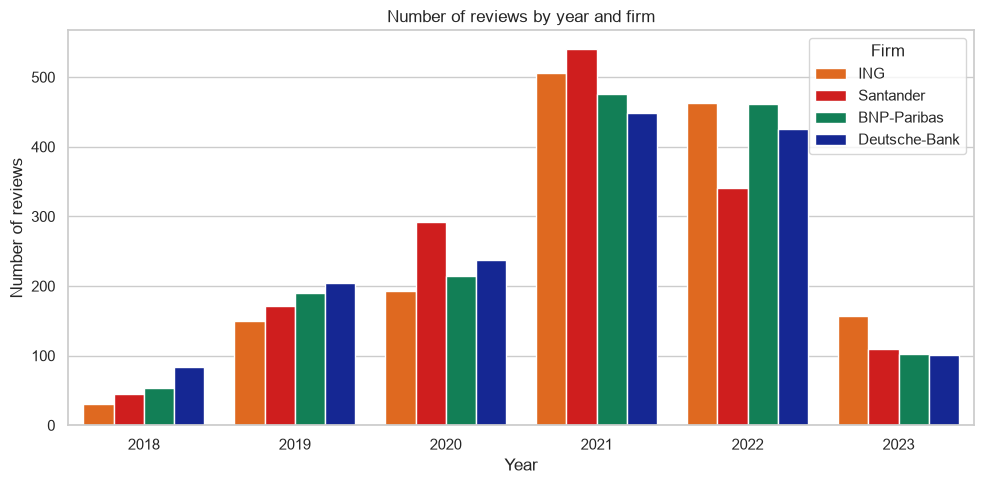

In [18]:
years = sorted(clean_df["year"].unique())

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=clean_df, x="year", hue="firm", order=years, hue_order=FIRMS, palette=PALETTE, ax=ax)

ax.set_title("Number of reviews by year and firm")
ax.set_xlabel("Year")
ax.set_ylabel("Number of reviews")
ax.legend(title="Firm")

plt.tight_layout()
plt.show()

While 2021–2022 are predominant, 2018 & 2023 are incomplete years.

#### Current vs Former Reviews per Firm

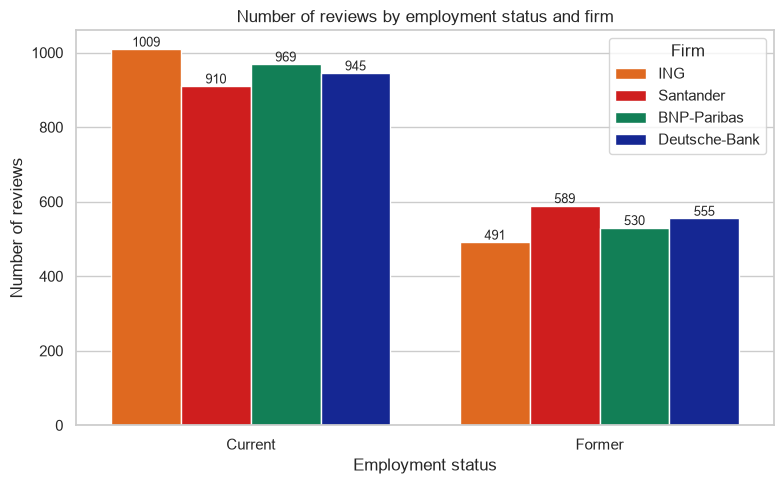

In [19]:
# Number of reviews by employment status and firm
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=clean_df, x="status", hue="firm", order=["Current", "Former"],
              hue_order=FIRMS, palette=PALETTE, ax=ax)

# Count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

ax.set_title("Number of reviews by employment status and firm")
ax.set_xlabel("Employment status")
ax.set_ylabel("Number of reviews")
ax.legend(title="Firm")

plt.tight_layout()
plt.show()

Current employee reviews double those of former employees, resulting in a 66–33 split. Regarding ING, it shows the highest proportion of reviews from current employees and, consequently, the lowest relative proportion of former employees compared to its competitors.

#### Rating distribution

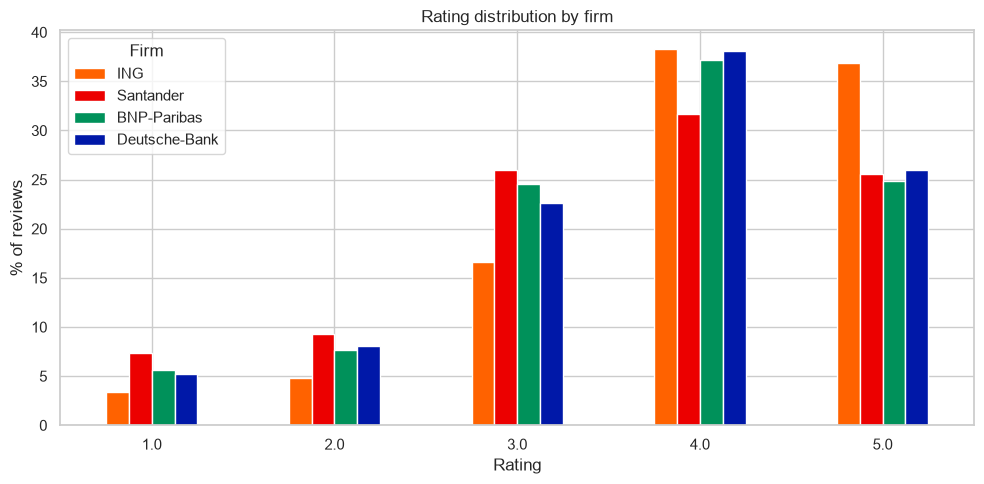

In [20]:
# % of reviews by score, for each firm
rating_dist = pd.crosstab(clean_df["firm"], clean_df["overall_rating"], normalize="index").mul(100)

fig, ax = plt.subplots(figsize=(10, 5))
rating_dist.T.plot(kind="bar", color=[PALETTE[firm] for firm in rating_dist.index], ax=ax)

ax.set_title("Rating distribution by firm")
ax.set_xlabel("Rating")
ax.set_ylabel("% of reviews")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Firm")

plt.tight_layout()
plt.show()

All firms exhibit heavily skewed positive ratings, possibly due to platform bias, since companies typically encourage only satisfied employees to leave Glassdoor reviews. Even within this skewed baseline, ING features the most favorable distribution: a heavier concentration of 4- and 5-star ratings.

#### Tenure by Firm

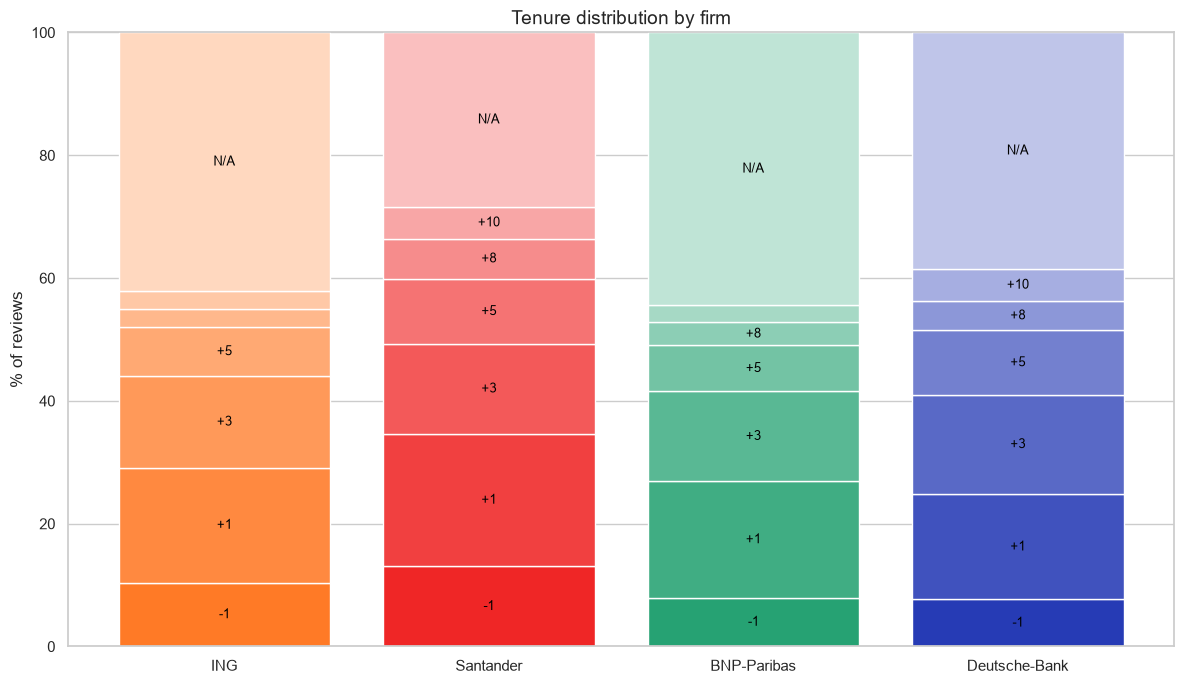

In [21]:
# Tenure distribution by firm
tenure_dist = (
    pd.crosstab(
        clean_df["firm"],
        clean_df["tenure"],
        normalize="index"
    )
    .mul(100)
    .reindex(FIRMS)
    .reindex(columns=['-1', '+1', '+3', '+5', '+8', '+10', 'N/A'])
)

fig, ax = plt.subplots(figsize=(12, 7))

bottom = np.zeros(len(tenure_dist))

for i, tenure_cat in enumerate(tenure_dist.columns):
    values = tenure_dist[tenure_cat].values

    bars = ax.bar(
        tenure_dist.index,
        values,
        bottom=bottom,
        color=[lighten(PALETTE[firm], 0.15 + i * 0.10) for firm in FIRMS],
        edgecolor="white",
        linewidth=1
    )

    # Add tenure labels inside each segment
    for j, (bar, value) in enumerate(zip(bars, values)):
        if value >= 3:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + value / 2,
                tenure_cat,
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

    bottom += values

ax.set_title("Tenure distribution by firm", fontsize=14)
ax.set_ylabel("% of reviews")
ax.set_ylim(0, 100)

# Remove legend
ax.legend().remove()

plt.tight_layout()
plt.show()

Tenure profiles vary across firms, with ING and BNP-Paribas showing a relatively high proportion of reviews with missing tenure information. Santander and Deutsche Bank provide a more distributed representation across tenure levels.

#### Text length

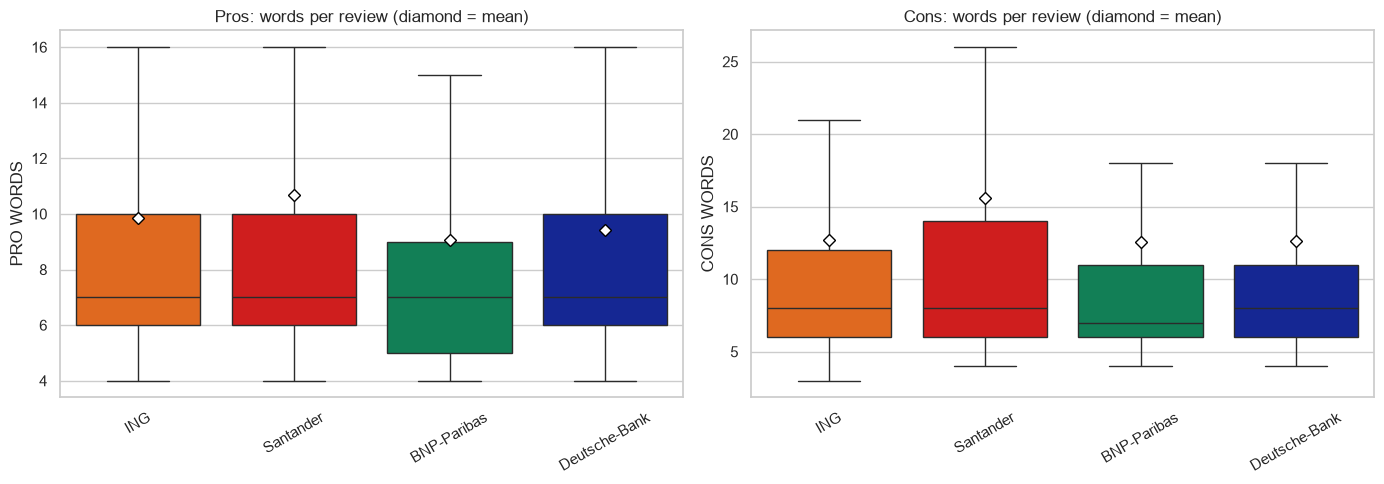

n_words_pros: 0.0% of reviews above 350 words
n_words_cons: 0.05% of reviews above 350 words


In [22]:
clean_df["n_words_pros"] = clean_df["pros"].str.split().str.len()
clean_df["n_words_cons"] = clean_df["cons"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title, ylabel in zip(
    axes,
    ["n_words_pros", "n_words_cons"],
    ["Pros", "Cons"],
    ["PRO WORDS", "CONS WORDS"],
):

    sns.boxplot(data=clean_df, x="firm", y=col, hue="firm", order=FIRMS, hue_order=FIRMS,
            palette=PALETTE, legend=False, dodge=False, showfliers=False, showmeans=True,
            meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"}, ax=ax)
    
    ax.set_title(f"{title}: words per review (diamond = mean)")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

# Transformers truncate at 512 tokens (~350-400 words), so check how many reviews would be cut
for col in ["n_words_pros", "n_words_cons"]:
    print(f"{col}: {round((clean_df[col] > 350).mean() * 100, 2)}% of reviews above 350 words")

Reviews are relatively short and show similar lengths across companies, with the "cons" slightly longer than the "pros." Virtually no reviews exceed the ~350-word threshold used as a reference for transformer input. Therefore, truncation should not result in any significant loss of information for the NLP analysis.

### 1.4. Business focused analysis

#### Firm summary

In [23]:
with_opinion = clean_df[clean_df["recommends"].isin(["Yes", "No"])]

# Mean rating + 95% CI
rating_stats = clean_df.groupby("firm", observed=True)["overall_rating"].agg(["mean", "sem"])
mean_ci = rating_stats.apply(
    lambda r: f"{r['mean']:.2f} [{r['mean'] - 1.96 * r['sem']:.2f}, {r['mean'] + 1.96 * r['sem']:.2f}]",
    axis=1,
)

summary = pd.DataFrame({
    "Reviews": clean_df["firm"].value_counts(),         # All revs
    "RevsWithOp": with_opinion["firm"].value_counts(),  # Only non-neutral revs
    "Mean [CI 95%]": mean_ci,
    "%Recommend": (clean_df["recommends"] == "Yes").groupby(clean_df["firm"], observed=True).mean() * 100,                  # % Recommendation on ALL revs
    "%NoResponse": (clean_df["recommends"] == "Neutral").groupby(clean_df["firm"], observed=True).mean() * 100,             # % NEUTRAL revs
    "%RecommendWithOp": (with_opinion["recommends"] == "Yes").groupby(with_opinion["firm"], observed=True).mean() * 100,    # % Recommendation on NON-NEUTRAL revs
}).loc[FIRMS].rename_axis("Firm").round(2)

summary

,Reviews,RevsWithOp,Mean [CI 95%],%Recommend,%NoResponse,%RecommendWithOp
Firm,,,,,,
ING,1500,855,"4.00 [3.95, 4.06]",46.67,43.00,81.87
Santander,1499,1016,"3.59 [3.53, 3.65]",41.96,32.22,61.91
BNP-Paribas,1499,884,"3.68 [3.62, 3.74]",43.43,41.03,73.64
Deutsche-Bank,1500,954,"3.71 [3.66, 3.77]",44.53,36.40,70.02


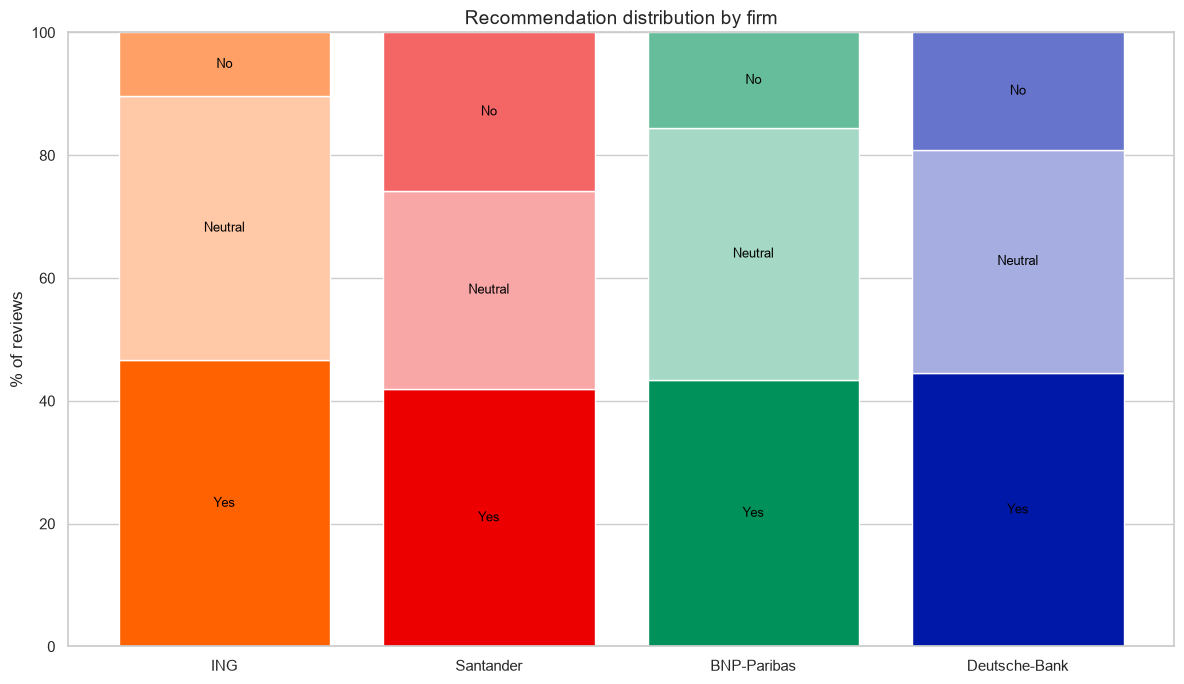

In [24]:
# Recommendation distribution by firm
recommendation_dist = (
    pd.crosstab(
        clean_df["firm"],
        clean_df["recommends"],
        normalize="index"
    )
    .mul(100)
    .reindex(FIRMS)
    .reindex(columns=["Yes", "Neutral", "No"])
)

fig, ax = plt.subplots(figsize=(12, 7))

for i, firm in enumerate(FIRMS):
    values = recommendation_dist.loc[firm]

    colors = [
        PALETTE[firm],                  # Yes -> dark
        lighten(PALETTE[firm], 0.65),   # Neutral -> greyish
        lighten(PALETTE[firm], 0.40)    # No -> light
    ]

    bottom = 0

    for j, recommendation in enumerate(["Yes", "Neutral", "No"]):
        value = values[recommendation]

        ax.bar(
            firm,
            value,
            bottom=bottom,
            color=colors[j],
            edgecolor="white",
            linewidth=1
        )

        # Add recommendation label instead of percentage
        if value >= 5:
            ax.text(
                i,
                bottom + value / 2,
                recommendation,
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

        bottom += value

ax.set_title("Recommendation distribution by firm", fontsize=14)
ax.set_ylabel("% of reviews")
ax.set_ylim(0, 100)

# Remove legend
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout()
plt.show()

ING boasts the best average rating (4.00) and the highest recommendation rate conditional on expressing an opinion (81.87%), clearly outperforming all three competitors. However, the hefty 43% share of neutral responses makes the overall recommendation percentage far less informative.

#### Rating evolution

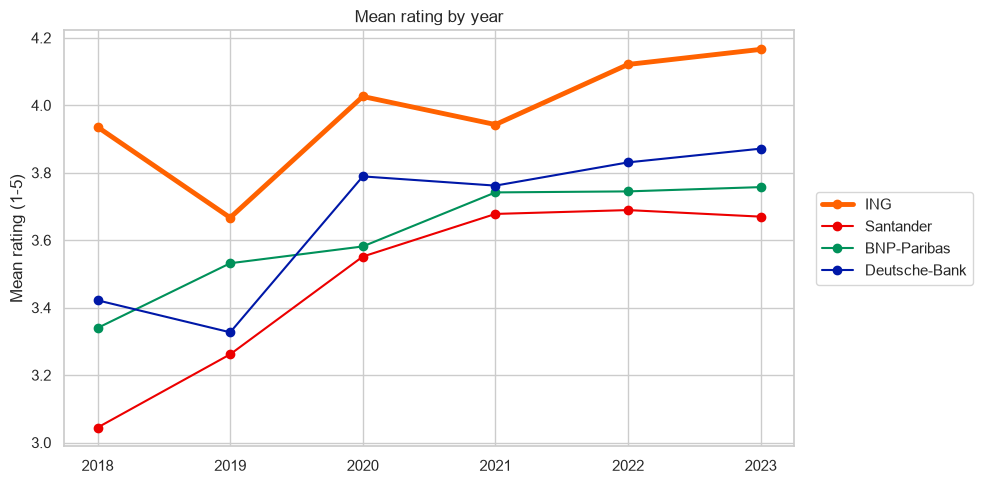

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

for firm in FIRMS:
    firm_year = clean_df[clean_df["firm"] == firm].groupby("year")["overall_rating"].mean()
    ax.plot(firm_year.index, firm_year.values, marker="o", color=PALETTE[firm],
            lw=3.5 if firm == TARGET else 1.5, label=firm)

ax.set_title("Mean rating by year")
ax.set_ylabel("Mean rating (1-5)")
ax.set_xticks(sorted(clean_df["year"].unique()))
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

plt.tight_layout()
plt.show()

ING maintains the highest average rating throughout the entire period, finishing 2023 above 4.00, while its competitors remain below 3.9. ING's advantage is therefore persistent and does not appear to rely on a single year, though it has experienced standard cyclical fluctuations rather than flatlining into a straight line.

#### Rating ~ Employment status (current vs. former)

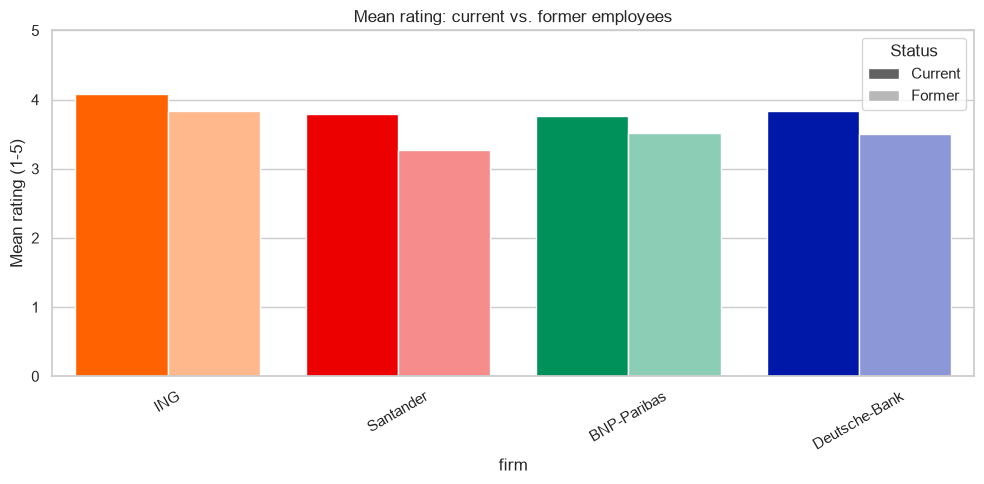

status,Current,Former,gap (Current - Former)
firm,,,
ING,4.09,3.84,0.25
Santander,3.80,3.27,0.53
BNP-Paribas,3.77,3.52,0.25
Deutsche-Bank,3.84,3.51,0.33


In [26]:
status_df = clean_df[clean_df["status"] != "Unknown"]

gap = status_df.pivot_table(index="firm", columns="status", values="overall_rating", aggfunc="mean", observed=True).loc[FIRMS]
gap["gap (Current - Former)"] = gap["Current"] - gap["Former"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=status_df, x="firm", y="overall_rating", hue="status", order=FIRMS,
            hue_order=["Current", "Former"], errorbar=None, ax=ax)

# One container per hue level (Current, Former), each one with one bar per firm (in FIRMS order)
for container, status in zip(ax.containers, ["Current", "Former"]):
    for bar, firm in zip(container, FIRMS):
        bar.set_facecolor(PALETTE[firm] if status == "Current" else lighten(PALETTE[firm], 0.55))

# Color now encodes the firm, so the legend only explains solid vs. light (neutral gray)
ax.legend(handles=[Patch(facecolor="#616161", label="Current"),
                   Patch(facecolor=lighten("#616161", 0.55), label="Former")],
          title="Status")

ax.set_title("Mean rating: current vs. former employees")
ax.set_ylabel("Mean rating (1-5)")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
gap.round(2)

Current employee ratings outpace those of former employees across all four firms, yet ING leads the pack in both categories (Current at ~4.1, Former at ~3.8). This suggests ING's competitive edge isn't just an illusion propped up by people still cashing their paycheck.

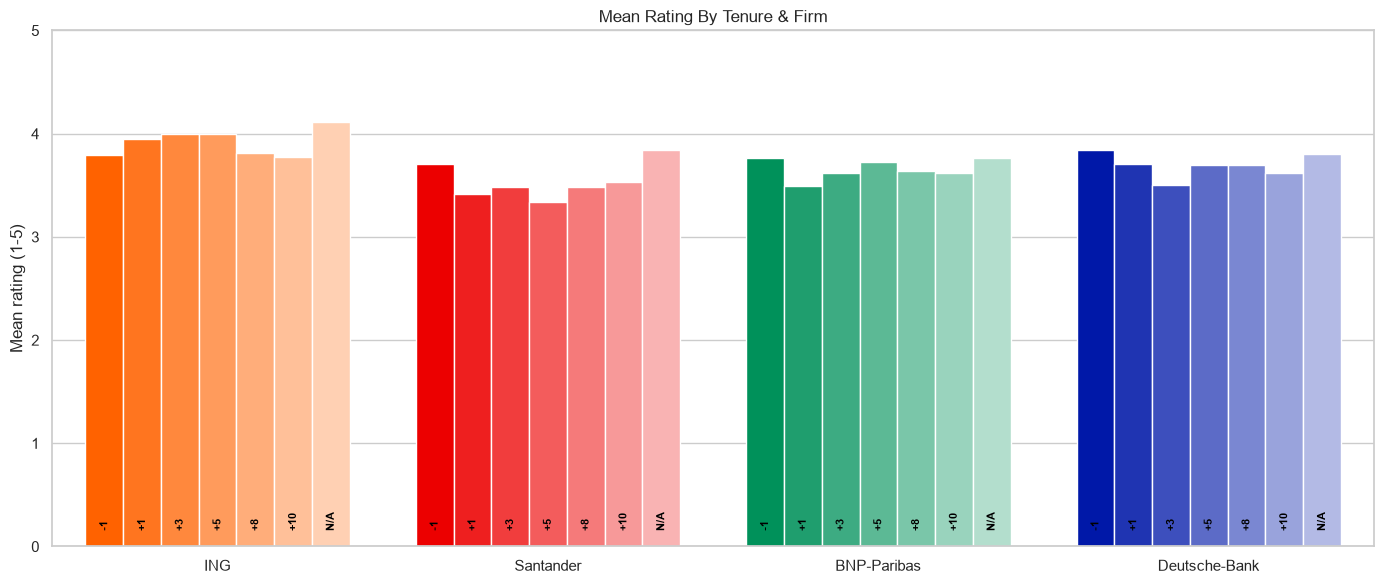

In [27]:
fig, ax = plt.subplots(figsize=(14, 6))

sns.barplot(
    data=clean_df, 
    x="firm", 
    y="overall_rating", 
    hue="tenure", 
    order=FIRMS,
    errorbar=None, 
    ax=ax
)

# Remove useless legend
if ax.get_legend():
    ax.get_legend().remove()

categories = clean_df['tenure'].cat.categories

for i, container in enumerate(ax.containers):
    amount = i * 0.12  
    tenure_label = categories[i]
    for bar, firm in zip(container, FIRMS):
        base_color = PALETTE.get(firm, "#616161")
        bar.set_facecolor(lighten(base_color, min(amount, 0.7)))
        
        x_pos = bar.get_x() + bar.get_width() / 2
        ax.text(
            x_pos, 0.15, tenure_label, 
            ha='center', va='bottom', 
            rotation=90, fontsize=8, 
            color='black', 
            weight='bold'
        )

ax.set_title("Mean Rating By Tenure & Firm")
ax.set_ylabel("Mean rating (1-5)")
ax.set_ylim(0, 5)
ax.tick_params(axis="x", rotation=0, labelsize=11)
ax.set_xlabel("")

plt.tight_layout()
plt.show()

Counter to intuition, tenure curves remain relatively stable across all firms, though each follows a distinct shape: Santander forms a U-shaped valley, with employees in the 3–8 year bracket showing the deepest dissatisfaction. Conversely, ING and BNP display an inverted-U mountain pattern, suggesting employees grow more comfortable over time before eventually burning out at higher tenures. Meanwhile, Deutsche Bank is the epitome of flat stability.

Proposal for ING: Offering more tenure-based benefits can help reduce lower ratings among more experienced workers.

#### **Whole EDA's Conclusions**

ING starts from a favorable competitive position: it has the highest ratings, a more positive rating distribution, and maintains its advantage among both current and former employees. Moreover, this strength remains consistent throughout the period analyzed and across different levels of tenure. The next step should therefore focus not on demonstrating that ING has a better overall perception, but on identifying the factors that explain this advantage and, particularly, the negative aspects mentioned in reviews from current and former employees that could represent opportunities for improvement.

## 2. Sentiment Analysis on Pros/Cons: Quality Check

Pros and cons already carry an expected sentiment. So sentiment is used here as a **quality check**, not as a metric to compare firms. If the model classified most cons as positive, something would be wrong and the topic analysis would not be reliable.

- **Model choice:** I used `distilbert-base-uncased-finetuned-sst-2-english`, a distilled version of BERT: smaller and faster with little loss of accuracy (Sanh et al., 2019), which matters because ~12,000 texts (pros and cons) must be scored. It is a context-aware model, unlike lexicon-based alternatives such as VADER, which only count positive and negative words and would miss negations or mixed tones.

    - **Parameters:** Truncated to 512 tokens as max length because the model cannot read more. In section 1.3, virtually no review exceeds ~350 words, so truncation loses almost no information.

- **Known limitations.** The model is binary (no neutral class), so empty or placeholder answers ("none") are forced into one of the two labels.

**Note**: The first time I ran the code below took 1:30H to run. Therefore, I added a checkpoint to avoid this process every time I run the notebook.

In [28]:
if SENTIMENT_PATH.exists():
    clean_df = pd.read_parquet(SENTIMENT_PATH)
else:
    
    device = 0 if torch.cuda.is_available() else -1     # GPU if available (0), otherwise CPU (-1)

    feeling_pipe = pipeline(
        "sentiment-analysis",
        model="distilbert-base-uncased-finetuned-sst-2-english",
        device=device,
    )

    def run_sentiment(texts, batch_size=32):
        
        # truncation
        out = feeling_pipe(texts, batch_size=batch_size, truncation=True, max_length=512)
        return pd.DataFrame(out)

    for col in ["pros", "cons"]:
        clean_df[f"sent_{col}"] = None
        clean_df[f"score_{col}"] = np.nan

        mask = clean_df[col] != ""   # empty texts are not scored
        res = run_sentiment(clean_df.loc[mask, col].tolist())

        clean_df.loc[mask, f"sent_{col}"] = res["label"].values
        clean_df.loc[mask, f"score_{col}"] = res["score"].values

    # CHECKPOINT
    SENTIMENT_PATH.parent.mkdir(exist_ok=True)
    clean_df.to_parquet(SENTIMENT_PATH)

clean_df[["sent_pros", "sent_cons"]].apply(lambda s: s.value_counts(normalize=True)).round(3)

,sent_pros,sent_cons
NEGATIVE,0.069,0.842
POSITIVE,0.931,0.158


#### Quality Check

In [29]:
def pct_label(df, col, label):
    d = df[df[col].notna()]
    return (d[col] == label).groupby(d["firm"], observed=True).mean() * 100

qc = pd.DataFrame({
    "pct_pros_positive": pct_label(clean_df, "sent_pros", "POSITIVE"),
    "pct_cons_negative": pct_label(clean_df, "sent_cons", "NEGATIVE"),
}).loc[FIRMS].round(1)

qc

,pct_pros_positive,pct_cons_negative
firm,,
ING,93.7,83.0
Santander,91.5,85.1
BNP-Paribas,93.5,83.7
Deutsche-Bank,93.7,84.9


The quality check is passed: the model behaves as expected in all four firms. Between 91.5% and 93.7% of pros are classified as positive, and between 83.0% and 85.1% of cons as negative. No firm deviates from the others, which rules out firm-specific issues and suggests that truncation and cleaning are not distorting the results.

The differences between firms (~2 points) are close to what sampling noise could produce, so sentiment is used as a quality filter, not as a ranking. Overall, ~16% of cons are classified as positive and ~7% of pros as negative; these discordant cases are reviewed below.

#### Manually Review

In [30]:
# Cons classified as POSITIVE
disc_cons = clean_df[clean_df["sent_cons"] == "POSITIVE"]

# Pros classified as NEGATIVE
disc_pros = clean_df[clean_df["sent_pros"] == "NEGATIVE"]

**High-confidence failures**

In [31]:
disc_cons[disc_cons["score_cons"] > 0.95].sample(10, random_state=SEED)[["firm", "cons", "score_cons"]]

,firm,cons,score_cons
4325,ING,Good atmosphere and motivation level of employees can differ from one department to another.,0.981492
3735,ING,So many competitors within the organization.,0.992795
1201,BNP-Paribas,I would say no downside.,0.972828
2930,Deutsche-Bank,Nothing bad in this organization.,0.999066
5978,Santander,Tough work but rewarding v,0.999790
4479,ING,The company is growing really fast with limit controll,0.997546
3489,ING,None. I enjoyed my stay with the company,0.999821
2067,Deutsche-Bank,its on cost saving spree,0.967324
5305,Santander,There are no cons - I am able to work remotley,0.993120
5677,Santander,Long hours but its nice,0.999704


The model is not randomly wrong. Three types of reviews appear:

- **"No cons" answers (4/10)**: The model is right to call them positive because they simply contain no criticism [1201, 2930, 3489, 5305].

- **Real complaints worded neutrally (4/10)**: They describe a genuine problem (internal competition, cost cutting) without negative vocabulary, so polarity misses it [4325, 3735, 2067, 4479].

- **Mixed reviews (2/10)**: The complaint is real but framed positively [5978, 5677].

This means the 16% of "positive" cons is partly empty answers and partly real criticism that sentiment cannot detect. As the sample is small and biased towards extreme cases, these proportions are only indicative.

**Cons misclassified**

In [32]:
disc_cons.sample(10, random_state=SEED)[["firm", "cons", "score_cons"]]

,firm,cons,score_cons
388,BNP-Paribas,Stressful job if management not good,0.795831
3380,ING,"none whatsoever, very nice place",0.999454
5873,Santander,"Pushing to sell products to customers, loans, surveys",0.850179
3867,ING,Great environment and respectable location,0.999860
4155,ING,"Very large organisation, quite political and silo-ed",0.993888
1652,Deutsche-Bank,Not really any. You are always working but that's expected in this role.,0.860400
3638,ING,There's no cons as far as my experience,0.605773
5734,Santander,There are none because they are amazing,0.996867
5182,Santander,Hours and some of the staff,0.984087
5915,Santander,nothing bad I can say to my workplace and job,0.992377


The same main types appear again as in the high-confidence sample, which suggests the pattern is not driven by extreme cases.

- **No criticism (6/10)**: The model is right to call them positive because either there is no criticism or the text is positive [3380, 3638, 5734, 5915, 3867, 1652].

- **Real complaints worded neutrally (4/10)**: Real problems described without negative vocabulary (sales pressure, culture, long hours, staff issues, stress...) [5873, 4155, 5182, 388].

In both samples, roughly 40-60% of discordant cons contain no criticism and about 40% are real complaints that polarity misses. This reinforces the previous insight: about half of misclassified cons are empty answers that will be grouped easily with BERTopic.

**Pros misclassified**

In [33]:
disc_pros.sample(10, random_state=SEED)[["firm", "pros", "score_pros"]]

,firm,pros,score_pros
5042,Santander,Room for growth based on experience and productivity. Tons of other department interactions.,0.999209
2118,Deutsche-Bank,"Nothing, just to learn and leave ASAP",0.983475
831,BNP-Paribas,Please go directly to cons,0.989778
1191,BNP-Paribas,None that I could remember,0.999407
2450,Deutsche-Bank,Not Applicable at this point,0.999734
4273,ING,"Teleworking is the norm, with one day per week",0.948389
5285,Santander,They paid me full time throughout the entire pandemic and only worked 2-3 days a week the first few months of COVID.,0.998894
3202,ING,You will have 5 allowances when you hired and dependents are included in HMO,0.955616
1139,BNP-Paribas,"Time off benefits You can be as bad as you want at your job, just keep out of trouble. No one ever fired for performance.",0.982619
5862,Santander,No much. Horrible experience Learn a lot about banking,0.999362


In this 10-case sample, all reviews have high confidence (> ~0.95) and the same pattern as in the cons appears:

- **No real pro (4/10)**: The model is right to see no positive content as there are empty or placeholder answers [2118, 831, 1191, 2450].

- **Real pros worded factually (4/10)**: Those are real misses because they describe genuine benefits (remote work, full pay during the pandemic, health coverage...) without emotional vocabulary [5042, 4273, 5285, 3202].

- **Complaints in the pros field (2/10)**: The model is correct because they are actual complaints on pro fields [1139, 5862].

The ~7% of "negative" pros is therefore a mix of empty answers, real benefits that sentiment cannot read and a few misplaced complaints. As the sample is small, these proportions are only indicative.

#### **Conclusions**

Polarity won't be used to discard any review. Empty answers ("none", "no cons") are not removed manually: BERTopic is expected to group them into their own topic, which will be labelled as "No content" and kept as their own row and not compared across firms (section 4). Percentages always use all of a firm's reviews as denominator, so every category stays on the same base. Factual descriptions of benefits and neutral-worded complaints are kept, as they feed categories such as compensation or work-life balance.

## 3. Topic Modeling

Topics are extracted with BERTopic, using **one single model for pros and another for cons**, trained on the four firms together so that topics are comparable across firms. Thanks to the balanced sample (section 0.4), no firm weighs more than the others in these joint models.

- **Unit of analysis:** Each review's pros (or cons) is one document. Reviews are short (< 10 words each), so probably: 1 review = 1 topic. Nonetheless, there's a limitation with reviews that includes +1 topics, as they will be classified as 1 only.
- **Empty answers:** As decided previously, answers such as "none" or "no cons" are not filtered using REGEX patterns because their wording varies a lot. BERTopic should group them in their own "No content" topic.

### 3.1. Embeddings

Each review is converted into a numeric vector with `all-MiniLM-L6-v2`, a sentence-embedding model that places reviews with similar meaning close together. It is small and fast enough to rerun without a GPU. Vectors are cached on disk (same pattern as the sentiment step) because this is the slowest part of the topic pipeline.

In [34]:
def get_embeddings(texts, name):
    path = EMBEDDINGS_DIR / f"{name}_{EMBEDDING_MODEL}.npy"

    if path.exists():
        emb = np.load(path)
        
        # Guard: if the sample changed, the cached vectors no longer match the texts
        assert len(emb) == len(texts), "Cache does not match the texts: delete the file and rerun"
        return emb

    embedder = SentenceTransformer(EMBEDDING_MODEL)
    emb = embedder.encode(texts, batch_size=64, show_progress_bar=True)

    EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)
    np.save(path, emb)
    return emb

### 3.2. Topic model

BERTopic chains three steps: UMAP (dimensionality reduction), HDBSCAN (clustering) and c-TF-IDF (keywords). I use the same function for pros and cons so both share the settings, but the cons model didn't work with the pros settings, so two of them change:
- `min_topic_size` is 30 for pros (~0.5% of reviews) and 40 for cons (~0.7%), because themes mentioned by fewer reviews are too small to justify an HR action.
- `selection` (`eom` for pros, `leaf` for cons) is explained in the Cons section.
- English stop words and bigrams only improve the keywords shown to the reader; they don't change how reviews are grouped.

The rest are standard BERTopic choices, kept fixed so pros and cons are treated alike:

| Setting | Value | Why |
|---|---|---|
| UMAP `n_components` | 5 | Compresses the 384-dimensional embeddings enough to cluster them while keeping the structure of the reviews. |
| UMAP `n_neighbors` | 15 | Keeps enough local detail for small themes that HR can act on separately (for example *Training* or *Mobility*); a larger value would blur them into broader ones. |
| UMAP `min_dist` | 0.0 | Lets similar reviews pack tightly, which makes the clusters easier to separate. |
| UMAP `metric` | cosine | Sentence embeddings are compared by direction, not by length. |
| HDBSCAN `min_cluster_size` | 30 (pros) / 40 (cons) | A theme mentioned by fewer than ~0.5-0.7% of the reviews is too small to justify an HR action. |
| HDBSCAN `cluster_selection_method` | `eom` (pros) / `leaf` (cons) | `eom` gives broad themes; `leaf` is needed in cons, where `eom` collapsed into one generic topic. |
| `random_state` | `SEED` | Same topics in every run. |

In [35]:
def fit_topic_model(docs, embeddings, min_topic_size=MIN_TOPIC_SIZE, selection="eom"):

    # UMAP: Reducing dims to 5
    umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=SEED)

    # HDBSCAN: MinTopicSize and ClusterSelectionMethod elegible
    hdbscan_model = HDBSCAN(min_cluster_size=min_topic_size, metric="euclidean",
                            cluster_selection_method=selection, prediction_data=True)

    # English StopWords
    vectorizer_model = CountVectorizer(stop_words="english", ngram_range=(1, 2), min_df=2)

    # Pipeline
    topic_model = BERTopic(umap_model=umap_model, hdbscan_model=hdbscan_model,
                           vectorizer_model=vectorizer_model, verbose=False)

    # Passing precomputed embeddings, so BERTopic does not need to load the embedding model
    topics, _ = topic_model.fit_transform(docs, embeddings)
    return topic_model, topics

#### Pros Topic Analysis

In [36]:
# Pros model: eom, min_topic_size = 30
pros_emb = get_embeddings(clean_df["pros"].tolist(), "pros")
pros_model, pros_topics = fit_topic_model(clean_df["pros"].tolist(), pros_emb)

clean_df["topic_pros"] = pros_topics

# Topic list with size and keywords
pros_model.get_topic_info()[["Topic", "Count", "Name"]]

,Topic,Count,Name
0,-1,2127,-1_good_great_people_benefits
1,0,389,0_balance_life_life balance_work life
2,1,351,1_team_good team_great team_team good
3,2,340,2_bank_banking_banks_santander
4,3,256,3_salary_good salary_salary good_pay
5,4,252,4_flexible_hours_working_home
6,5,248,5_culture_good culture_work culture_culture good
7,6,216,6_place_place work_good place_great place
8,7,200,7_benefits_days_vacation_insurance
9,8,179,8_people_colleagues_nice_people work


**Analysis overview**

In [37]:
# Topics without outlier one
print(f"Topics: {len(pros_model.get_topic_info()) - 1}")

# %Reviews on outlier topic
print(f"\nOutliers: {(clean_df['topic_pros'] == -1).mean():.1%}")

# Outlier distribution between firms
print(f"\nOutliers Distribution:\n{(clean_df['topic_pros'] == -1).groupby(clean_df['firm'], observed=True).mean().mul(100).round(1)}")

# Outlier sample
clean_df.loc[clean_df["topic_pros"] == -1, "pros"].sample(10, random_state=SEED).tolist()

Topics: 30

Outliers: 35.5%

Outliers Distribution:
firm
ING              36.0
Santander        36.4
BNP-Paribas      33.6
Deutsche-Bank    35.9
Name: topic_pros, dtype: float64


['Risk analysis and data management',
 'Complex products Interconnected areas Strong culture coming from Germany',
 'Employees are empowered to make work decisions',
 'Very rewarding career. Recognition is good',
 'good company, nice benefits, great people',
 'Company takes good care of their employees.',
 'Hybrid working where max 50% work from home',
 'Nice company with upward mobility',
 "Company as a whole was amazing. Great benefits, there are some great managers working there as well. Even after our layoff, they have been more then generous and it's truly appreciated. Ana Botin is amazing.",
 'Great environment for development and career growth.']

BERTopic finds **30 topics**, but **35.5% of the pros** end up as outliers (evenly distributed). Reading a random sample of them shows they are not noise. Most are generic or multi-theme reviews that mix several ideas in one sentence, so they sit between clusters and HDBSCAN cannot assign them to a single one. The rest are specific but niche comments that are too rare to reach `min_topic_size`.

Since the outliers are mostly valid content, they will not be discarded, and `min_topic_size` will not be lowered because it would just fragment the topics further without solving the multi-theme problem. Instead, they are reassigned to their closest topic later in this section.

**Suspicious topics Zoom-In**

In [38]:
# Read 5 reviews of each suspicious topic
for t in [2, 16, 0, 10]:
    print(f"\nTopic {t}:")
    print(clean_df.loc[clean_df["topic_pros"] == t, "pros"].sample(5, random_state=SEED).tolist())

# Summarize
pd.crosstab(clean_df["topic_pros"], clean_df["firm"], normalize="columns").mul(100).round(1).loc[[0, 2, 10, 16]]


Topic 2:
['Strong credit relationships, large balance sheet', 'Renowned international bank which looks good on the CV. Plenty of responsibility.', 'People Workspace Touchpoint Architecture Brand Agile way of working Good entry to banking industry', 'The people in my office building are incredible. They are extremely nice and helpful. The company is making large strides to cut back on paper usage. So far, from my perspective Santander has a knack for treating their employees with respect and trying to make them very happy. Everyday we are taking the lead on servicing our clients to the highest caliber.', 'good exposure to the financial markets']

Topic 16:
['Not many to be honest', 'No pros about working there.', 'I have Nothing to Highlight', 'there are none to disclose', 'As if we do not have pros']

Topic 0:
['company provides work life balance', 'work and family life balance important', 'Development opportunities Work life balance', 'None really... apart maybe the work-life balance

firm,ING,Santander,BNP-Paribas,Deutsche-Bank
topic_pros,,,,
0,5.4,3.1,10.1,7.3
2,3.7,7.5,4.8,6.6
10,2.7,2.1,2.6,1.7
16,0.8,1.5,1.4,1.1


3 main problems: 

- **Is Topic-2 (`bank_banking_santander`) a real theme or just firm name?:** It's a real theme. The reviews talk about the prestige of working for an international bank and about entering the banking sector, and it appears in all four firms. It is not perfectly balanced, though: it is more frequent in Santander (7.5%) than in ING (3.7%), partly because the firm name is one of its keywords. As this category only exists in pros, it never enters the net balance of section 4.

- **Is Topic-16 (`pros_think_cons_mention`) the "No content" topic?:** Yes. Its reviews are placeholders and holds 73 reviews (~1.2%), spread evenly across firms. Therefore it's not a firm effect. As planned in section 2, it is kept as its own row and not compared across firms.

- **Topics 0 and 10 share the same keywords:** In spite of topic 10 talks a little more about benefits, both topics are the same theme splitted in two. They will be merged when topics are grouped into business categories.

**Outliers Reassignment**

This step is not strictly necessary, but it makes the final business categories more representative: the percentages compared across firms rest on many more reviews, which gives HR a clearer insight. The trade-off is that some reassigned reviews are multi-theme or only partially accurate, since each review can only belong to one topic. The original assignment is kept in `topic_pros` for reference.

In [39]:
pros_docs = clean_df["pros"].tolist()

# Threshold 0.6 chosen after testing 0.3-0.7 (table below)

clean_df["topic_pros_red"] = pros_model.reduce_outliers(
    pros_docs, pros_topics, strategy="embeddings", embeddings=pros_emb, threshold=0.6)

**Reassignment check**

In [40]:
# Outliers by firm
pd.DataFrame({
    "raw":     (clean_df["topic_pros"] == -1).groupby(clean_df["firm"], observed=True).mean().mul(100),
    "reduced": (clean_df["topic_pros_red"] == -1).groupby(clean_df["firm"], observed=True).mean().mul(100),
}).round(1)

,raw,reduced
firm,,
ING,36.0,15.1
Santander,36.4,14.8
BNP-Paribas,33.6,13.9
Deutsche-Bank,35.9,15.5


In [41]:
# Reassigned topic sample
moved = clean_df[(clean_df["topic_pros"] == -1) & (clean_df["topic_pros_red"] != -1)]
moved.sample(10, random_state=SEED)[["pros", "topic_pros_red"]]

,pros,topic_pros_red
5485,Great learning environment where your job matters,11
3142,"Great benefits and salary, good hours",3
875,"Good working culture, free transport, cafeteria service",5
3148,"Flexible, innovative, great co workers, great atmosphere, good pay, nice location",12
4570,Good benefits and progression if you're willing to work hard,23
5251,"People focussed, stable and reward hard work",0
5685,"Good benifits, great pay friendly environment",23
4264,Everybody is very pleasant to work with and adequately credentialed.,8
2070,"Nice people to work with, standard benefits",7
2145,"Family and friendly environment, attention to CSR, lots of trainings, outstanding contributions are rewarded",9


Outliers are reassigned to their closest topic only when the cosine similarity between the review and the topic is at least 0.6. Several thresholds (from 0.3 to 0.7) were tested, and 0.6 was kept because the reviews it reassigns are the best matched to their topic and add the least noise. Lower thresholds also pulled in many long, list-style reviews that mention several themes and were forced into a topic that captured only one of them. After reassignment, 14.9% of the reviews remain as outliers and will be treated as "Mixed / generic". Meaning this reassignment successfully moved ~58% of original outliers.

#### Cons Topic Analysis

With the pros settings (`eom`, `min_topic_size = 30`) the cons model collapsed: 7 topics, with 79.4% of the reviews in a single generic topic. Cons are longer and mix several complaints, so their embeddings sit in one dense region and `eom` returns it as a single cluster. A topic that big gives HR nothing to act on. Consequently, I tested out other HDBSCAN configurations and also K-MEANS as a clustering alternative.

The winning settings were HDBSCAN `leaf` with `min_topic_size = 40`. Therefore, those are the unique settings present on the following workflow. Decision was based on leaf being able to split the huge topic and topic amount and %outliers similar to pros.

In [42]:
cons_docs = clean_df["cons"].tolist()
cons_emb = get_embeddings(cons_docs, "cons")

# Finer settings than pros (see explanation above)
cons_model, cons_topics = fit_topic_model(cons_docs, cons_emb, min_topic_size=40, selection="leaf")
clean_df["topic_cons"] = cons_topics

cons_info = cons_model.get_topic_info()
cons_info[["Topic", "Count", "Name"]]

,Topic,Count,Name
0,-1,2721,-1_work_management_people_slow
1,0,551,0_salary_low_pay_market
2,1,330,1_hours_long_long hours_work
3,2,188,2_management_managers_micro_micro management
4,3,177,3_cons_cons cons_moment_dont cons
5,4,177,4_career_career progression_progression_opportunities
6,5,174,5_say_good_complain_bad
7,6,170,6_think_think think_far_moment
8,7,160,7_bank_banking_banks_financial
9,8,157,8_promotion_promotions_promoted_hard


**Analysis Overview**

In [43]:
# Topics without outlier one
print(f"Topics: {len(cons_info) - 1}")

# %Reviews on outlier topic
print(f"\nOutliers: {(clean_df['topic_cons'] == -1).mean():.1%}")

# Outlier distribution between firms
print(f"\nOutliers Distribution:\n{(clean_df['topic_cons'] == -1).groupby(clean_df['firm'], observed=True).mean().mul(100).round(1)}")

# Outlier sample
clean_df.loc[clean_df["topic_cons"] == -1, "cons"].sample(10, random_state=SEED).tolist()

Topics: 24

Outliers: 45.4%

Outliers Distribution:
firm
ING              47.7
Santander        49.4
BNP-Paribas      39.6
Deutsche-Bank    44.7
Name: topic_cons, dtype: float64


['Nil nil nil nil nil',
 'management needs to refocus on strategy very high workload',
 'Due to low wages it seems only the bad ones stay',
 'too many management changes. Lack of communication and transparency.',
 'Goals are far beyond reach at times with phone calls',
 'they are based in Milton Keynes, which is not convenient for some people.',
 'Recent return to office push is disappointing.',
 "Salary wasn't worth it! Excessive micro-management, clueless employees in key positions (who exert little effort to be productive members of the team), and office gossip (the toxic kind). I worked for each of the Big 4 Investment Banks in multiple areas of the industry (never had an issue), and at least 3 of the fellow employees here at BNP RRC were wasted resources who would have been terminated.",
 'Hierarchical and slow process especially on change management',
 'pressure to sell, ranking according to sellings']

BERTopic finds 24 topics, but 45.4% of the cons end up as outliers, less evenly distributed than in pros (from 39.6% in BNP-Paribas to 49.4% in Santander). Reading a random sample shows they are not noise: only 1 of 10 is a filler answer ("Nil nil nil"), because those already have their own topics. The rest are real complaints of three kinds: multi-theme reviews that sit between clusters, short specific comments too rare to form a topic, and complaints that match an existing topic but fall outside its dense core. As the sample is small, these proportions are only indicative.

Since the outliers are mostly valid content, they will not be discarded, and `min_topic_size` will not be lowered because `leaf` already produces fine-grained topics. Instead, they are reassigned to their closest topic later in this section. The differences between firms are checked again after reassignment, since a firm-specific topic could explain part of them.

**Suspicious topics Zoom-In**

In [44]:
# Read 5 reviews of each suspicious topic
for t in [7, 9, 17, 12]:
    print(f"\nTopic {t}:")
    print(clean_df.loc[clean_df["topic_cons"] == t, "cons"].sample(5, random_state=SEED).tolist())

# Summarize
pd.crosstab(clean_df["topic_cons"], clean_df["firm"], normalize="columns").mul(100).round(1).loc[[0, 3, 5, 6, 7, 9, 12, 17, 20]]


Topic 7:
['Uncertainty of the banks future', 'Below market pay, senior management not very inspiring, no clear wholesale banking strategy', 'Deal flows are worse than that of US banks Politics between MDs and juniors cannot ask freely Limited source due to small team', 'No more mortgage or heloc lending!', 'Hard to progress career Higher management dont know how the bank works']

Topic 9:
['Senior mgt mostly in Amsterdam', '-nur 30 Tage im Europ Ausland -branchenunterdurchschnittliche Vergütung -wahsinnnig schnelle Entwicklungsgeschwindigkeit', 'Cares to much about the French employees and overlooks places like Portugal. Pay is very low', 'Some groups speak French only so knowing the language here is quite important', "50% work in office policy. Upper management tracks how many days you'll be in the office Extreme lack of budget for projects- rely on budgets from the head office in Amsterdam Base pay is low compared to peers, no bonuses, no shares There are some incompetent managers a

firm,ING,Santander,BNP-Paribas,Deutsche-Bank
topic_cons,,,,
0,9.2,6.8,14.5,6.2
3,3.3,2.2,3.4,2.9
5,3.0,2.3,2.9,3.4
6,3.5,2.7,2.0,3.1
7,2.7,2.9,1.7,3.4
9,2.1,0.9,6.7,0.1
12,0.9,1.1,1.6,3.4
17,0.7,0.8,1.5,1.1
20,0.7,1.0,1.1,0.7


4 main questions:

- **Is Topic-7 (`bank_banking_banks_financial`) a real theme or just the firm name?** It is a real theme: complaints about the bank's strategy and market position. It is balanced across firms, so it is not a firm effect. It is heterogeneous, though: some reviews also mix pay or career complaints, so it will go to a "Mixed / other" category when topics are grouped.

- **Is Topic-9 (`french_paris_dutch`) a firm effect?** Partly. Its reviews are about language requirements and head-office location, so it is a real theme, but it is concentrated in BNP-Paribas (6.7%) and almost absent in Deutsche-Bank (0.1%). It will be kept as its own category, renamed *Language & HQ location*, and left out of the priority matrix and of the net balance, since a language requirement is not comparable across firms. The sample shows it is not fully clean (it includes a review in German and some pay or management complaints), because the English-only embedder tends to group reviews by language and place names.

- **Are Topics 3, 5, 6 and 20 the "No content" topics?** Yes: "no cons", "nothing bad", "none so far". Together they hold 574 reviews (~9.6%), evenly spread across firms. As planned in section 2, they are kept as their own row and not compared across firms.

- **Are Topics 0, 12 and 17 the same theme split in three?** Yes: all are about pay, so they will be merged into one compensation category. Merged, the three reach 17.6% of BNP-Paribas reviews vs 8.7%-10.8% in the other firms. This is a raw share, so it is only checked against the net balance in section 4.

**Outliers Reassignment**

As in pros, this step is not strictly necessary, but it makes the final business categories more representative: the percentages compared across firms rest on many more reviews, which gives HR a clearer insight. The trade-off is that some reassigned reviews are multi-theme or only partially accurate, since each review can only belong to one topic. The original assignment is kept in `topic_cons` for reference.

In [45]:
# Lower threshold than pros: cons are longer, so less similar to any single topic
clean_df["topic_cons_red"] = cons_model.reduce_outliers(
    cons_docs, cons_topics, strategy="embeddings", embeddings=cons_emb, threshold=0.4)

**Reassignment check**

In [46]:
# Outliers by firm
pd.DataFrame({
    "raw":     (clean_df["topic_cons"] == -1).groupby(clean_df["firm"], observed=True).mean().mul(100),
    "reduced": (clean_df["topic_cons_red"] == -1).groupby(clean_df["firm"], observed=True).mean().mul(100),
}).round(1)

,raw,reduced
firm,,
ING,47.7,10.7
Santander,49.4,11.5
BNP-Paribas,39.6,8.3
Deutsche-Bank,44.7,8.9


In [47]:
# Reassigned topic sample
moved = clean_df[(clean_df["topic_cons"] == -1) & (clean_df["topic_cons_red"] != -1)]
moved.sample(10, random_state=SEED)[["cons", "topic_cons_red"]]

,cons,topic_cons_red
5511,you have to work during a project,1
1668,disliked hierarchy and long hours,1
4389,"Poor management vision, with fight for power among the different branches (Dutch and Belgian) Pay is below average for good performers,",9
413,"Terrible salary rate, terrible environment to work. They are not flexible and the job is archaic.",0
2168,Aggressive culture. Unhelpful colleagues. Political. Limited transparency on promotions.,8
3401,Delegation of work is normal. If you are at the bottom of hierarchy you will burnout.,13
5256,Some policies can be hard to follow and/or redundant Systems are outdated,22
1990,"No raises ever, lots and lots of negative news.",0
5629,Difficult to progress in the organization,13
4569,Lack of progression once you get to TM level.,4


**Threshold sensitivity.** For each similarity threshold: share of reviews that stay as outliers and number of outliers reassigned. It backs the values I chose (0.6 for pros, 0.4 for cons) and shows why the same one can't be used for both.

In [48]:
def threshold_table(model, docs, topics, emb, thresholds=(0.3, 0.4, 0.5, 0.6, 0.7)):
    topics = np.asarray(topics)
    rows = []
    for th in thresholds:
        # Reassign again with each threshold and count what changes
        new = np.asarray(model.reduce_outliers(docs, list(topics), strategy="embeddings", embeddings=emb, threshold=th))
        rows.append({"threshold": th,
                     "% still outliers": (new == -1).mean() * 100,
                     "reviews reassigned": int(((topics == -1) & (new != -1)).sum())})
    return pd.DataFrame(rows).set_index("threshold").round(1)

print("PROS (chosen threshold: 0.6)")
display(threshold_table(pros_model, pros_docs, pros_topics, pros_emb))
print("CONS (chosen threshold: 0.4)")
display(threshold_table(cons_model, cons_docs, cons_topics, cons_emb))

PROS (chosen threshold: 0.6)


,% still outliers,reviews reassigned
threshold,,
0.3,0.7,2086
0.4,2.4,1982
0.5,6.3,1752
0.6,14.9,1236
0.7,24.8,639


CONS (chosen threshold: 0.4)


,% still outliers,reviews reassigned
threshold,,
0.3,3.2,2530
0.4,9.8,2131
0.5,21.0,1461
0.6,33.9,685
0.7,42.9,150


Outliers are reassigned to their closest topic only when the cosine similarity between the review and the topic is at least 0.4. Several thresholds (from 0.3 to 0.7) were tested. Unlike in pros, 0.6 cannot be reused: it would leave 33.9% of the cons unassigned (vs 14.9% in pros), because cons are longer and mix several complaints, so they are less similar to any single topic. 0.4 was kept as a compromise between coverage and noise (0.5 would still leave 21.0% unassigned). A manual read of the reviews moved only by going from 0.5 to 0.4 (670 reviews) showed that in a 10-review sample, 7 fit.

After reassignment, 9.8% of the reviews remain as outliers and will be treated as "Mixed / generic". Meaning this reassignment successfully moved ~78% of original outliers. The gap between firms also shrinks (from 39.6%-49.4% to 8.3%-11.5%), so outliers are no longer concentrated in any firm.

**Note**: A quick check showed that 172 reassigned reviews landed in the "No content" topics, mostly filler answers; a few real complaints end up there too (about 0.7% of all cons at most), which is accepted as a limitation.

#### Manually Grouping Topics into Business Categories

The 30 pros topics and 24 cons topics are grouped into 6 comparable business categories (compensation, work-life balance, career, management, culture, processes), plus 3 one-sided or firm-specific categories that are not compared across firms (*International environment* and *Company brand & prestige* in pros, *Language & HQ location* in cons), plus "Mixed / generic" and "No content". Pros and cons are compared category by category in section 4 only for the 6 comparable ones. Categories are defined by the HR lever each one points to, not by the wording of the topics.

**Assignment rules.** Topics whose top keywords name a single HR theme are assigned by keywords. Ambiguous or heterogeneous topics are read (6 reviews each) and, if the sample shows no clear core (several themes mixed), they go to *Mixed / generic*: this rule is applied equally to pros 14, pros 23, cons 7 and cons 18. `mapping_table` at the end of this section lists every topic with its category and whether it was read by hand.

Categories:

- **Compensation & benefits**: Pay, bonus, pension, insurance, paid leave: reward policy.
- **Work-life balance & hours**: Workload, schedules, flexibility, remote work: work policy and staffing.
- **Career & development**: Promotion, growth, mobility, training: talent and learning programs.
- **Management & leadership**: Quality of line and senior management: leadership development.
- **Culture & people**: Team, colleagues, atmosphere, work environment (incl. office), diversity, office politics: culture and engagement.
- **Processes & technology**: Bureaucracy, ways of working, systems, HR support and policies: operations (technology and bureaucracy are merged because each alone is too small to compare).
- **International environment** (pros only): International exposure and global environment. A strength for employer branding, but it has no cons counterpart, so it is not part of the net balance.
- **Language & HQ location** (cons only): Language requirements and head-office location. Firm-specific (concentrated in BNP-Paribas), so it is left out of the priority matrix and of the net balance. It measures the opposite of *International environment*, which is why they are kept as two separate categories.
- **Company brand & prestige**: Only appears in pros (reputation of an international bank), with no cons counterpart.
- **Mixed / generic**: Topics with no clear core, plus the outliers left after reassignment.
- **No content or Placeholder answers**: Kept as their own row and not compared across firms.

Percentages in section 4 always use all of a firm's reviews as denominator; *Mixed / generic* and *No content* are shown as rows but not interpreted.

In [49]:
PROS_GROUPS = {
    "Compensation & benefits":         [3, 7, 18, 19, 20],
    "Work-life balance & hours":       [0, 4, 10],              # 0 and 10 are the same theme split in two
    "Career & development":            [9, 29],
    "Management & leadership":         [15],
    "Culture & people":                [1, 5, 8, 11, 12, 21, 27, 28],
    "Processes & technology":          [24, 26],
    "International environment":       [13],
    "Company brand & prestige":        [2],
    "Mixed / generic":                 [-1, 6, 14, 17, 22, 23, 25],   # 14 mixes culture and balance with no clear core (same rule as 23)
    "No content":                      [16],
}

CONS_GROUPS = {
    "Compensation & benefits":         [0, 12, 17],             # same theme split in three
    "Work-life balance & hours":       [1, 11],
    "Career & development":            [4, 8, 16, 21],
    "Management & leadership":         [2, 19],
    "Culture & people":                [14, 15],
    "Processes & technology":          [10, 13, 22, 23],
    "Language & HQ location":          [9],                     # firm-specific, not compared (see markdown)
    "Mixed / generic":                 [-1, 7, 18],             # 18 mixes six different themes, no clear core
    "No content":                      [3, 5, 6, 20],
}

# Categories compared across firms in section 4 (net balance and gap vs peers)
COMPARABLE = ["Compensation & benefits", "Work-life balance & hours", "Career & development",
              "Management & leadership", "Culture & people", "Processes & technology"]

def topic_to_category(groups):
    mapping = {t: cat for cat, topics in groups.items() for t in topics}
    assert len(mapping) == sum(len(v) for v in groups.values()), "A topic is in two categories"
    return mapping

clean_df["cat_pros"] = clean_df["topic_pros_red"].map(topic_to_category(PROS_GROUPS))
clean_df["cat_cons"] = clean_df["topic_cons_red"].map(topic_to_category(CONS_GROUPS))
assert clean_df[["cat_pros", "cat_cons"]].notna().all().all(), "A topic has no category"

# Share of reviews per category
pd.concat([clean_df["cat_pros"].value_counts(normalize=True).mul(100).round(1).rename("pros %"),
           clean_df["cat_cons"].value_counts(normalize=True).mul(100).round(1).rename("cons %")], axis=1)

,pros %,cons %
Mixed / generic,27.9,15.4
Culture & people,24.0,4.6
Work-life balance & hours,15.8,11.7
Compensation & benefits,15.4,17.1
Company brand & prestige,5.7,NaN
Career & development,4.2,12.1
Management & leadership,2.2,10.7
International environment,2.1,NaN
Processes & technology,1.6,13.3
No content,1.2,12.4


**Assignments check**

In [50]:
for col, text, topics in [("topic_pros", "pros", [12, 14, 15, 23]), ("topic_cons", "cons", [14, 18, 23])]:
    for t in topics:
        print(f"\n[{text} topic {t}]")
        for x in clean_df.loc[clean_df[col] == t, text].sample(6, random_state=SEED).str[:120]:
            print("  -", x)


[pros topic 12]
  - Brilliant office environment, culture and perks.
  - Excellent job and people, office is amazing, easy to make new connection and enjoy time while working
  - Big and spacious office. Good coffee machines
  - Parking was nearly always available. And there is a metro 10 minutes walk away and buses right outside the building. I h
  - Some excellent people work there. You can make friends in the office.
  - International, youthful colleagues Friendly, relaxed atmosphere (for now) Spacious office with some nice features

[pros topic 14]
  - Atmosphere; culture; diversity; coworkers; work life balance
  - Relaxed work culture Great work life balance Many vacations
  - Work Culture Team collaboration Work life balance
  - Good work culture Transport facility Work life balance
  - Work culture is good. Work life balance.
  - Nice work life balance and culture

[pros topic 15]
  - *nice people, *sponsor several trainings/exams like the Cfa, *flexible, *management listens t

Six reviews were read from each doubtful topic:

- **Pros 12 (office):** a mix of physical workplace (space, parking, coffee machines) and colleagues. Kept in *Culture & people* as "work environment".
- **Pros 14 (culture + balance):** all 6 reviews mention both culture and work-life balance. Sent to *Mixed / generic*: it holds two themes with no clear core, the same rule used for pros 23. Choosing culture just because it is the first keyword would be arbitrary.
- **Pros 15 (management):** 4 of 6 are about management (listens, fair, supportive). Kept in *Management & leadership*.
- **Pros 23 (benefits + relaxed environment):** mixes benefits, atmosphere and flexibility with no clear core. Sent to *Mixed / generic*.
- **Cons 14 (culture):** blame culture, toxic jokes, traditional ways. Kept in *Culture & people*.
- **Cons 18 (teams):** mixes cross-team friction, politics and workload. The 6 reviews read cover six different themes (diversity, response time, politics, restructuring, workload, team luck), so it has no clear core. Sent to *Mixed / generic*.
- **Cons 9 (French / Dutch):** the 5 reviews read include one in German and others about pay or management, so it is not a pure language topic. Kept as its own category, renamed *Language & HQ location*, and neither compared across firms nor used in the net balance. Reviews not written in English are not filtered: this is accepted as a limitation.
- **Cons 23 (HR):** complaints about HR support and policies, sometimes mixed with pay. Kept in *Processes & technology*; it is small (43 reviews before reassignment), its effect is tested in the sensitivity check below.

Some points to keep in mind:

- *Mixed / generic* is the largest pros bucket (over a quarter of the reviews), mostly generic praise with no theme to act on, so it is shown as its own row and not compared across firms.
- Pros mention processes and technology much less than cons do (1.6% vs 13.3%), so only the gap versus peers is meaningful in that category, never the absolute net balance.
- Pros and cons models use different settings (`eom`/30 vs `leaf`/40), and pros *Career* and *Management* are under-captured (many outliers say "career growth"). In every category only the gap versus peers is interpreted, never the absolute net balance.
- Reassigning outliers inflates some cons categories (for example *Processes & technology* goes from 5.1% of reviews using only direct assignments to 13.3% after reassignment), so the robustness check below is reported before using these shares.


**Traceability Topic ←→ Category**

Every topic with its keywords, size, final category and whether its reviews were read by hand. Topics not read were assigned by their keywords because they name a single HR theme.

In [51]:
# Topics read by hand (zoom-ins and assignment checks above); the rest were assigned by keywords
READ_PROS = [0, 2, 10, 12, 14, 15, 16, 23]
READ_CONS = [3, 5, 6, 7, 9, 12, 14, 17, 18, 20, 23]

def mapping_table(model, groups, reduced_col, read):
    # Topic size before and after outlier reassignment, plus its category
    t2c = topic_to_category(groups)
    info = model.get_topic_info()[["Topic", "Count", "Name"]].rename(columns={"Count": "n_raw"})
    info["category"] = info["Topic"].map(t2c)
    info["n_after_reassign"] = info["Topic"].map(clean_df[reduced_col].value_counts()).fillna(0).astype(int)
    info["read_by_hand"] = info["Topic"].isin(read)
    return info.sort_values(["category", "Topic"]).reset_index(drop=True)

print("PROS"); display(mapping_table(pros_model, PROS_GROUPS, "topic_pros_red", READ_PROS))
print("CONS"); display(mapping_table(cons_model, CONS_GROUPS, "topic_cons_red", READ_CONS))

PROS


,Topic,n_raw,Name,category,n_after_reassign,read_by_hand
0,9,167,9_learning_learn_opportunities_career,Career & development,211,False
1,29,30,29_mobility_internal mobility_internal_opportunities internal,Career & development,40,False
2,2,340,2_bank_banking_banks_santander,Company brand & prestige,341,True
3,3,256,3_salary_good salary_salary good_pay,Compensation & benefits,438,False
4,7,200,7_benefits_days_vacation_insurance,Compensation & benefits,259,False
5,18,70,18_bonus_bonuses_salary bonus_pay,Compensation & benefits,92,False
6,19,65,19_pto_401k_match_401k match,Compensation & benefits,65,False
7,20,57,20_pension_good pension_benefits pension_scheme,Compensation & benefits,67,False
8,1,351,1_team_good team_great team_team good,Culture & people,362,False
9,5,248,5_culture_good culture_work culture_culture good,Culture & people,330,False


CONS


,Topic,n_raw,Name,category,n_after_reassign,read_by_hand
0,4,177,4_career_career progression_progression_opportunities,Career & development,289,False
1,8,157,8_promotion_promotions_promoted_hard,Career & development,220,False
2,16,73,16_growth_grow_growth opportunities_opportunities,Career & development,122,False
3,21,46,21_training_poor training_proper_training support,Career & development,94,False
4,0,551,0_salary_low_pay_market,Compensation & benefits,790,False
5,12,105,12_bonus_bonuses_low_low bonus,Compensation & benefits,155,True
6,17,62,17_banks_compared banks_compared_salary,Compensation & benefits,78,True
7,14,90,14_culture_poor_management_blame,Culture & people,135,True
8,15,82,15_politics_office politics_political_office,Culture & people,141,False
9,9,148,9_french_paris_dutch_speak french,Language & HQ location,164,True


**Last audit.** I only read the topics assigned by keywords through their keywords, so here I print 3 random reviews of each one next to its category (direct BERTopic assignments, before outlier reassignment). This way every topic-to-category decision is checked against real text at least once.

In [52]:
def audit(model, col, text, groups, read, n=3):
    # Only topics not read by hand
    t2c = topic_to_category(groups)
    for t in sorted(set(model.get_topic_info()["Topic"]) - set(read) - {-1}):
        print(f"[{text} topic {t}] -> {t2c[t]}")
        sub = clean_df.loc[clean_df[col] == t, text]
        for x in sub.sample(min(n, len(sub)), random_state=SEED).str[:110]:
            print("   -", x)

audit(pros_model, "topic_pros", "pros", PROS_GROUPS, READ_PROS)
audit(cons_model, "topic_cons", "cons", CONS_GROUPS, READ_CONS)

[pros topic 1] -> Culture & people
   - good energy in the team
   - Good work good team and always challenged to excel
   - Good work life balance and great team spirit
[pros topic 3] -> Compensation & benefits
   - High salary, good management, perks
   - Great pay and strong benefits
   - Continuing Education, strong leadership, salary
[pros topic 4] -> Work-life balance & hours
   - Great scheduling and customer focus collection to resolve accounts
   - Relatively exciting work environment, smart people, work from home benefits
   - remote working 2 days of week, flex hours, friendly env
[pros topic 5] -> Culture & people
   - Good work culture and environment
   - Supportive of future development Everyone is Friendly Good culture
   - Really have a lot of good employee support tools in place, it seems that they want to change culture.
[pros topic 6] -> Mixed / generic
   - Great place to kickstarter your career
   - Good to work fr this org
   - Great place to work for and genuine

**Robustness of the grouping**

I recompute ING's gap versus the peer mean (in pp of reviews) under three scenarios: the grouping as decided (`gap_base`), direct BERTopic assignments without reassigning outliers (`gap_raw_outliers`), and the most ambiguous topics (pros 12, cons 23) sent to *Mixed / generic* (`gap_ambiguous_to_mixed`). If the sign of a gap doesn't change, the conclusion doesn't depend on those decisions.

In [53]:
def category_shares(topic_col, groups):
    # % of each firm's reviews per category (denominator = all its reviews)
    cat = clean_df[topic_col].map(topic_to_category(groups))
    return pd.crosstab(clean_df["firm"], cat, normalize="index").mul(100)

def gap_vs_peers(shares):
    # Target firm minus peer mean, in pp
    return shares.loc[TARGET] - shares.loc[PEERS].mean()

def move_topics(groups, topics, target="Mixed / generic"):
    # Sends some topics to another category (used in the sensitivity check)
    new = {cat: [t for t in ts if t not in topics] for cat, ts in groups.items()}
    new[target] = new[target] + list(topics)
    return new

def sensitivity(raw_col, red_col, groups, ambiguous):
    # Three scenarios: as decided, no outlier reassignment, ambiguous topics to Mixed
    cols = ["gap_base", "gap_raw_outliers", "gap_ambiguous_to_mixed"]
    out = pd.DataFrame({
        "gap_base":               gap_vs_peers(category_shares(red_col, groups)),
        "gap_raw_outliers":       gap_vs_peers(category_shares(raw_col, groups)),
        "gap_ambiguous_to_mixed": gap_vs_peers(category_shares(red_col, move_topics(groups, ambiguous))),
    }).round(1)
    out["same_sign"] = np.sign(out[cols]).nunique(axis=1) == 1
    return out

sens_pros = sensitivity("topic_pros", "topic_pros_red", PROS_GROUPS, [12])
sens_cons = sensitivity("topic_cons", "topic_cons_red", CONS_GROUPS, [23])

for name, tab in [("PROS", sens_pros), ("CONS", sens_cons)]:
    print(name); display(tab)
    flips = tab.index[~tab["same_sign"]].tolist()
    print(f"Categories whose gap changes sign across scenarios: {flips if flips else 'none'}\n")

PROS


,gap_base,gap_raw_outliers,gap_ambiguous_to_mixed,same_sign
Career & development,-1.1,-0.4,-1.1,True
Company brand & prestige,-2.6,-2.6,-2.6,True
Compensation & benefits,-2.0,-1.8,-2.0,True
Culture & people,4.0,2.0,4.3,True
International environment,0.7,0.5,0.7,True
Management & leadership,-0.6,-0.2,-0.6,True
Mixed / generic,-2.4,-1.3,-2.7,True
No content,-0.6,-0.6,-0.6,True
Processes & technology,3.3,3.4,3.3,True
Work-life balance & hours,1.4,0.9,1.4,True


Categories whose gap changes sign across scenarios: none

CONS


,gap_base,gap_raw_outliers,gap_ambiguous_to_mixed,same_sign
Career & development,-0.8,-0.1,-0.8,True
Compensation & benefits,-1.5,-1.5,-1.5,True
Culture & people,-0.3,-0.2,-0.3,True
Language & HQ location,-0.5,-0.4,-0.5,True
Management & leadership,-1.8,-0.0,-1.8,False
Mixed / generic,2.7,3.9,1.9,True
No content,2.4,1.1,2.4,True
Processes & technology,2.2,0.4,2.9,True
Work-life balance & hours,-2.3,-3.1,-2.3,True


Categories whose gap changes sign across scenarios: ['Management & leadership']



**Robustness conclusions**

The grouping holds up in most categories: no gap changes sign in pros, and in cons only Management & leadership does. Processes & technology keeps its sign in cons but its magnitude collapses without reassignment (+2.2 to +0.4 pp), so it is treated as fragile. Outlier reassignment mainly changes magnitudes, not directions.

Business conclusions that survive all three scenarios:

- **Work-life balance & hours is ING's most robust strength.** ING receives fewer complaints than its peers and is praised somewhat more, so the net gap is about +4 pp in every scenario.
- **Culture & people is a strength.** ING is praised more than its peers without receiving more complaints, so the net gap is positive in all scenarios.
- **Compensation & benefits is neutral rather than a weakness.** ING is praised less but also receives fewer complaints, so the net gap is close to zero. ING simply talks less about pay, in both directions.

For the following sections: only robust results can support a recommendation by themselves. Management & leadership and Processes & technology must be confirmed against `overall_rating` and `recommend` and against former employees' reasons for leaving (section 5).

**Note:** this check varies only two decisions (outlier reassignment and two ambiguous topics) and compares point estimates, not confidence intervals. It does not prove that the categories are correct, only that these conclusions do not depend on those two decisions.

## 4. Peers Comparison

ING is compared with its three peers using the business categories from section 3. Rules fixed before:

- **Same base:** every percentage uses all the reviews of the firm as denominator (section 2), so each firm adds up to 100%.
- **Comparable categories only:** pros and cons are compared only for the 6 categories that exist on both sides. *Company brand & prestige*, *International environment* and *Language & HQ location* are one-sided or firm-specific, and *Mixed / generic* and *No content* have no business meaning, so none of them enters the net balance.
- **Peer benchmark:** simple mean of the three peers, in percentage points (pp). It is valid because the sample is balanced (section 0.4), but a mean can hide very different peers, so firm-level values are shown too.

First frequency (4.1), then net balance (4.2), and finally a cross-check against `overall_rating` and `recommend` (4.3): a topic mentioned more often is not a business problem until other evidence supports it.

### 4.1. Category Shares: ING vs. Peers

Share of **all reviews of each firm** in each business category. I show the full tables first, including the categories that are not compared.

In [54]:
# Category shares use all reviews of each firm as denominator
pros_shares = category_shares("topic_pros_red", PROS_GROUPS).reindex(index=FIRMS)
cons_shares = category_shares("topic_cons_red", CONS_GROUPS).reindex(index=FIRMS)

# Each firm must add up to 100%
assert np.allclose(pros_shares.sum(axis=1), 100, atol=0.1)
assert np.allclose(cons_shares.sum(axis=1), 100, atol=0.1)

print("PROS: % of reviews by category")
display(pros_shares.round(1))

print("CONS: % of reviews by category")
display(cons_shares.round(1))

PROS: % of reviews by category


topic_pros_red,Career & development,Company brand & prestige,Compensation & benefits,Culture & people,International environment,Management & leadership,Mixed / generic,No content,Processes & technology,Work-life balance & hours
firm,,,,,,,,,,
ING,3.3,3.7,13.9,26.9,2.6,1.7,26.1,0.8,4.0,16.9
Santander,3.9,7.5,22.6,21.0,1.0,3.3,26.8,1.5,0.3,12.0
BNP-Paribas,5.1,4.9,12.3,22.9,2.5,1.9,29.2,1.4,0.6,19.1
Deutsche-Bank,4.4,6.6,12.6,24.9,2.1,2.0,29.6,1.1,1.3,15.3


CONS: % of reviews by category


topic_cons_red,Career & development,Compensation & benefits,Culture & people,Language & HQ location,Management & leadership,Mixed / generic,No content,Processes & technology,Work-life balance & hours
firm,,,,,,,,,
ING,11.5,15.9,4.4,2.3,9.3,17.4,14.2,14.9,10.0
Santander,12.6,12.3,3.5,1.3,15.7,16.7,10.9,12.1,14.8
BNP-Paribas,10.7,23.7,4.8,6.9,7.7,12.3,11.9,11.6,10.5
Deutsche-Bank,13.6,16.2,5.7,0.4,10.1,15.3,12.7,14.5,11.5


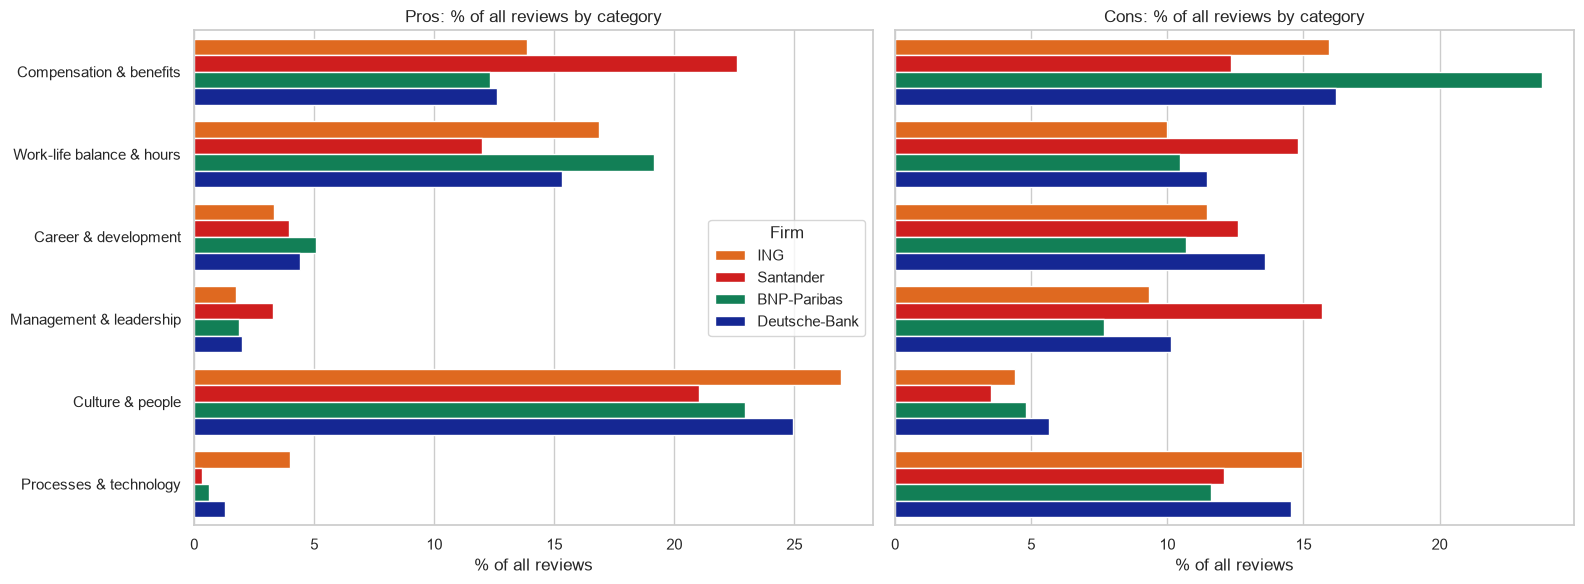

In [55]:
# Shares per comparable category and firm, same colors as the EDA
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, shares, title in zip(axes, [pros_shares, cons_shares], ["Pros", "Cons"]):
    plot_df = (shares[COMPARABLE].rename_axis(columns=None).reset_index()
               .melt(id_vars="firm", var_name="Category", value_name="Share"))

    sns.barplot(data=plot_df, x="Share", y="Category", hue="firm", order=COMPARABLE,
                hue_order=FIRMS, palette=PALETTE, ax=ax)

    ax.set_title(f"{title}: % of all reviews by category")
    ax.set_xlabel("% of all reviews")
    ax.set_ylabel("")

# One legend is enough
axes[0].legend(title="Firm")
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

A high `cons %` is not a problem by itself: percentages are relative, so if a firm has fewer pay complaints, the weight of the other categories goes up even if nothing got worse. What matters is whether ING has a **worse balance than its peers** (4.2). Before that, the gap between ING and the peer mean on each side:

In [56]:
def peer_comparison(shares):
    # ING vs. the simple mean of its peers (balanced sample), in pp
    # Same gap_vs_peers() as section 3, so it is measured the same way everywhere
    out = pd.DataFrame({
        TARGET: shares.loc[TARGET],
        "Peer mean": shares.loc[PEERS].mean(),
    })
    out["Gap vs peers (pp)"] = gap_vs_peers(shares)
    return out

pros_peer_comparison = peer_comparison(pros_shares.loc[:, COMPARABLE]).round(1)
cons_peer_comparison = peer_comparison(cons_shares.loc[:, COMPARABLE]).round(1)

print("PROS: ING vs. peer mean")
display(pros_peer_comparison)

print("CONS: ING vs. peer mean")
display(cons_peer_comparison)

PROS: ING vs. peer mean


,ING,Peer mean,Gap vs peers (pp)
topic_pros_red,,,
Compensation & benefits,13.9,15.9,-2.0
Work-life balance & hours,16.9,15.5,1.4
Career & development,3.3,4.5,-1.1
Management & leadership,1.7,2.4,-0.6
Culture & people,26.9,23.0,4.0
Processes & technology,4.0,0.7,3.3


CONS: ING vs. peer mean


,ING,Peer mean,Gap vs peers (pp)
topic_cons_red,,,
Compensation & benefits,15.9,17.4,-1.5
Work-life balance & hours,10.0,12.3,-2.3
Career & development,11.5,12.3,-0.8
Management & leadership,9.3,11.2,-1.8
Culture & people,4.4,4.7,-0.3
Processes & technology,14.9,12.7,2.2


**Reading the gaps.** In pros, ING stands out in *Culture & people* (+4.0 pp) and, less so, in *Work-life balance & hours* (+1.4 pp); it is mentioned less in *Compensation & benefits* (-2.0 pp) and *Career & development* (-1.1 pp). In cons, ING has fewer complaints than the peer mean in five of the six categories (the largest gaps are *Work-life balance & hours*, -2.3 pp, and *Management & leadership*, -1.8 pp) and more only in *Processes & technology* (+2.2 pp).

Two warnings from section 3 limit how far this can be pushed: pros of *Processes & technology* are almost absent in the peers (0.7% on average against 4.0% in ING), and *Career* and *Management* pros are under-captured. A pros gap in these categories is therefore not comparable with its cons gap on its own.

#### One-sided categories (outside the net balance)

These categories have no counterpart on the other side, so they cannot enter the net balance. They still say something about attraction (employer branding), so they are only compared by their gap versus the peer mean.

In [57]:
# No net balance here, just the gap vs. peers
print("PROS only: ING vs. peer mean")
display(peer_comparison(pros_shares.loc[:, ["Company brand & prestige", "International environment"]]).round(1))

print("CONS only: ING vs. peer mean")
display(peer_comparison(cons_shares.loc[:, ["Language & HQ location"]]).round(1))

PROS only: ING vs. peer mean


,ING,Peer mean,Gap vs peers (pp)
topic_pros_red,,,
Company brand & prestige,3.7,6.3,-2.6
International environment,2.6,1.9,0.7


CONS only: ING vs. peer mean


,ING,Peer mean,Gap vs peers (pp)
topic_cons_red,,,
Language & HQ location,2.3,2.9,-0.5


ING is the firm that mentions *Company brand & prestige* least (3.7% vs. 6.3% peer mean, -2.6 pp, same sign in all the robustness scenarios of section 3), a relevant point for attraction. It must be read with care: the keywords of that topic include the firm name, which inflates Santander (7.5%), as noted in section 3. *International environment* is slightly above the peers (+0.7 pp) and *Language & HQ location* slightly below (-0.5 pp, a mean driven by BNP-Paribas at 6.9%); both are too small to support a conclusion.

### 4.2. Pros vs. Cons: Net Balance

For the six comparable categories, `net balance = pros % - cons %`. The gap versus the peer mean is computed on that net balance: positive means ING is better balanced than its peers in that category, negative means worse. Since the net gap is `pros gap - cons gap` by construction, I show both gaps to see which side drives each result.

In [58]:
# Net balance only for categories that exist in pros and cons
net_balance = (pros_shares[COMPARABLE] - cons_shares[COMPARABLE]).rename_axis(columns="Category")

net_comparison = pd.DataFrame({
    f"{TARGET} net balance": net_balance.loc[TARGET],
    "Peer mean net balance": net_balance.loc[PEERS].mean(),
    "Pros gap (pp)": gap_vs_peers(pros_shares[COMPARABLE]),
    "Cons gap (pp)": gap_vs_peers(cons_shares[COMPARABLE]),
})
net_comparison["Net gap vs peers (pp)"] = (
    net_comparison[f"{TARGET} net balance"] - net_comparison["Peer mean net balance"]
)

# Sanity check: net gap = pros gap - cons gap
assert np.allclose(net_comparison["Net gap vs peers (pp)"],
                   net_comparison["Pros gap (pp)"] - net_comparison["Cons gap (pp)"])

# Same order (best to worst net gap) in every table and chart of the section
net_comparison = net_comparison.sort_values("Net gap vs peers (pp)", ascending=False)
net_comparison.index.name = "Category"
CATEGORY_ORDER = net_comparison.index.tolist()

print("ING vs. peer mean")
display(net_comparison.round(1))

# By firm, to see what the peer mean hides
print("Net balance by firm (pp)")
display(net_balance.loc[FIRMS, CATEGORY_ORDER].round(1))

ING vs. peer mean


,ING net balance,Peer mean net balance,Pros gap (pp),Cons gap (pp),Net gap vs peers (pp)
Category,,,,,
Culture & people,22.5,18.3,4.0,-0.3,4.2
Work-life balance & hours,6.9,3.2,1.4,-2.3,3.6
Management & leadership,-7.6,-8.8,-0.6,-1.8,1.2
Processes & technology,-10.9,-12.0,3.3,2.2,1.1
Career & development,-8.1,-7.8,-1.1,-0.8,-0.3
Compensation & benefits,-2.1,-1.6,-2.0,-1.5,-0.5


Net balance by firm (pp)


Category,Culture & people,Work-life balance & hours,Management & leadership,Processes & technology,Career & development,Compensation & benefits
firm,,,,,,
ING,22.5,6.9,-7.6,-10.9,-8.1,-2.1
Santander,17.5,-2.8,-12.4,-11.7,-8.7,10.3
BNP-Paribas,18.1,8.7,-5.8,-11.0,-5.6,-11.4
Deutsche-Bank,19.3,3.9,-8.1,-13.3,-9.2,-3.6


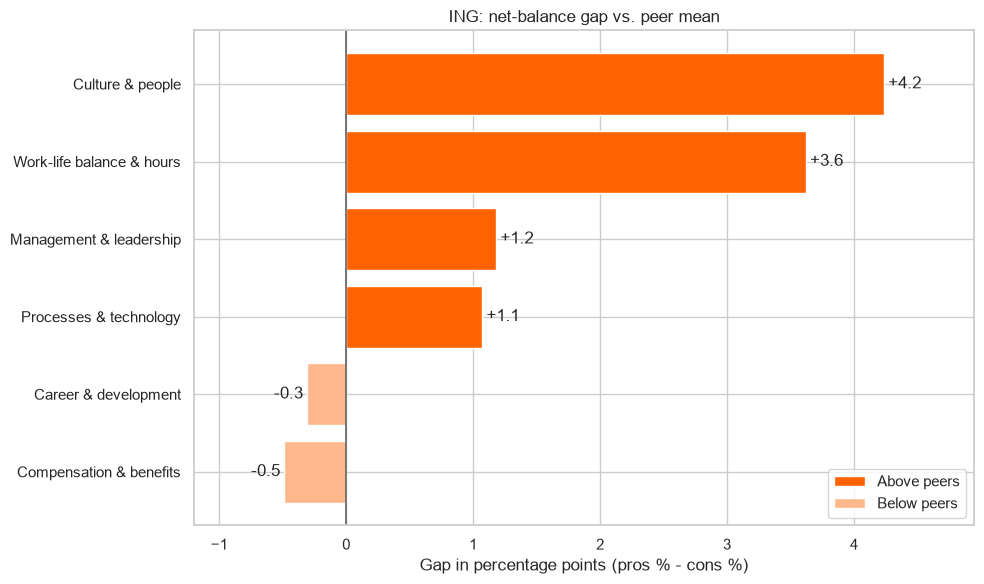

In [59]:
# Net gap by category. Dark = ING above peers, light = below
fig, ax = plt.subplots(figsize=(10, 6))

gaps = net_comparison["Net gap vs peers (pp)"]
colors = [PALETTE[TARGET] if g >= 0 else lighten(PALETTE[TARGET], 0.55) for g in gaps]

bars = ax.barh(gaps.index, gaps.values, color=colors)
ax.bar_label(bars, fmt="%+.1f", padding=3)
ax.axvline(0, color="#616161", linewidth=1.2)
ax.invert_yaxis()   # best net gap on top, same order as the tables
ax.margins(x=0.15)  # room for the value labels

ax.set_title(f"{TARGET}: net-balance gap vs. peer mean")
ax.set_xlabel("Gap in percentage points (pros % - cons %)")
ax.set_ylabel("")
ax.legend(handles=[Patch(facecolor=PALETTE[TARGET], label="Above peers"),
                   Patch(facecolor=lighten(PALETTE[TARGET], 0.55), label="Below peers")],
          loc="lower right")

plt.tight_layout()
plt.show()

#### 4.2b. How certain are these gaps?

The gaps above are point estimates. To see which ones can be told apart from zero, I resample each firm's reviews with replacement (2,000 times, fixed seed; pros and cons of a review go together), recompute the three gaps each time and take the 2.5%-97.5% range. If the interval includes zero, the gap is a direction, not a proven difference.

,Pros gap (pp),Pros 95% CI,Cons gap (pp),Cons 95% CI,Net gap (pp),Net 95% CI,Net gap excludes 0?
Category,,,,,,,
Culture & people,4.0,"[+1.4, +6.5]",-0.3,"[-1.4, +1.0]",4.2,"[+1.3, +7.1]",Yes
Work-life balance & hours,1.4,"[-0.8, +3.5]",-2.3,"[-3.9, -0.4]",3.6,"[+0.7, +6.4]",Yes
Management & leadership,-0.6,"[-1.5, +0.2]",-1.8,"[-3.5, -0.0]",1.2,"[-0.8, +3.1]",No
Processes & technology,3.3,"[+2.2, +4.3]",2.2,"[+0.3, +4.4]",1.1,"[-1.4, +3.3]",No
Career & development,-1.1,"[-2.2, -0.0]",-0.8,"[-2.7, +1.1]",-0.3,"[-2.4, +1.9]",No
Compensation & benefits,-2.0,"[-3.9, +0.1]",-1.5,"[-3.8, +0.6]",-0.5,"[-3.4, +2.6]",No


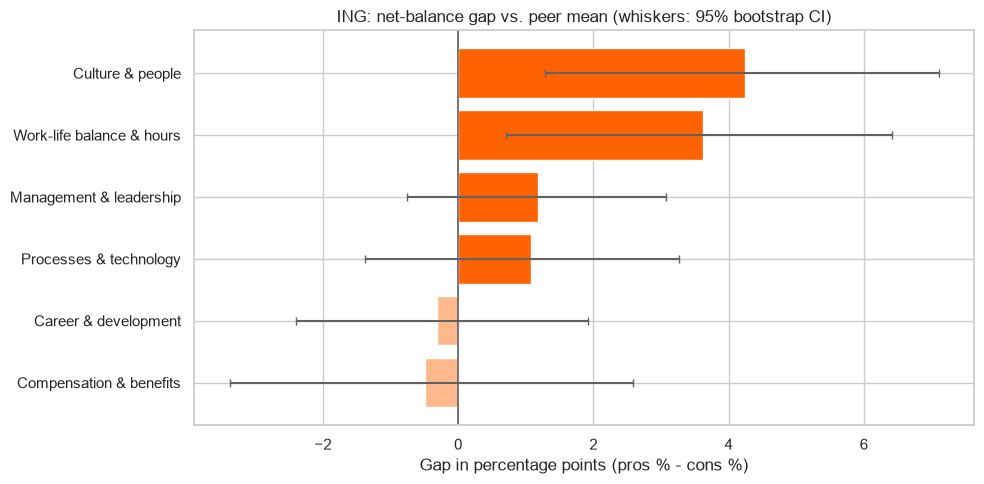

**Reading.** Net gaps whose interval excludes zero: *Culture & people*, *Work-life balance & hours*. The others are directions that this sample cannot separate from zero.

In [60]:
def bootstrap_net_gaps(n_boot=2000):
    # Resampling reviews of each firm, pros and cons together
    rng = np.random.default_rng(SEED)
    code_of = {c: j for j, c in enumerate(COMPARABLE)}
    firm_arr = clean_df["firm"].to_numpy()
    pros_codes = clean_df["cat_pros"].map(code_of).fillna(-1).astype(int).to_numpy()   # -1 = outside the six compared
    cons_codes = clean_df["cat_cons"].map(code_of).fillna(-1).astype(int).to_numpy()

    def shares(codes):
        # % per category; reviews outside the six stay in the denominator
        return np.stack([(codes == j).mean(axis=1) for j in range(len(COMPARABLE))], axis=1) * 100

    boot = {}
    for f in FIRMS:
        idx = np.where(firm_arr == f)[0]
        rows = idx[rng.integers(0, len(idx), size=(n_boot, len(idx)))]       # same rows for pros and cons
        boot[f] = (shares(pros_codes[rows]), shares(cons_codes[rows]))

    pros_gap = boot[TARGET][0] - np.mean([boot[p][0] for p in PEERS], axis=0)
    cons_gap = boot[TARGET][1] - np.mean([boot[p][1] for p in PEERS], axis=0)
    ci = lambda a: pd.DataFrame(np.percentile(a, [2.5, 97.5], axis=0).T, index=COMPARABLE, columns=["low", "high"])
    return ci(pros_gap), ci(cons_gap), ci(pros_gap - cons_gap)

ci_pros, ci_cons, ci_net = bootstrap_net_gaps()

fmt = lambda ci_df: [f"[{ci_df.loc[c, 'low']:+.1f}, {ci_df.loc[c, 'high']:+.1f}]" for c in net_comparison.index]
uncertainty = pd.DataFrame({
    "Pros gap (pp)": net_comparison["Pros gap (pp)"], "Pros 95% CI": fmt(ci_pros),
    "Cons gap (pp)": net_comparison["Cons gap (pp)"], "Cons 95% CI": fmt(ci_cons),
    "Net gap (pp)": net_comparison["Net gap vs peers (pp)"], "Net 95% CI": fmt(ci_net),
})
uncertainty["Net gap excludes 0?"] = ["Yes" if (ci_net.loc[c, "low"] > 0 or ci_net.loc[c, "high"] < 0) else "No" for c in uncertainty.index]
display(uncertainty.round(1))

g = net_comparison["Net gap vs peers (pp)"]
err = [np.clip(g - ci_net.loc[g.index, "low"], 0, None).values, np.clip(ci_net.loc[g.index, "high"] - g, 0, None).values]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(g.index, g.values, xerr=err, color=[PALETTE[TARGET] if v >= 0 else lighten(PALETTE[TARGET], 0.55) for v in g],
        error_kw={"ecolor": "#616161", "capsize": 3})
ax.axvline(0, color="#616161", linewidth=1.2)
ax.invert_yaxis()
ax.set_title(f"{TARGET}: net-balance gap vs. peer mean (whiskers: 95% bootstrap CI)")
ax.set_xlabel("Gap in percentage points (pros % - cons %)")
plt.tight_layout()
plt.show()

sig = uncertainty.index[uncertainty["Net gap excludes 0?"] == "Yes"].tolist()
display(Markdown("**Reading.** " + (
    f"Net gaps whose interval excludes zero: {', '.join('*' + c + '*' for c in sig)}. The others are directions that this sample cannot separate from zero."
    if sig else
    "No net gap has an interval that excludes zero: with about 1,500 reviews per firm, every gap is a direction and none can be told apart from the peers' average with 95% confidence.")))

**Reading the net gap.** The two categories where pros and cons both favour ING are the solid ones: *Culture & people* (+4.2 pp: more praise, +4.0, and no more complaints, -0.3) and *Work-life balance & hours* (+3.6 pp: more praise, +1.4, and fewer complaints, -2.3). Both agree with the robustness check of section 3. (Figures are rounded one by one, so a net gap can differ by 0.1 pp from the sum of its two gaps.)

The other four need care:

- **Management & leadership (+1.2 pp) and Processes & technology (+1.1 pp)** are not read as strengths. In *Management*, the positive value comes from fewer complaints (-1.8 pp) while ING is also praised less (-0.6 pp), in a category with under-captured pros and an unstable cons gap (it falls from -1.8 to 0.0 pp without outlier reassignment). In *Processes*, the positive value comes from a pros gap (+3.3 pp) over a base that is almost empty in the peers, while ING actually receives *more* complaints (+2.2 pp).
- **Compensation & benefits (-0.5 pp) and Career & development (-0.3 pp)** have a slightly negative net gap, but both pros and cons are lower than in the peers: ING talks less about them in both directions rather than being worse (as already seen for compensation in section 3).

The peer mean also hides spread. In *Compensation*, BNP-Paribas (-11.4) and Santander (+10.3) are opposite extremes, and the high share of pay complaints in BNP-Paribas flagged in section 3 (23.7% vs. 12-16% in the other firms after outlier reassignment, 17.6% vs. 8.7%-10.8% before it) holds in the net balance, so it is not an artifact of the raw share. In *Work-life balance*, BNP-Paribas (+8.7) is above ING (+6.9) and Santander (-2.8) pulls the peer mean down.

For these reasons the net gap is a **first signal**, not a verdict: a category is only a priority weakness if it is also supported by the cross-check below.

### 4.3. Cross-check with Rating & Recommendation

If a category is really a problem, the reviews that complain about it should also have a worse `overall_rating` (and a lower recommendation) than the rest of the firm's reviews. Each review has exactly one complaint category (`cat_cons`), so every review contributes to a single category.

How I did it:

- **Baseline:** each firm's own mean rating and recommendation rate, so the different rating level of each firm (see 1.4) doesn't distort the comparison. It includes reviews with no complaint in that category, so a negative gap means "worse than the average review of the firm".
- **Recommendation:** only reviews with an opinion (`Yes` / `No`), same as `%RecommendWithOp` in 1.4.
- **Uncertainty:** I show the 95% half-width (±) and the number of reviews, because small categories rest on few reviews. A gap smaller than its ± can't be told apart from noise (normal approximation, so only indicative).
- **Peers:** same gaps for the three peers (simple mean), to see if the penalty is specific to ING or common to every firm: reviews that complain about something tend to be rated lower anyway.

In [61]:
def recommendation_rate(s):
    # % of "Yes" among reviews with an opinion (as %RecommendWithOp in 1.4)
    opinions = s[s.isin(["Yes", "No"])]
    return (opinions == "Yes").mean() * 100 if len(opinions) else np.nan

def n_opinions(s):
    return s.isin(["Yes", "No"]).sum()

def ci95_mean(s):
    # Same 1.96 * sem as in 1.4
    return 1.96 * s.sem()

def ci95_rate(s):
    # Normal approximation, in pp
    opinions = s[s.isin(["Yes", "No"])]
    if len(opinions) == 0:
        return np.nan
    p = (opinions == "Yes").mean()
    return 1.96 * np.sqrt(p * (1 - p) / len(opinions)) * 100

# Firm baselines (ING should match 1.4: 4.00 and 81.87%)
firm_baselines = clean_df.groupby("firm", observed=True).agg(
    firm_mean_rating=("overall_rating", "mean"),
    firm_recommend_rate=("recommends", recommendation_rate),
).reindex(FIRMS)

# Rating and recommendation of those who complain about each category
check = (
    clean_df[clean_df["cat_cons"].isin(COMPARABLE)]
    .groupby(["firm", "cat_cons"], observed=True)
    .agg(
        n_reviews=("overall_rating", "size"),
        n_with_opinion=("recommends", n_opinions),
        mean_rating=("overall_rating", "mean"),
        rating_ci=("overall_rating", ci95_mean),
        recommend_rate=("recommends", recommendation_rate),
        recommend_ci=("recommends", ci95_rate),
    )
    .join(firm_baselines)
)
check["rating_gap"] = check["mean_rating"] - check["firm_mean_rating"]
check["recommend_gap"] = check["recommend_rate"] - check["firm_recommend_rate"]

# ING vs. peer mean, as in 4.1 and 4.2
ing_check = check.xs(TARGET, level="firm")
is_peer = check.index.get_level_values("firm").isin(PEERS)
peer_check = check[is_peer].groupby(level="cat_cons")[["rating_gap", "recommend_gap"]].mean()

cross_check = pd.DataFrame({
    "Net gap (pp)": net_comparison["Net gap vs peers (pp)"],
    "Cons gap (pp)": net_comparison["Cons gap (pp)"],
    "Complaints (n)": ing_check["n_reviews"],
    "With opinion (n)": ing_check["n_with_opinion"],
    "ING rating gap": ing_check["rating_gap"],
    "± (rating)": ing_check["rating_ci"],
    "Peers rating gap": peer_check["rating_gap"],
    "ING recommend gap (pp)": ing_check["recommend_gap"],
    "± (recommend, pp)": ing_check["recommend_ci"],
    "Peers recommend gap (pp)": peer_check["recommend_gap"],
}).loc[CATEGORY_ORDER].round(2)

cross_check

,Net gap (pp),Cons gap (pp),Complaints (n),With opinion (n),ING rating gap,± (rating),Peers rating gap,ING recommend gap (pp),"± (recommend, pp)",Peers recommend gap (pp)
Culture & people,4.24,-0.27,66,40,-0.34,0.27,-0.62,-6.87,13.42,-22.79
Work-life balance & hours,3.62,-2.25,150,78,0.08,0.14,0.05,0.18,8.52,1.28
Management & leadership,1.18,-1.83,140,91,-0.68,0.21,-0.58,-24.73,10.17,-20.75
Processes & technology,1.07,2.19,224,125,-0.05,0.12,0.09,2.13,6.43,4.43
Career & development,-0.31,-0.83,172,108,-0.03,0.13,-0.07,-0.39,7.33,1.07
Compensation & benefits,-0.49,-1.50,239,128,-0.07,0.12,-0.09,-0.62,6.76,-0.55


**Reading the cross-check (ING).** The baseline is 4.00 in rating and 81.9% in recommendation. The reviews that complain about *Management & leadership* are by far the most negative: -0.68 points in rating and -24.7 pp in recommendation. The next largest drop is *Culture & people* (-0.34 points, -6.9 pp), but it rests on only 66 complaints, so it is indicative. In *Compensation & benefits*, *Career & development* and *Processes & technology* the rating gap is between -0.03 and -0.07 and the recommendation gap stays within ±2.2 pp: there is no sign that these complaints hurt. Complaints about *Work-life balance & hours* are not penalised at all (+0.08 points, +0.2 pp).

The two signals only coincide in part. None of the categories where ING looks worse than its peers (more complaints in *Processes & technology*, slightly negative net gap in *Compensation* and *Career*) shows a rating penalty, whereas the category with the largest penalty (*Management*) is one where ING receives fewer complaints than its peers (-1.8 pp). The `Peers` columns show whether that penalty is specific to ING or typical of any firm.

#### **Peers Comparison: Conclusions**

No category combines more complaints than the market with a clear rating penalty, so no confirmed weakness versus the peers appears. What differs is how solid each finding is:

- **Strengths to exploit (robust):**
    - *Work-life balance & hours* (net gap +3.6 pp): more praise, fewer complaints, and the complaints that exist do not lower rating or recommendation. It is also the most robust result of section 3.
    - *Culture & people* (+4.2 pp): ING is praised more than its peers without receiving more complaints. The few complaints it does receive are costly (-0.34 points in rating, on 66 reviews), so the message is to protect it.
    - **Proposal for ING:** these two are the strongest evidence-based messages for employer branding and recruitment.
- **Not a weakness versus the market:**
    - *Compensation & benefits* and *Career & development*: tiny negative net gaps (-0.5 and -0.3 pp), pros and cons both lower than in the peers, and complaints that do not lower rating or recommendation. The pay-complaint peak in the data is BNP-Paribas, not ING.
- **To watch and confirm in section 5:**
    - *Management & leadership*: ING receives fewer complaints than its peers, but those who complain are far more negative (-0.68 points in rating, -24.7 pp in recommendation). The lever is the quality of line management; whether it shows up among former employees' reasons for leaving must be checked in section 5.
    - *Processes & technology*: the only category with more complaints than the peers (+2.2 pp), but the gap shrinks to +0.4 pp without outlier reassignment and the complaints do not lower rating or recommendation. It is a frequency signal, not yet evidence of damage.
- **Employer branding:** *Company brand & prestige* is mentioned less in ING than in its peers (-2.6 pp). It is a one-sided, pros-only signal partly inflated by the firm name in Santander, so it is indicative.

**Limitations of this section.** All results are point estimates on a single balanced sample of ~1,500 reviews per firm, and each review is assigned to one category only. Pros and cons categories are not equally well captured, so only gaps versus peers are interpreted, never absolute levels.

## 5. Former vs Current Employees

Section 4 left two open questions: does *Management & leadership* (the biggest rating penalty among those who complain) hide a retention problem, and is *Processes & technology* (the only category with more complaints than the peers, but a fragile one) a real weakness? Former employees are the place to look: their cons are the closest thing in this dataset to *reasons for leaving*, and their pros show what they valued before leaving. I compare current vs. former inside ING (5.3), then ING's leavers with the peers' leavers (5.4-5.6), read some reviews (5.7), add two extra cuts, tenure and before/after 2020 (5.8-5.9), and close with the conclusions (5.10).

Decisions for the whole section:

- **Topics, not sentiment.** Former employees rate lower in every firm (selection bias, see 1.4), so comparing ratings between the two groups says nothing about ING. I only compare the topic mix.
- **Same base as section 4.** Every share uses all reviews of that firm and status group as denominator. As a robustness check I repeat the current-vs-former comparison with only reviews with an identified complaint, because current employees may leave more empty answers and that would dilute their categories.
- **Peer benchmark.** Simple mean of the three peers, as in section 4.
- **Small groups.** Former employees are the smallest groups of the notebook, so differences come with 95% intervals and, since six categories are tested at once, with a Benjamini-Hochberg correction (it controls the share of false discoveries when many categories are tested together).
- **Status.** Every review in the sample has a known status (`Unknown (excluded)` in 5.1 is zero in all firms). I keep the filter anyway in case the data change.

### 5.1. Setup and sample sizes

In [62]:
STATUSES = ["Current", "Former"]
MATERIAL_PP = 1.0     # gaps under 1 pp are not read as differences
MIN_PENALTY = 0.10    # rating gaps under 0.10 are not read as a penalty
ONE_SIDED_PROS = ["Company brand & prestige", "International environment"]   # pros only (section 4.1)
ONE_SIDED_CONS = ["Language & HQ location"]                                   # cons only (section 4.1)

# Only reviews with known status
emp_df = clean_df[clean_df["status"].isin(STATUSES)].copy()

# Group sizes
size_tbl = pd.crosstab(emp_df["firm"], emp_df["status"]).reindex(FIRMS)[STATUSES]
size_tbl["Unknown (excluded)"] = (clean_df["status"] == "Unknown").groupby(clean_df["firm"], observed=True).sum().reindex(FIRMS)
size_tbl["% Former"] = size_tbl["Former"] / size_tbl[STATUSES].sum(axis=1) * 100

# Profile per group (empty or generic cons dilute the other categories)
profile = (emp_df.groupby(["firm", "status"], observed=True)
           .agg(reviews=("overall_rating", "size"),
                mean_rating=("overall_rating", "mean"),
                recommend_rate=("recommends", recommendation_rate),
                pct_cons_no_content=("cat_cons", lambda s: (s == "No content").mean() * 100),
                pct_cons_mixed=("cat_cons", lambda s: (s == "Mixed / generic").mean() * 100))
           .round(1))

print("Reviews by status (the 'Unknown' ones are left out of this section)")
display(size_tbl.round(1))
print("Profile of each firm x status group")
display(profile)

smallest = size_tbl[STATUSES].stack().idxmin()
display(Markdown(f"**Reading.** The smallest group is **{smallest[0]} - {smallest[1]}** with {size_tbl[STATUSES].min().min()} reviews. "
                 f"ING has {size_tbl.loc[TARGET, 'Former']} former-employee reviews, so every figure about ING's leavers below is a "
                 f"point estimate with wide intervals: differences of a few pp cannot be told apart from noise."))

Reviews by status (the 'Unknown' ones are left out of this section)


status,Current,Former,Unknown (excluded),% Former
firm,,,,
ING,1009,491,0,32.7
Santander,910,589,0,39.3
BNP-Paribas,969,530,0,35.4
Deutsche-Bank,945,555,0,37.0


Profile of each firm x status group


reviews  mean_rating  recommend_rate  \
firm          status                                          
ING           Current     1009          4.1            84.9   
              Former       491          3.8            74.7   
Santander     Current      910          3.8            69.8   
              Former       589          3.3            49.5   
BNP-Paribas   Current      969          3.8            79.4   
              Former       530          3.5            62.4   
Deutsche-Bank Current      945          3.8            75.3   
              Former       555          3.5            61.0   

                       pct_cons_no_content  pct_cons_mixed  
firm          status                                        
ING           Current                 14.7            18.2  
              Former                  13.2            15.7  
Santander     Current                 11.2            16.4  
              Former                  10.5            17.1  
BNP-Paribas   Current                 11.7            12.8  
              Former                  12.3            11.3  
Deutsche-Bank Current                 13.9            15.0  
              Former                  10.8            15.7

**Reading.** The smallest group is **ING - Former** with 491 reviews. ING has 491 former-employee reviews, so every figure about ING's leavers below is a point estimate with wide intervals: differences of a few pp cannot be told apart from noise.

### 5.2. Helper functions

I define everything once so cons and pros, ING and peers, are measured the same way: shares by firm and status, a two-proportion z-test (current vs. former), the Benjamini-Hochberg correction and a bootstrap (resampling reviews inside each firm and status group) for the intervals of the gaps versus peers.

In [63]:
def shares_by_status(cat_col, identified_only=False):
    # Category shares per firm and status (denominator = all reviews of the group)
    # identified_only=True drops empty / generic reviews: robustness check
    d = emp_df[emp_df[cat_col].isin(COMPARABLE)] if identified_only else emp_df
    tab = pd.crosstab([d["firm"], d["status"]], d[cat_col], normalize="index").mul(100)
    missing = [c for c in COMPARABLE if c not in tab.columns]
    return tab.reindex(columns=list(tab.columns) + missing, fill_value=0)

def group_shares(tab, status):
    # One status, firms in FIRMS order
    return tab.xs(status, level="status").reindex(FIRMS)

def two_prop_test(k1, n1, k2, n2):
    # Two-proportion z-test
    if n1 == 0 or n2 == 0:
        return np.nan, np.nan
    p = (k1 + k2) / (n1 + n2)
    se = sqrt(p * (1 - p) * (1 / n1 + 1 / n2))
    if se == 0:
        return 0.0, 1.0
    z = (k1 / n1 - k2 / n2) / se
    return z, erfc(abs(z) / sqrt(2))

def bh_adjust(p):
    # Benjamini-Hochberg correction, several categories are tested at once
    p = np.asarray(p, dtype=float)
    n = len(p)
    order = np.argsort(p)
    adj = np.empty(n)
    prev = 1.0
    for rank, idx in zip(range(n, 0, -1), order[::-1]):
        prev = min(prev, p[idx] * n / rank)
        adj[idx] = prev
    return adj

def status_comparison(cat_col, firm, categories, identified_only=False):
    # Former vs. current inside one firm: shares, difference, 95% interval and z-test (BH-adjusted)
    d = emp_df[emp_df["firm"] == firm]
    if identified_only:
        d = d[d[cat_col].isin(COMPARABLE)]
    cur, frm = d.loc[d["status"] == "Current", cat_col], d.loc[d["status"] == "Former", cat_col]
    n1, n2 = len(cur), len(frm)
    rows = []
    for cat in categories:
        k1, k2 = (cur == cat).sum(), (frm == cat).sum()
        p1, p2 = k1 / n1, k2 / n2
        _, pval = two_prop_test(k2, n2, k1, n1)
        half = 1.96 * sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2) * 100
        rows.append({"Category": cat, "Current %": p1 * 100, "Former %": p2 * 100,
                     "Diff (pp)": (p2 - p1) * 100, "± (pp)": half, "p-value": pval})
    out = pd.DataFrame(rows).set_index("Category")
    out["p (BH-adj.)"] = bh_adjust(out["p-value"])
    return out

def boot_shares(cat_col, firm, status, n_boot, rng):
    # Bootstrap of the category shares (reviews outside the 6 stay in the denominator)
    s = emp_df.loc[(emp_df["firm"] == firm) & (emp_df["status"] == status), cat_col]
    codes = s.map({c: j for j, c in enumerate(COMPARABLE)}).fillna(-1).astype(int).to_numpy()   # -1 = other category
    draws = codes[rng.integers(0, len(codes), size=(n_boot, len(codes)))]
    return np.stack([(draws == j).mean(axis=1) for j in range(len(COMPARABLE))], axis=1) * 100

def bootstrap_exit_gaps(cat_col="cat_cons", n_boot=2000):
    # 95% intervals for the exit gap and the premium gap (see 5.4)
    rng = np.random.default_rng(SEED)
    boot = {(f, st): boot_shares(cat_col, f, st, n_boot, rng) for f in FIRMS for st in STATUSES}
    premium = lambda f: boot[(f, "Former")] - boot[(f, "Current")]
    exit_gap = boot[(TARGET, "Former")] - np.mean([boot[(p, "Former")] for p in PEERS], axis=0)
    premium_gap = premium(TARGET) - np.mean([premium(p) for p in PEERS], axis=0)
    ci = lambda a: pd.DataFrame(np.percentile(a, [2.5, 97.5], axis=0).T, index=COMPARABLE, columns=["low", "high"])
    return ci(exit_gap), ci(premium_gap)

def plot_status_bars(ax, tbl, title):
    # Current (dark) vs. former (light) bars per category
    y, h = np.arange(len(tbl)), 0.38
    ax.barh(y - h / 2, tbl["Current %"], h, color=PALETTE[TARGET], label="Current")
    ax.barh(y + h / 2, tbl["Former %"], h, color=lighten(PALETTE[TARGET], 0.55), label="Former")
    for i, (cur, frm, d, p) in enumerate(zip(tbl["Current %"], tbl["Former %"], tbl["Diff (pp)"], tbl["p (BH-adj.)"])):
        ax.text(max(cur, frm) + 0.4, i, f"{d:+.1f}{'*' if p < 0.05 else ''}", va="center", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(tbl.index)
    ax.invert_yaxis()
    ax.margins(x=0.15)
    ax.set_title(title)
    ax.set_xlabel("% of the group's reviews")

def read_status_shift(tbl, label):
    # Text reading built from the table, so it always matches the numbers
    up, down = tbl["Diff (pp)"].idxmax(), tbl["Diff (pp)"].idxmin()
    sig = tbl[tbl["p (BH-adj.)"] < 0.05].sort_values("Diff (pp)", ascending=False)
    text = (f"**Reading ({label}).** Biggest rise among former employees: *{up}* ({tbl.loc[up, 'Diff (pp)']:+.1f} pp); "
            f"biggest drop: *{down}* ({tbl.loc[down, 'Diff (pp)']:+.1f} pp). ")
    if len(sig):
        text += "Differences that survive the multiple-comparison correction: " + \
                ", ".join(f"*{c}* ({r['Diff (pp)']:+.1f} pp)" for c, r in sig.iterrows()) + "."
    else:
        text += "None survives the multiple-comparison correction: with these sample sizes the shifts are indicative, not conclusive."
    display(Markdown(text))

### 5.3. ING: current vs. former employees

Which topics change once the author has left? In **cons**, a category that grows among former employees is a candidate *reason for leaving*. In **pros**, a category that shrinks among former employees is something people stop seeing once they leave, a perceived benefit that doesn't retain.

`Diff (pp)` is Former minus Current and `*` marks differences that stay significant after the correction. The 6 comparable categories plus the one-sided ones of each side are tested together.

ING CONS: current (n=1009) vs. former (n=491)


,Current %,Former %,Diff (pp),± (pp),p-value,p (BH-adj.),Same sign (identified only)
Category,,,,,,,
Culture & people,3.667,5.906,2.239,2.386,0.047,0.331,True
Management & leadership,8.622,10.794,2.172,3.246,0.175,0.408,True
Language & HQ location,1.883,3.259,1.376,1.780,0.098,0.342,n/a
Work-life balance & hours,9.613,10.794,1.181,3.293,0.474,0.664,True
Processes & technology,15.064,14.664,-0.400,3.829,0.838,0.838,True
Compensation & benefits,16.155,15.479,-0.676,3.923,0.737,0.838,True
Career & development,12.091,10.183,-1.908,3.347,0.276,0.484,True


ING PROS: current vs. former


,Current %,Former %,Diff (pp),± (pp),p-value,p (BH-adj.),Same sign (identified only)
Category,,,,,,,
Culture & people,26.363,28.106,1.743,4.817,0.475,0.524,True
Company brand & prestige,3.171,4.888,1.717,2.192,0.100,0.217,n/a
International environment,2.081,3.666,1.585,1.881,0.070,0.217,n/a
Career & development,2.973,4.073,1.100,2.039,0.265,0.409,True
Management & leadership,1.883,1.426,-0.457,1.343,0.524,0.524,True
Processes & technology,4.361,3.259,-1.102,2.014,0.307,0.409,True
Compensation & benefits,14.866,11.813,-3.054,3.601,0.108,0.217,True
Work-life balance & hours,18.038,14.460,-3.577,3.912,0.083,0.217,True


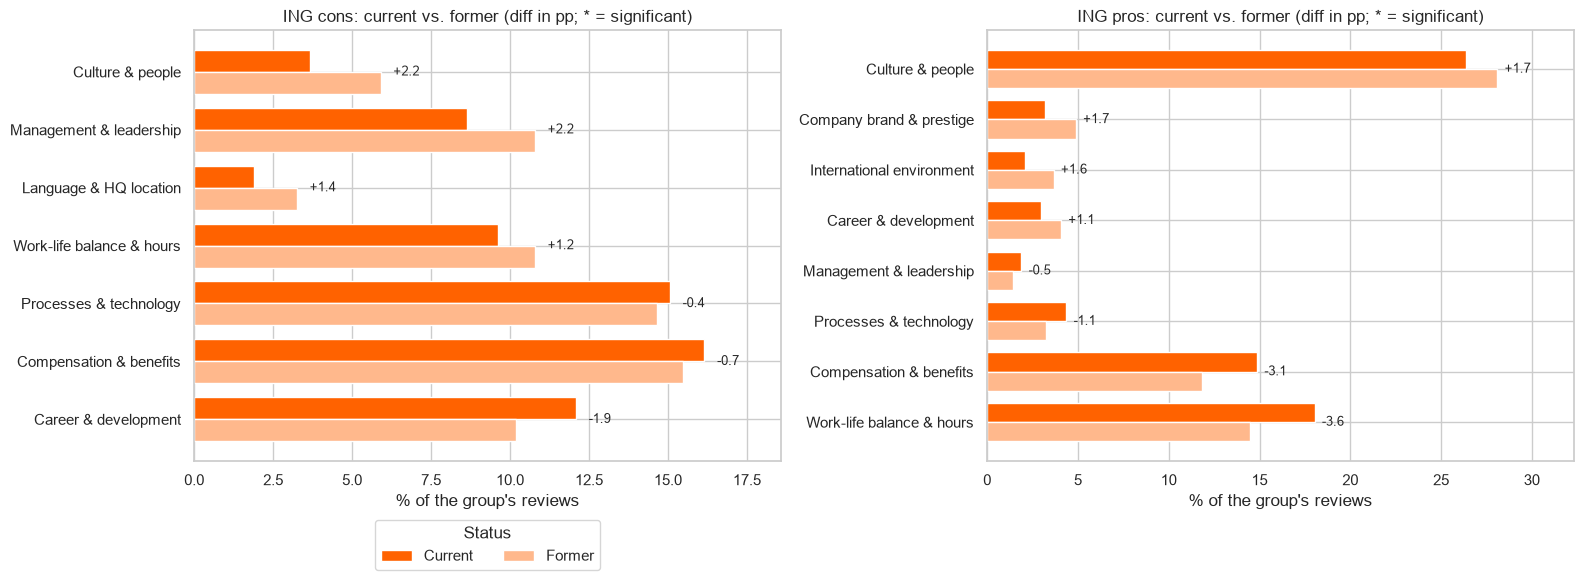

**Reading (cons).** Biggest rise among former employees: *Culture & people* (+2.2 pp); biggest drop: *Career & development* (-1.9 pp). None survives the multiple-comparison correction: with these sample sizes the shifts are indicative, not conclusive.

**Reading (pros).** Biggest rise among former employees: *Culture & people* (+1.7 pp); biggest drop: *Work-life balance & hours* (-3.6 pp). None survives the multiple-comparison correction: with these sample sizes the shifts are indicative, not conclusive.

In [64]:
# Categories tested together on each side
CONS_CATS = COMPARABLE + ONE_SIDED_CONS
PROS_CATS = COMPARABLE + ONE_SIDED_PROS

ing_cons_status = status_comparison("cat_cons", TARGET, CONS_CATS).sort_values("Diff (pp)", ascending=False)
ing_pros_status = status_comparison("cat_pros", TARGET, PROS_CATS).sort_values("Diff (pp)", ascending=False)

# Robustness: same comparison without empty or generic reviews
cons_id = status_comparison("cat_cons", TARGET, COMPARABLE, identified_only=True)["Diff (pp)"]
pros_id = status_comparison("cat_pros", TARGET, COMPARABLE, identified_only=True)["Diff (pp)"]
for tbl, ident in [(ing_cons_status, cons_id), (ing_pros_status, pros_id)]:
    same = (np.sign(tbl["Diff (pp)"]) == np.sign(ident.reindex(tbl.index))).astype(object)
    same[~tbl.index.isin(COMPARABLE)] = "n/a"      # one-sided categories are not in that base
    tbl["Same sign (identified only)"] = same

print(f"ING CONS: current (n={size_tbl.loc[TARGET, 'Current']}) vs. former (n={size_tbl.loc[TARGET, 'Former']})")
display(ing_cons_status.round(3))
print("ING PROS: current vs. former")
display(ing_pros_status.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_status_bars(axes[0], ing_cons_status, "ING cons: current vs. former (diff in pp; * = significant)")
plot_status_bars(axes[1], ing_pros_status, "ING pros: current vs. former (diff in pp; * = significant)")
axes[0].legend(title="Status", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.show()

read_status_shift(ing_cons_status, "cons")
read_status_shift(ing_pros_status, "pros")

**About the "No content" and "Mixed / generic" rows.** I don't interpret them (section 2), but they matter here: if former employees leave fewer empty answers, their other categories grow just because the base is smaller. That's why the table has the `Same sign (identified only)` column: a shift that keeps its sign without empty and generic reviews doesn't depend on that dilution.

### 5.4. Exit reasons: ING's leavers vs. the peers' leavers

I compare the cons of former employees with the peers in two ways, because each answers a different question:

- **Exit gap** = ING's share of a category in its leavers' cons minus the peer mean. *Do ING's leavers complain about this more than the peers' leavers?*
- **Exit premium** = Former share minus Current share inside each firm. It removes what **everybody** in that firm complains about (a theme also common among current employees is not a reason for leaving). The **premium gap** compares ING's premium with the peer mean premium. *Is this theme linked to leaving at ING more than at the peers?* It is a difference of differences, so it can be positive because ING's premium rises or because the peers' premium falls: both columns must be read together.

A gap counts as "above the peers" only if it is at least **1 pp**. A category is a **retention risk** if both gaps are above the peers, a **watch** if only one is, and *in line or below* otherwise. Intervals come from a bootstrap within each firm and status group (2,000 resamples, fixed seed).

In [65]:
cons_tab = shares_by_status("cat_cons")
f_cons = group_shares(cons_tab, "Former")[COMPARABLE]     # leavers' complaints: % of each firm's former reviews
c_cons = group_shares(cons_tab, "Current")[COMPARABLE]
premium = f_cons - c_cons                                  # exit premium by firm (pp)

ci_exit, ci_prem = bootstrap_exit_gaps("cat_cons")

exit_tbl = pd.DataFrame({
    "ING former %":         f_cons.loc[TARGET],
    "Peers former %":       f_cons.loc[PEERS].mean(),
    "Exit gap (pp)":        gap_vs_peers(f_cons),
    "exit_lo": ci_exit["low"], "exit_hi": ci_exit["high"],
    "ING premium (pp)":     premium.loc[TARGET],
    "Peers premium (pp)":   premium.loc[PEERS].mean(),
    "Premium gap (pp)":     gap_vs_peers(premium),
    "prem_lo": ci_prem["low"], "prem_hi": ci_prem["high"],
})

# Both gaps >= 1 pp = retention risk, only one = watch
def exit_signal(r):
    positives = int(r["Exit gap (pp)"] >= MATERIAL_PP) + int(r["Premium gap (pp)"] >= MATERIAL_PP)
    return {2: "Retention risk", 1: "Watch", 0: "In line or below"}[positives]

def exit_evidence(r):
    # Supported only if at least one of the two intervals excludes zero
    excl = lambda lo, hi: lo > 0 or hi < 0
    return "Interval excludes 0" if excl(r["exit_lo"], r["exit_hi"]) or excl(r["prem_lo"], r["prem_hi"]) else "Indicative"

exit_tbl["Signal"] = exit_tbl.apply(exit_signal, axis=1)
exit_tbl["Evidence"] = exit_tbl.apply(exit_evidence, axis=1)
exit_tbl = exit_tbl.sort_values("ING former %", ascending=False)

shown = exit_tbl.copy()
shown["Exit gap 95% CI"] = [f"[{l:+.1f}, {h:+.1f}]" for l, h in zip(shown["exit_lo"], shown["exit_hi"])]
shown["Premium gap 95% CI"] = [f"[{l:+.1f}, {h:+.1f}]" for l, h in zip(shown["prem_lo"], shown["prem_hi"])]
shown = shown[["ING former %", "Peers former %", "Exit gap (pp)", "Exit gap 95% CI",
               "ING premium (pp)", "Peers premium (pp)", "Premium gap (pp)", "Premium gap 95% CI", "Signal", "Evidence"]]

print(f"LEAVERS' COMPLAINTS (cons of former employees), ING (n={size_tbl.loc[TARGET, 'Former']}) vs. peers")
display(shown.round(1))

print("Cons share of former employees by firm (%)")
display(f_cons.loc[FIRMS, exit_tbl.index].round(1))
print("Exit premium by firm (Former - Current, pp)")
display(premium.loc[FIRMS, exit_tbl.index].round(1))

LEAVERS' COMPLAINTS (cons of former employees), ING (n=491) vs. peers


,ING former %,Peers former %,Exit gap (pp),Exit gap 95% CI,ING premium (pp),Peers premium (pp),Premium gap (pp),Premium gap 95% CI,Signal,Evidence
Compensation & benefits,15.5,15.9,-0.5,"[-3.9, +3.5]",-0.7,-2.4,1.7,"[-2.7, +6.3]",Watch,Indicative
Processes & technology,14.7,10.3,4.4,"[+1.0, +7.8]",-0.4,-3.9,3.5,"[-0.6, +7.9]",Retention risk,Interval excludes 0
Work-life balance & hours,10.8,13.0,-2.3,"[-5.5, +0.8]",1.2,1.2,-0.0,"[-3.9, +3.7]",In line or below,Indicative
Management & leadership,10.8,13.3,-2.5,"[-5.6, +0.5]",2.2,3.5,-1.3,"[-5.1, +2.4]",In line or below,Indicative
Career & development,10.2,11.5,-1.3,"[-4.5, +1.7]",-1.9,-1.3,-0.6,"[-4.7, +3.4]",In line or below,Indicative
Culture & people,5.9,6.6,-0.7,"[-3.1, +1.9]",2.2,3.1,-0.8,"[-3.6, +2.1]",In line or below,Indicative


Cons share of former employees by firm (%)


,Compensation & benefits,Processes & technology,Work-life balance & hours,Management & leadership,Career & development,Culture & people
firm,,,,,,
ING,15.5,14.7,10.8,10.8,10.2,5.9
Santander,11.7,10.4,14.3,19.0,10.2,5.3
BNP-Paribas,21.1,9.6,12.3,9.2,10.9,4.9
Deutsche-Bank,15.0,10.8,12.6,11.7,13.3,9.5


Exit premium by firm (Former - Current, pp)


,Compensation & benefits,Processes & technology,Work-life balance & hours,Management & leadership,Career & development,Culture & people
firm,,,,,,
ING,-0.7,-0.4,1.2,2.2,-1.9,2.2
Santander,-1.0,-2.8,-0.9,5.5,-4.0,2.8
BNP-Paribas,-4.0,-3.1,2.8,2.4,0.4,0.2
Deutsche-Bank,-2.0,-5.9,1.8,2.5,-0.4,6.2


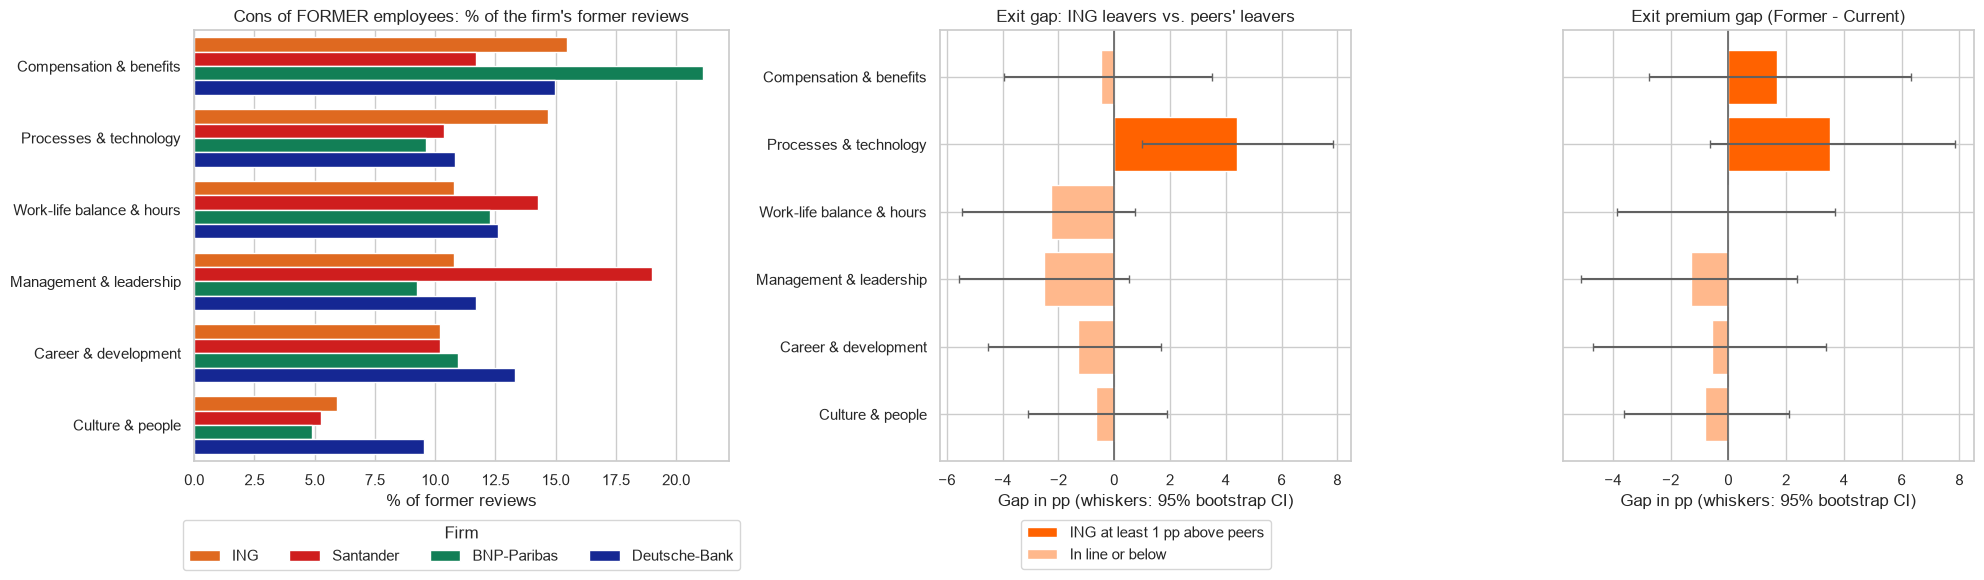

In [66]:
# Left: leavers' complaints by firm. Center and right: both gaps with 95% CI
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.3, 1, 1]})

plot_df = (f_cons.loc[FIRMS, exit_tbl.index].rename_axis(columns=None).reset_index()
           .melt(id_vars="firm", var_name="Category", value_name="Share"))
sns.barplot(data=plot_df, x="Share", y="Category", hue="firm", order=exit_tbl.index.tolist(),
            hue_order=FIRMS, palette=PALETTE, ax=axes[0])
axes[0].set_title("Cons of FORMER employees: % of the firm's former reviews")
axes[0].set_xlabel("% of former reviews")
axes[0].set_ylabel("")
axes[0].legend(title="Firm", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=4)

for ax, gap_col, lo, hi, title in [(axes[1], "Exit gap (pp)", "exit_lo", "exit_hi", "Exit gap: ING leavers vs. peers' leavers"),
                                   (axes[2], "Premium gap (pp)", "prem_lo", "prem_hi", "Exit premium gap (Former - Current)")]:
    g = exit_tbl[gap_col]
    # Dark = ING at least 1 pp above peers
    colors = [PALETTE[TARGET] if v >= MATERIAL_PP else lighten(PALETTE[TARGET], 0.55) for v in g]
    ax.barh(g.index, g.values, color=colors,
            xerr=[(g - exit_tbl[lo]).values, (exit_tbl[hi] - g).values], error_kw={"ecolor": "#616161", "capsize": 3})
    ax.axvline(0, color="#616161", linewidth=1.2)
    ax.set_title(title)
    ax.set_xlabel("Gap in pp (whiskers: 95% bootstrap CI)")
    if ax is axes[2]:
        ax.set_yticklabels([])
    ax.invert_yaxis()

axes[1].legend(handles=[Patch(facecolor=PALETTE[TARGET], label="ING at least 1 pp above peers"),
                        Patch(facecolor=lighten(PALETTE[TARGET], 0.55), label="In line or below")],
               loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1)
plt.tight_layout()
plt.show()

In [67]:
# Text reading built from exit_tbl
def exit_sentence(cat, r):
    return (f"*{cat}* ({r['ING former %']:.1f}% of ING leavers' cons vs. {r['Peers former %']:.1f}% in peers; "
            f"exit gap {r['Exit gap (pp)']:+.1f} pp, premium gap {r['Premium gap (pp)']:+.1f} pp; {r['Evidence'].lower()})")

top_ing = exit_tbl["ING former %"].idxmax()
parts = [f"**Reading.** The most frequent category among ING's leavers is *{top_ing}* ({exit_tbl.loc[top_ing, 'ING former %']:.1f}% of their reviews)."]
for sig, text in [("Retention risk", "Above the peers on both measures (retention risk)"),
                  ("Watch", "Above the peers on one measure only (watch)")]:
    sub = exit_tbl[exit_tbl["Signal"] == sig]
    parts.append(f"{text}: " + ("; ".join(exit_sentence(c, r) for c, r in sub.iterrows()) + "." if len(sub) else "none."))
parts.append("In line with or below the peers on both measures: " + (", ".join(f"*{c}*" for c in exit_tbl.index[exit_tbl["Signal"] == "In line or below"]) or "none") + ".")
display(Markdown("\n\n".join(parts)))

**Reading.** The most frequent category among ING's leavers is *Compensation & benefits* (15.5% of their reviews).

Above the peers on both measures (retention risk): *Processes & technology* (14.7% of ING leavers' cons vs. 10.3% in peers; exit gap +4.4 pp, premium gap +3.5 pp; interval excludes 0).

Above the peers on one measure only (watch): *Compensation & benefits* (15.5% of ING leavers' cons vs. 15.9% in peers; exit gap -0.5 pp, premium gap +1.7 pp; indicative).

In line with or below the peers on both measures: *Work-life balance & hours*, *Management & leadership*, *Career & development*, *Culture & people*.

**Sanity check on empty answers.** If ING's former employees left many more or fewer empty answers than the peers' former employees, the shares above would be diluted differently. Below I show the weight of *No content* and *Mixed / generic* among each firm's leavers (also in 5.1) and repeat the signals using only identified complaints.

In [68]:
# Robustness: same two gaps without empty or generic reviews
cons_tab_id = shares_by_status("cat_cons", identified_only=True)
f_id, c_id = group_shares(cons_tab_id, "Former")[COMPARABLE], group_shares(cons_tab_id, "Current")[COMPARABLE]
robust = pd.DataFrame({
    "Exit gap (pp) - base": exit_tbl["Exit gap (pp)"],
    "Exit gap (pp) - identified only": gap_vs_peers(f_id),
    "Premium gap (pp) - base": exit_tbl["Premium gap (pp)"],
    "Premium gap (pp) - identified only": gap_vs_peers(f_id - c_id),
}).loc[exit_tbl.index]
robust["Same signs"] = (np.sign(robust.iloc[:, 0]) == np.sign(robust.iloc[:, 1])) & (np.sign(robust.iloc[:, 2]) == np.sign(robust.iloc[:, 3]))

print("Weight of empty / generic cons among leavers (%)")
display(profile.xs("Former", level="status")[["pct_cons_no_content", "pct_cons_mixed"]].reindex(FIRMS))
print("Robustness of the exit signals")
display(robust.round(1))

unstable = robust.index[~robust["Same signs"]].tolist()
display(Markdown("**Reading.** " + (f"The sign of at least one gap changes when only identified complaints are used in: {', '.join('*' + c + '*' for c in unstable)}. "
                                    "Those categories depend on how empty answers are treated and should be read with extra care."
                                    if unstable else "No sign changes when only identified complaints are used: the exit signals do not depend on how empty answers are treated.")))

Weight of empty / generic cons among leavers (%)


,pct_cons_no_content,pct_cons_mixed
firm,,
ING,13.2,15.7
Santander,10.5,17.1
BNP-Paribas,12.3,11.3
Deutsche-Bank,10.8,15.7


Robustness of the exit signals


,Exit gap (pp) - base,Exit gap (pp) - identified only,Premium gap (pp) - base,Premium gap (pp) - identified only,Same signs
Compensation & benefits,-0.5,0.1,1.7,1.4,False
Processes & technology,4.4,7.1,3.5,4.1,True
Work-life balance & hours,-2.3,-2.6,-0.0,-0.6,True
Management & leadership,-2.5,-2.9,-1.3,-2.2,True
Career & development,-1.3,-1.2,-0.6,-1.6,True
Culture & people,-0.7,-0.5,-0.8,-1.2,True


**Reading.** The sign of at least one gap changes when only identified complaints are used in: *Compensation & benefits*. Those categories depend on how empty answers are treated and should be read with extra care.

**Robustness to outlier reassignment.** Section 3 showed that the grouping is most sensitive to reassigning outliers (*Processes & technology* went from +2.2 to +0.4 pp without it), and that category stands out among leavers. So I repeat both gaps with the **direct BERTopic assignments only**; reviews left as outliers fall into *Mixed / generic*, which stays in the denominator.

In [69]:
# Same gaps using only direct BERTopic assignments (no outlier reassignment)
emp_df["cat_cons_raw"] = emp_df["topic_cons"].map(topic_to_category(CONS_GROUPS))

raw_tab = shares_by_status("cat_cons_raw")
f_raw, c_raw = group_shares(raw_tab, "Former")[COMPARABLE], group_shares(raw_tab, "Current")[COMPARABLE]

raw_check = pd.DataFrame({
    "Exit gap (pp) - base":              exit_tbl["Exit gap (pp)"],
    "Exit gap (pp) - direct topics":     gap_vs_peers(f_raw),
    "Premium gap (pp) - base":           exit_tbl["Premium gap (pp)"],
    "Premium gap (pp) - direct topics":  gap_vs_peers(f_raw - c_raw),
}).loc[exit_tbl.index]
raw_check["Same signs"] = (np.sign(raw_check.iloc[:, 0]) == np.sign(raw_check.iloc[:, 1])) & (np.sign(raw_check.iloc[:, 2]) == np.sign(raw_check.iloc[:, 3]))
display(raw_check.round(1))

# Does each flagged category keep its gap above 1 pp without reassignment?
flagged = exit_tbl.index[exit_tbl["Signal"] != "In line or below"]
parts = []
for cat in flagged:
    base, raw = raw_check.loc[cat, "Exit gap (pp) - base"], raw_check.loc[cat, "Exit gap (pp) - direct topics"]
    verdict = "holds" if raw >= MATERIAL_PP else "does not hold"
    parts.append(f"*{cat}*: exit gap {raw:+.1f} pp with direct topics vs. {base:+.1f} pp with reassignment, so the signal **{verdict}** without reassignment")
display(Markdown("**Reading.** " + ("; ".join(parts) + "." if parts else "No category is flagged, so there is nothing to confirm.")))


,Exit gap (pp) - base,Exit gap (pp) - direct topics,Premium gap (pp) - base,Premium gap (pp) - direct topics,Same signs
Compensation & benefits,-0.5,0.5,1.7,3.1,False
Processes & technology,4.4,1.6,3.5,2.0,True
Work-life balance & hours,-2.3,-2.6,-0.0,0.8,False
Management & leadership,-2.5,-0.3,-1.3,-0.5,True
Career & development,-1.3,-0.1,-0.6,0.0,False
Culture & people,-0.7,0.1,-0.8,0.3,False


**Reading.** *Compensation & benefits*: exit gap +0.5 pp with direct topics vs. -0.5 pp with reassignment, so the signal **does not hold** without reassignment; *Processes & technology*: exit gap +1.6 pp with direct topics vs. +4.4 pp with reassignment, so the signal **holds** without reassignment.

### 5.5. Do leavers' complaints really hurt? Cross-check with rating and recommendation

Same logic as 4.3, now only for **former employees**: if a category is a real reason for leaving, former employees who complain about it should rate ING and recommend it less than the average former employee of the firm. The baseline is the firm's own former-employee mean (so the lower level of leavers, 1.4, doesn't distort the comparison) and `Peers` shows whether the penalty is specific to ING or typical of any firm. `±` is the 95% half-width and `n` is shown because many cells rest on few reviews.

In [70]:
former_df = emp_df[emp_df["status"] == "Former"]

# Baseline: mean of each firm's former employees
former_base = former_df.groupby("firm", observed=True).agg(
    firm_mean_rating=("overall_rating", "mean"),
    firm_recommend_rate=("recommends", recommendation_rate),
).reindex(FIRMS)

former_check = (
    former_df[former_df["cat_cons"].isin(COMPARABLE)]
    .groupby(["firm", "cat_cons"], observed=True)
    .agg(n_reviews=("overall_rating", "size"),
         n_with_opinion=("recommends", n_opinions),
         mean_rating=("overall_rating", "mean"),
         rating_ci=("overall_rating", ci95_mean),
         recommend_rate=("recommends", recommendation_rate),
         recommend_ci=("recommends", ci95_rate))
    .join(former_base, on="firm")
)
former_check["rating_gap"] = former_check["mean_rating"] - former_check["firm_mean_rating"]
former_check["recommend_gap"] = former_check["recommend_rate"] - former_check["firm_recommend_rate"]

ing_f = former_check.xs(TARGET, level="firm")
peers_f = former_check[former_check.index.get_level_values("firm").isin(PEERS)].groupby(level="cat_cons")[["rating_gap", "recommend_gap"]].mean()

former_cross = pd.DataFrame({
    "Signal": exit_tbl["Signal"],
    "Complaints (n)": ing_f["n_reviews"],
    "With opinion (n)": ing_f["n_with_opinion"],
    "ING rating gap": ing_f["rating_gap"],
    "± (rating)": ing_f["rating_ci"],
    "Peers rating gap": peers_f["rating_gap"],
    "ING recommend gap (pp)": ing_f["recommend_gap"],
    "± (recommend, pp)": ing_f["recommend_ci"],
    "Peers recommend gap (pp)": peers_f["recommend_gap"],
}).loc[exit_tbl.index].round(2)

print(f"ING former employees: baseline rating {former_base.loc[TARGET, 'firm_mean_rating']:.2f}, "
      f"recommendation {former_base.loc[TARGET, 'firm_recommend_rate']:.1f}%")
display(former_cross)

# Penalty is "clear" only if the interval excludes zero
clear = former_cross[(former_cross["ING rating gap"] + former_cross["± (rating)"] < 0)]
weak = former_cross[former_cross["Complaints (n)"] < 30]
text = "**Reading.** "
text += ("Categories whose leavers rate ING clearly below the average ING leaver (interval excludes zero): " +
         ", ".join(f"*{c}* ({r['ING rating gap']:+.2f} points, n={int(r['Complaints (n)'])})" for c, r in clear.iterrows()) + ". "
         if len(clear) else "No category shows a rating penalty whose interval excludes zero among ING leavers. ")
if len(weak):
    text += "Rest on fewer than 30 reviews (indicative only): " + ", ".join(f"*{c}*" for c in weak.index) + "."
display(Markdown(text))

ING former employees: baseline rating 3.84, recommendation 74.7%


,Signal,Complaints (n),With opinion (n),ING rating gap,± (rating),Peers rating gap,ING recommend gap (pp),"± (recommend, pp)",Peers recommend gap (pp)
Compensation & benefits,Watch,76,31,-0.15,0.25,-0.05,-3.74,15.98,-1.06
Processes & technology,Retention risk,72,35,-0.02,0.21,0.08,2.44,13.91,-0.29
Work-life balance & hours,In line or below,53,29,0.13,0.24,0.15,1.16,15.57,6.37
Management & leadership,In line or below,53,30,-0.55,0.35,-0.49,-28.04,17.85,-19.07
Career & development,In line or below,50,29,0.18,0.23,-0.06,8.06,13.75,2.42
Culture & people,In line or below,29,15,-0.22,0.45,-0.65,-8.04,23.86,-19.58


**Reading.** Categories whose leavers rate ING clearly below the average ING leaver (interval excludes zero): *Management & leadership* (-0.55 points, n=53). Rest on fewer than 30 reviews (indicative only): *Culture & people*.

### 5.6. Retention priority matrix

Same idea as the priority matrix for the whole company (6.1), but with **leavers only**: the horizontal axis is the weight of each category in ING leavers' complaints and the vertical axis is the exit gap versus the peers' leavers. As the brief says, a problem is only a priority if ING is worse than the market, so only the upper-right quadrant counts. The dashed vertical line is the average weight of the six categories.

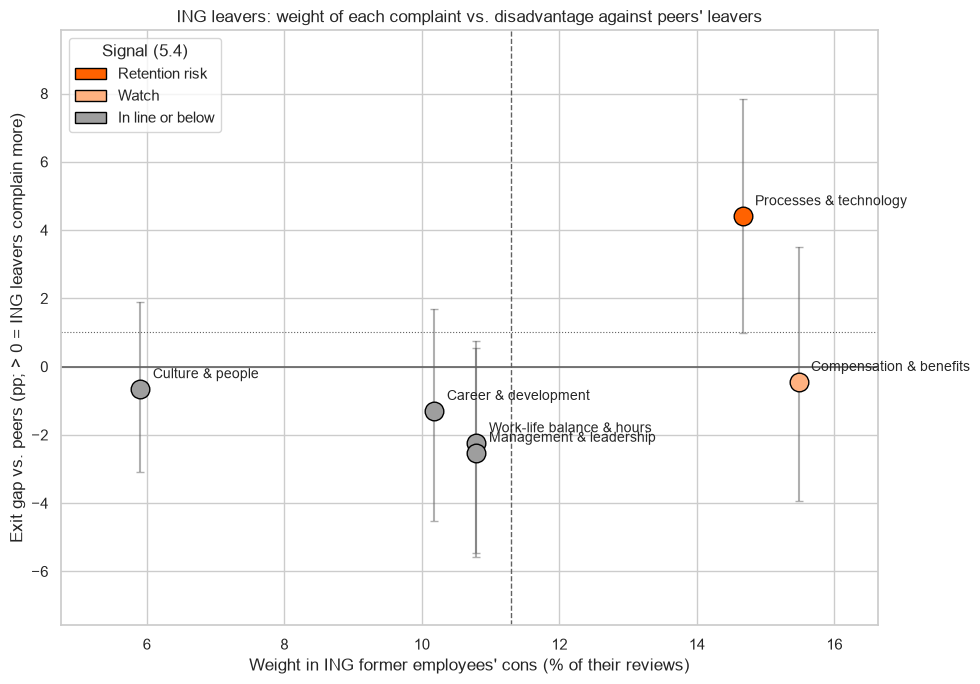

**Reading.** Upper-right quadrant (frequent among ING leavers **and** worse than the peers): *Processes & technology*. Points with an interval that crosses zero cannot be separated from the peers with this sample.

In [71]:
# Weight vs. exit gap, colored by the signal of 5.4
fig, ax = plt.subplots(figsize=(10, 7))

signal_colors = {"Retention risk": PALETTE[TARGET], "Watch": lighten(PALETTE[TARGET], 0.5), "In line or below": "#9E9E9E"}
for cat, r in exit_tbl.iterrows():
    ax.scatter(r["ING former %"], r["Exit gap (pp)"], s=180, color=signal_colors[r["Signal"]], edgecolor="black", zorder=3)
    ax.errorbar(r["ING former %"], r["Exit gap (pp)"], yerr=[[r["Exit gap (pp)"] - r["exit_lo"]], [r["exit_hi"] - r["Exit gap (pp)"]]],
                color="#616161", alpha=0.5, capsize=3, zorder=2)
    ax.annotate(cat, (r["ING former %"], r["Exit gap (pp)"]), textcoords="offset points", xytext=(9, 8), fontsize=10)

ax.axhline(0, color="#616161", linewidth=1.2)
ax.axhline(MATERIAL_PP, color="#616161", linewidth=0.8, linestyle=":")   # 1 pp threshold
ax.axvline(exit_tbl["ING former %"].mean(), color="#616161", linewidth=1, linestyle="--")
ax.set_title("ING leavers: weight of each complaint vs. disadvantage against peers' leavers")
ax.set_xlabel("Weight in ING former employees' cons (% of their reviews)")
ax.set_ylabel("Exit gap vs. peers (pp; > 0 = ING leavers complain more)")
ax.legend(handles=[Patch(facecolor=c, edgecolor="black", label=s) for s, c in signal_colors.items()], title="Signal (5.4)", loc="upper left")
ax.margins(x=0.12, y=0.15)

plt.tight_layout()
plt.show()

priority = exit_tbl[(exit_tbl["Exit gap (pp)"] >= MATERIAL_PP) & (exit_tbl["ING former %"] >= exit_tbl["ING former %"].mean())]
display(Markdown("**Reading.** Upper-right quadrant (frequent among ING leavers **and** worse than the peers): " +
                 (", ".join(f"*{c}*" for c in priority.index) if len(priority) else "no category") +
                 ". Points with an interval that crosses zero cannot be separated from the peers with this sample."))

### 5.7. What do ING's leavers say, in their own words?

Random sample (fixed seed) of former-employee cons in the three most frequent categories, to check the numbers against real text. They are not hand-picked, so for the presentation it is worth choosing the clearest ones.

In [72]:
# 4 random cons per category
ing_former_cons = former_df[(former_df["firm"] == TARGET)]
for cat in exit_tbl.index[:3]:
    sub = ing_former_cons[ing_former_cons["cat_cons"] == cat]
    print(f"\n[{cat}] ({len(sub)} ING former reviews)")
    for text in sub["cons"].sample(min(4, len(sub)), random_state=SEED).str[:220]:
        print("  -", text)


[Compensation & benefits] (76 ING former reviews)
  - There is not any minpunten
  - Insufficient wages and employee benefits
  - Salary increase could be higher per year
  - Relaxed work environment and company culture was used as a guise to justify the poor pay. (well the pay is bad, on par with communist countries but at least it's a dEcEnT pLaCe tO wOrk!) Statistically, this place has a H

[Processes & technology] (72 ING former reviews)
  - a lot of bureaucracy with too many layers to go through to get something done.
  - Delegation of work is normal. If you are at the bottom of hierarchy you will burnout.
  - Regulatory compliance and faced pace of working can suppress innovation
  - The company operates very slow. Hard to get new process to move. Internal monitoring system is mad, take you time and hardly it bring any valid data to management

[Work-life balance & hours] (53 ING former reviews)
  - Things work very slow sometimes
  - With the huge responsibility, hours can be l

**Reading the sample.** *Compensation* reads as expected (low pay and raises). *Processes & technology* is coherent: bureaucracy and layers, slow processes, compliance that slows innovation. *Work-life balance & hours* is the noisy one: only one of the four reviews is about hours (the others are about slowness, colleagues' attitude and uncomfortable situations), which matches the limit on topic precision (section 3) and means that category must be read with more caution than the other two.

### 5.8. Extra: do the reasons for leaving change with tenure?

Tenure of former employees says *when* they left. I group it in three bands because ING has few leavers: **up to 3 years** (`-1`, `+1`), **3-8 years** (`+3`, `+5`) and **8+ years** (`+8`, `+10`). Reviews with unknown tenure (`N/A`) are left out. The peers are pooled (reviews put together) instead of averaged firm by firm, because firm-by-band groups would be too small. Both panels share the color scale so cells are comparable.

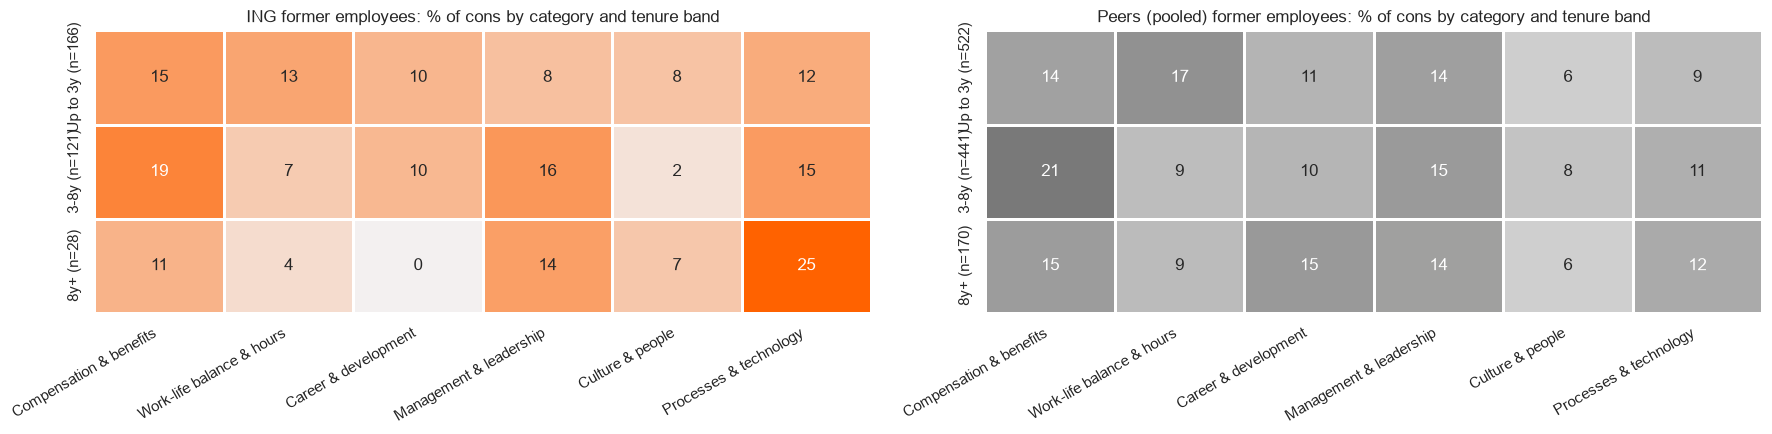

**Reading.**

- **Up to 3y** (n=166): top ING category *Compensation & benefits* (15%); largest excess over the pooled peers: *Processes & technology* (+2.9 pp)
- **3-8y** (n=121): top ING category *Compensation & benefits* (19%); largest excess over the pooled peers: *Processes & technology* (+3.5 pp)
- **8y+** (n=28): top ING category *Processes & technology* (25%); largest excess over the pooled peers: *Processes & technology* (+12.6 pp)

Bands with fewer than ~50 reviews are indicative only.

In [73]:
# Three bands, groups are small
BANDS = ["Up to 3y", "3-8y", "8y+"]
TENURE_BAND = {"-1": "Up to 3y", "+1": "Up to 3y", "+3": "3-8y", "+5": "3-8y", "+8": "8y+", "+10": "8y+"}

tenure_df = former_df.assign(band=former_df["tenure"].astype(str).map(TENURE_BAND)).dropna(subset=["band"])

def band_shares(df):
    # Category shares per tenure band
    tab = pd.crosstab(df["band"], df["cat_cons"], normalize="index").mul(100).reindex(index=BANDS)
    return tab.reindex(columns=COMPARABLE, fill_value=0), df["band"].value_counts().reindex(BANDS).fillna(0).astype(int)

ing_band, ing_band_n = band_shares(tenure_df[tenure_df["firm"] == TARGET])
peer_band, peer_band_n = band_shares(tenure_df[tenure_df["firm"].isin(PEERS)])

# Same color scale in both panels
vmax = max(ing_band.max().max(), peer_band.max().max())
fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
for ax, tab, n, cmap, title in [(axes[0], ing_band, ing_band_n, sns.light_palette(PALETTE[TARGET], as_cmap=True), f"{TARGET} former employees"),
                                (axes[1], peer_band, peer_band_n, sns.light_palette("#616161", as_cmap=True), "Peers (pooled) former employees")]:
    sns.heatmap(tab.rename(index=lambda b: f"{b} (n={n[b]})"), annot=True, fmt=".0f", cmap=cmap, vmin=0, vmax=vmax,
                cbar=False, linewidths=1, linecolor="white", ax=ax)
    ax.set_title(f"{title}: % of cons by category and tenure band")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout()
plt.show()

lines = []
for band in BANDS:
    if ing_band_n[band] == 0:
        continue
    top = ing_band.loc[band].idxmax()
    diff = (ing_band.loc[band] - peer_band.loc[band]).idxmax()
    lines.append(f"- **{band}** (n={ing_band_n[band]}): top ING category *{top}* ({ing_band.loc[band, top]:.0f}%); "
                 f"largest excess over the pooled peers: *{diff}* ({(ing_band.loc[band] - peer_band.loc[band])[diff]:+.1f} pp)")
display(Markdown("**Reading.**\n\n" + "\n".join(lines) + "\n\nBands with fewer than ~50 reviews are indicative only."))

### 5.9. Extra: before and after 2020

Did the reasons for leaving change with the pandemic? I split former-employee cons into **2018-2019** and **2020-2023** (2018 and 2023 are incomplete years, see 1.3) and compare ING with the pooled peers, again to keep groups large enough. The change is *after minus before*, in pp of the group's own reviews.

Former reviews: ING {'2018-19': np.int64(61), '2020-23': np.int64(430)} | peers pooled {'2018-19': np.int64(315), '2020-23': np.int64(1359)}


,ING 2018-19 %,ING 2020-23 %,ING change (pp),Peers 2018-19 %,Peers 2020-23 %,Peers change (pp),ING vs. peers change (pp)
cat_cons,,,,,,,
Compensation & benefits,11.5,16.0,4.6,17.1,15.5,-1.7,6.3
Career & development,4.9,10.9,6.0,11.1,11.6,0.4,5.6
Processes & technology,14.8,14.7,-0.1,9.8,10.4,0.5,-0.6
Culture & people,11.5,5.1,-6.4,7.3,6.4,-0.9,-5.5
Work-life balance & hours,13.1,10.5,-2.6,10.5,13.7,3.2,-5.9
Management & leadership,16.4,10.0,-6.4,13.7,13.5,-0.2,-6.2


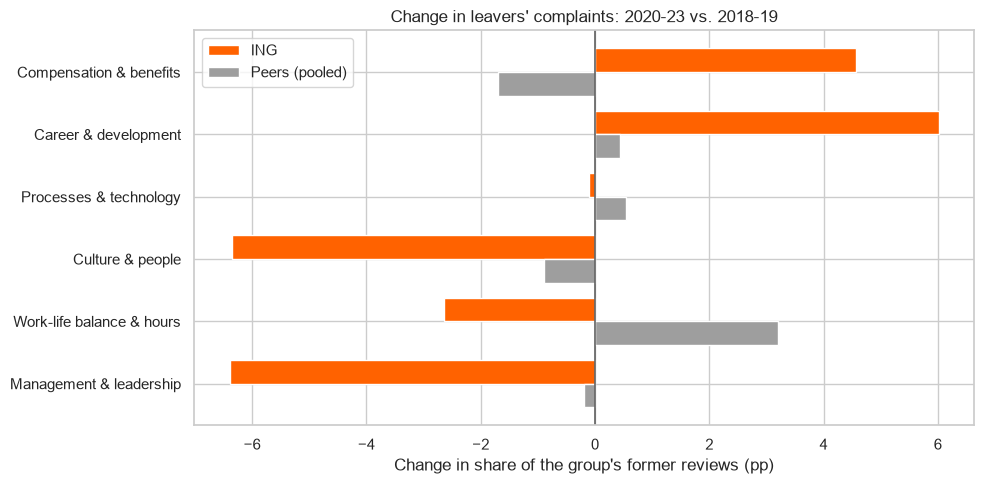

**Reading.** Relative to the peers' trend, ING's leavers mention *Compensation & benefits* more after 2020 (+6.3 pp) and *Management & leadership* less (-6.2 pp). With only 61 ING leaver reviews before 2020, changes of a few points are indicative, not conclusive.

In [74]:
# Before / after 2020
period_df = former_df.assign(period=np.where(former_df["year"] < 2020, "2018-19", "2020-23"))

def period_shares(df):
    tab = pd.crosstab(df["period"], df["cat_cons"], normalize="index").mul(100).reindex(index=["2018-19", "2020-23"])
    return tab.reindex(columns=COMPARABLE, fill_value=0), df["period"].value_counts().reindex(["2018-19", "2020-23"]).fillna(0).astype(int)

ing_per, ing_per_n = period_shares(period_df[period_df["firm"] == TARGET])
peer_per, peer_per_n = period_shares(period_df[period_df["firm"].isin(PEERS)])

period_tbl = pd.DataFrame({
    "ING 2018-19 %": ing_per.loc["2018-19"], "ING 2020-23 %": ing_per.loc["2020-23"],
    "ING change (pp)": ing_per.loc["2020-23"] - ing_per.loc["2018-19"],
    "Peers 2018-19 %": peer_per.loc["2018-19"], "Peers 2020-23 %": peer_per.loc["2020-23"],
    "Peers change (pp)": peer_per.loc["2020-23"] - peer_per.loc["2018-19"],
})
period_tbl["ING vs. peers change (pp)"] = period_tbl["ING change (pp)"] - period_tbl["Peers change (pp)"]
period_tbl = period_tbl.sort_values("ING vs. peers change (pp)", ascending=False)

print(f"Former reviews: ING {dict(ing_per_n)} | peers pooled {dict(peer_per_n)}")
display(period_tbl.round(1))

fig, ax = plt.subplots(figsize=(10, 5))
y, h = np.arange(len(period_tbl)), 0.38
ax.barh(y - h / 2, period_tbl["ING change (pp)"], h, color=PALETTE[TARGET], label=TARGET)
ax.barh(y + h / 2, period_tbl["Peers change (pp)"], h, color="#9E9E9E", label="Peers (pooled)")
ax.axvline(0, color="#616161", linewidth=1.2)
ax.set_yticks(y)
ax.set_yticklabels(period_tbl.index)
ax.invert_yaxis()
ax.set_title("Change in leavers' complaints: 2020-23 vs. 2018-19")
ax.set_xlabel("Change in share of the group's former reviews (pp)")
ax.legend()
plt.tight_layout()
plt.show()

up, down = period_tbl["ING vs. peers change (pp)"].idxmax(), period_tbl["ING vs. peers change (pp)"].idxmin()
display(Markdown(f"**Reading.** Relative to the peers' trend, ING's leavers mention *{up}* more after 2020 "
                 f"({period_tbl.loc[up, 'ING vs. peers change (pp)']:+.1f} pp) and *{down}* less "
                 f"({period_tbl.loc[down, 'ING vs. peers change (pp)']:+.1f} pp). "
                 f"With only {ing_per_n['2018-19']} ING leaver reviews before 2020, changes of a few points are indicative, not conclusive."))

### 5.10. Section 5 conclusions

The table gathers, for each category, the evidence of 5.4 (signal and strength) and 5.5 (rating penalty among ING leavers). The text after it reads those numbers and closes the questions left open in section 4.

In [75]:
# Evidence of 5.4 and 5.5 in one table
final_tbl = exit_tbl[["ING former %", "Peers former %", "Exit gap (pp)", "Premium gap (pp)", "Signal", "Evidence"]].join(
    former_cross[["Complaints (n)", "ING rating gap", "± (rating)"]])
# Clear = interval excludes 0, Possible = at least -0.10 points
final_tbl["Rating penalty"] = np.where(final_tbl["ING rating gap"] + final_tbl["± (rating)"] < 0, "Clear",
                                       np.where(final_tbl["ING rating gap"] <= -MIN_PENALTY, "Possible", "None"))

print("Retention evidence by category (ING leavers)")
display(final_tbl.round(2))


Retention evidence by category (ING leavers)


,ING former %,Peers former %,Exit gap (pp),Premium gap (pp),Signal,Evidence,Complaints (n),ING rating gap,± (rating),Rating penalty
Compensation & benefits,15.48,15.93,-0.46,1.68,Watch,Indicative,76,-0.15,0.25,Possible
Processes & technology,14.66,10.26,4.40,3.54,Retention risk,Interval excludes 0,72,-0.02,0.21,None
Work-life balance & hours,10.79,13.05,-2.25,-0.05,In line or below,Indicative,53,0.13,0.24,None
Management & leadership,10.79,13.32,-2.53,-1.31,In line or below,Indicative,53,-0.55,0.35,Clear
Career & development,10.18,11.49,-1.30,-0.58,In line or below,Indicative,50,0.18,0.23,None
Culture & people,5.91,6.57,-0.67,-0.82,In line or below,Indicative,29,-0.22,0.45,Possible


**What former employees add to the story**

1. **Leavers are not an alarm signal.** ING's former employees rate it 3.84 on average and 74.7% of those with an opinion recommend it: as high as the peers' *current* employees (3.77-3.84) and far above the peers' leavers (3.27-3.52 and 49.5%-62.4% recommend). Moreover, no theme changes significantly between ING's current and former employees (5.3): ING does not have a complaint that only appears once people leave.
2. **Management & leadership: costly everywhere, not an ING problem.** It is the category with the biggest rating penalty among ING leavers (-0.55 points, -28 pp in recommendation), but the peers show the same penalty (-0.49 points, -19 pp), and ING leavers mention it *less* than the peers' leavers do (10.8% vs. 13.3%; 19.0% in Santander). It answers the question left by section 4: bad management hurts wherever it appears, and ING suffers it less often.
3. **Processes & technology is the only theme where ING leavers complain more than the market.** 14.7% of their cons vs. 10.3% in the peers (+4.4 pp, interval +1.0 to +7.8; +7.1 pp counting only identified complaints). Quotes point to bureaucracy, layers and slow decisions. Two nuances: it does not separate ING leavers from stayers (premium of -0.4 pp: those who stay complain as much as those who leave) and those who complain do not rate ING lower (-0.02 points), so it is a **chronic friction** more than a trigger for leaving. It is also structural, not a pandemic effect (14.8% before 2020, 14.7% after), and it is strongest among long-tenure leavers (25% for 8+ years, +12.6 pp vs. the peers, but only 28 reviews). Without outlier reassignment (the weak point that section 3 identified for this category) the exit gap shrinks to +1.6 pp (5.4): still above the 1 pp threshold but much weaker, so it is a signal to confirm and not a measured size.
4. **Compensation & benefits is the leading reason in ING leavers' cons (15.5%) but equal to the market (15.9%).** The pay problem is BNP-Paribas's (21.1%); ING's "watch" label is weak (its interval crosses zero and the sign flips when only identified complaints are used). The post-2020 rise in ING (+6.3 pp vs. the peers' trend) rests on 61 reviews before 2020 and is only worth monitoring.
5. **Work-life balance, career and culture complaints are in line with or below the peers' leavers** (-2.3, -1.3 and -0.7 pp). Consistent with the strengths found in section 4, although none of these intervals excludes zero. Among ING leavers, praise for work-life balance (-3.6 pp) and compensation (-3.1 pp) is lower than among current employees, but not significantly.

**How firm is all this?** Only one interval excludes zero (the *Processes & technology* exit gap); everything else is directional, which is what groups of 491 (ING) and 1,674 (the three peers) former-employee reviews allow. The findings are useful to decide *where to look* (exit interviews, internal surveys on process friction), not as proof.

**Limitations of this section.**

- **Small groups.** ING has 491 former-employee reviews (vs. 1,009 current) and each peer 530-589, so many differences have intervals that include zero. The section prioritises by consistency (several measures pointing the same way) instead of by single numbers.
- **Cons are not exit interviews.** A complaint written by a former employee is a *reported* reason for leaving, not a verified one; people often describe the whole experience and not only the trigger. It is also written for a public audience.
- **Selection.** Who writes on Glassdoor after leaving is not random (1.4), and the two groups may also differ in tenure and in the share of empty answers, which is why topics (not ratings) are compared and why the identified-only robustness check is reported.
- **One category per review.** Multi-theme reviews are assigned to a single category and a large share of reviews stays in *Mixed / generic* (28% of pros and 15% of cons in the whole sample, section 3), so the real weight of each theme is probably underestimated. Pros of *Career* and *Management* are under-captured (section 3), so their praise is not read in absolute terms.
- **Mixed countries and areas.** The peers and ING operate in different markets, and Deutsche-Bank has a stronger investment-banking component (introduction), so some differences may reflect the business mix and not HR policy.
- **Multiple comparisons.** Even with the correction, six categories are tested several times across the section, so isolated "significant" results should be confirmed in the data of future periods.

## 6. Prioritisation Matrix and Extra Analyses

This section closes the brief: where HR should act first (6.1, whole company) and two extra cuts that complement section 5: how the main categories moved before and after 2020 (6.2) and how they relate to recommending the firm (6.3). Section 7 has the conclusions.

### 6.1. Prioritisation matrix

Same logic as the retention matrix of 5.6, but with **all** of ING's cons (current and former). As the brief says, a problem is a priority only if ING is *worse than the market*. Each category is placed by:

- **Weight** (horizontal): % of ING's reviews whose main complaint is that category (all reviews in the base, as in section 4). The dashed line is the average of the six categories.
- **Disadvantage versus the peers** (vertical, in pp; above 0 = ING worse). I show two views because they answer different questions: the **net balance** (left; the one the brief asks for, as it corrects for the relative nature of percentages) and the **complaints only** (right; what the cons say on their own).

Rules: **Priority** = net-balance disadvantage of at least 1 pp (`MATERIAL_PP`) *and* weight above the average; **Watch** = disadvantage of at least 1 pp in either view but not a priority; **Not a priority** otherwise. The rating gap of those who complain (4.3) is added as evidence of damage, but it is not part of the rule. *Language & HQ location* is left out because it is firm-specific (section 3).

,Weight in ING cons (%),Disadvantage: net balance (pp),Disadvantage: complaints only (pp),Rating gap of complainers,± (rating),Signal,Rating penalty
Compensation & benefits,15.93,0.49,-1.50,-0.07,0.12,Not a priority,None
Processes & technology,14.93,-1.07,2.19,-0.05,0.12,Watch,None
Career & development,11.47,0.31,-0.83,-0.03,0.13,Not a priority,None
Work-life balance & hours,10.00,-3.62,-2.25,0.08,0.14,Not a priority,None
Management & leadership,9.33,-1.18,-1.83,-0.68,0.21,Not a priority,Clear
Culture & people,4.40,-4.24,-0.27,-0.34,0.27,Not a priority,Clear


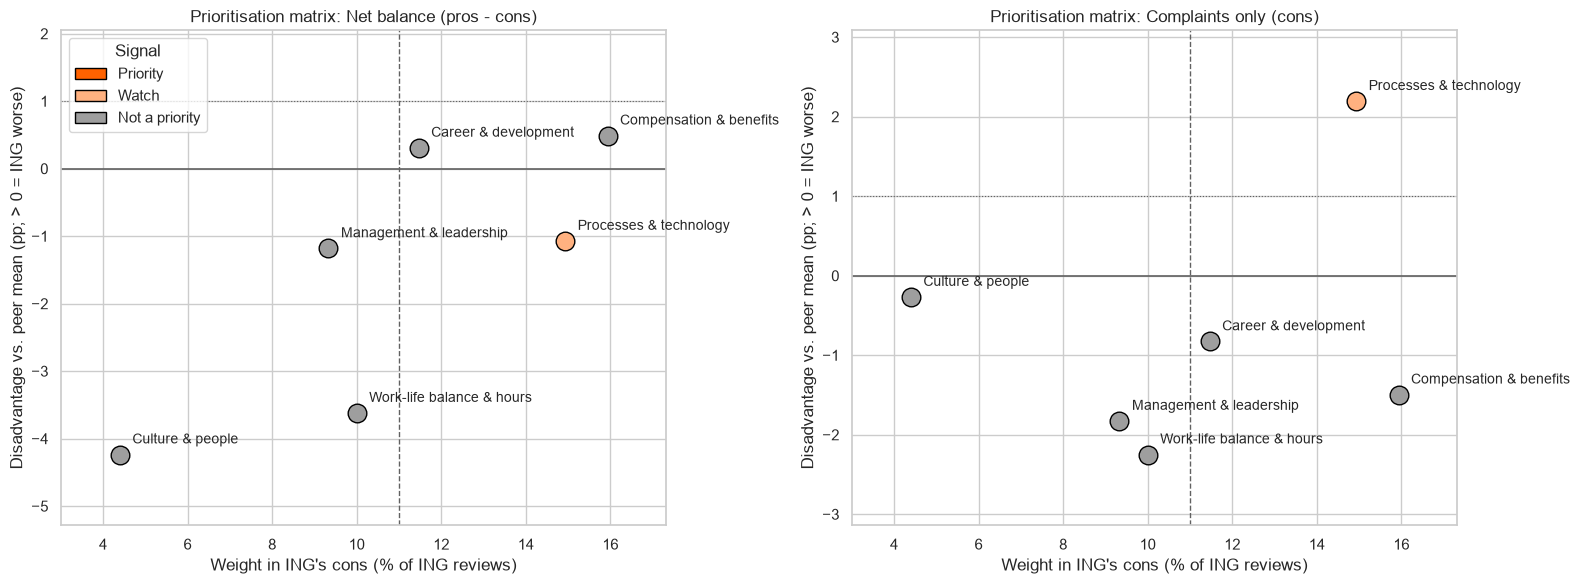

**Reading.** No category is a priority: none combines a net disadvantage of at least 1 pp with above-average weight. Watch (worse than the peers in at least one view): *Processes & technology*. *Management & leadership*, *Culture & people* clearly lower the rating of those who complain, but ING is not worse than its peers there (the `Peers` columns of 4.3 show whether the penalty is common to every firm).

In [76]:
# One row per comparable category: weight, disadvantage in both views and rating evidence
matrix = pd.DataFrame({
    "Weight in ING cons (%)":             cons_shares.loc[TARGET, COMPARABLE],
    "Disadvantage: net balance (pp)":     -net_comparison["Net gap vs peers (pp)"],     # > 0: ING worse balanced than the peers
    "Disadvantage: complaints only (pp)": net_comparison["Cons gap (pp)"],              # > 0: ING receives more complaints
    "Rating gap of complainers":          cross_check["ING rating gap"],
    "± (rating)":                         cross_check["± (rating)"],
}).reindex(COMPARABLE)

avg_weight = matrix["Weight in ING cons (%)"].mean()

# Priority = net disadvantage >= 1 pp and above-average weight
def matrix_signal(r):
    worse_net = r["Disadvantage: net balance (pp)"] >= MATERIAL_PP
    worse_cons = r["Disadvantage: complaints only (pp)"] >= MATERIAL_PP
    if worse_net and r["Weight in ING cons (%)"] >= avg_weight:
        return "Priority"
    return "Watch" if (worse_net or worse_cons) else "Not a priority"

matrix["Signal"] = matrix.apply(matrix_signal, axis=1)
matrix["Rating penalty"] = np.where(matrix["Rating gap of complainers"] + matrix["± (rating)"] < 0, "Clear",
                                    np.where(matrix["Rating gap of complainers"] <= -MIN_PENALTY, "Possible", "None"))
display(matrix.sort_values("Weight in ING cons (%)", ascending=False).round(2))

signal_colors = {"Priority": PALETTE[TARGET], "Watch": lighten(PALETTE[TARGET], 0.5), "Not a priority": "#9E9E9E"}
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for ax, ycol, title in [(axes[0], "Disadvantage: net balance (pp)", "Net balance (pros - cons)"),
                        (axes[1], "Disadvantage: complaints only (pp)", "Complaints only (cons)")]:
    for cat, r in matrix.iterrows():
        ax.scatter(r["Weight in ING cons (%)"], r[ycol], s=180, color=signal_colors[r["Signal"]], edgecolor="black", zorder=3)
        ax.annotate(cat, (r["Weight in ING cons (%)"], r[ycol]), textcoords="offset points", xytext=(9, 8), fontsize=10)
    ax.axhline(0, color="#616161", linewidth=1.2)
    ax.axhline(MATERIAL_PP, color="#616161", linewidth=0.8, linestyle=":")     # 1 pp threshold
    ax.axvline(avg_weight, color="#616161", linewidth=1, linestyle="--")       # average weight of the six
    ax.set_title(f"Prioritisation matrix: {title}")
    ax.set_xlabel("Weight in ING's cons (% of ING reviews)")
    ax.set_ylabel("Disadvantage vs. peer mean (pp; > 0 = ING worse)")
    ax.margins(x=0.12, y=0.2)
axes[0].legend(handles=[Patch(facecolor=c, edgecolor="black", label=s) for s, c in signal_colors.items()], title="Signal", loc="upper left")
plt.tight_layout()
plt.show()

pri = matrix.index[matrix["Signal"] == "Priority"].tolist()
wat = matrix.index[matrix["Signal"] == "Watch"].tolist()
harm = [c for c in matrix.index[matrix["Rating penalty"] == "Clear"] if c not in pri + wat]
join = lambda cats: ", ".join(f"*{c}*" for c in cats)
text = "**Reading.** " + (f"Priority (above-average weight and worse than the peers): {join(pri)}. " if pri else
                          "No category is a priority: none combines a net disadvantage of at least 1 pp with above-average weight. ")
text += (f"Watch (worse than the peers in at least one view): {join(wat)}. " if wat else "Nothing to watch. ")
if harm:
    text += (f"{join(harm)} clearly lower the rating of those who complain, but ING is not worse than its peers there "
             f"(the `Peers` columns of 4.3 show whether the penalty is common to every firm).")
display(Markdown(text))

### 6.2. Extra: how the main categories moved before and after 2020 (whole company)

5.9 did this for leavers only. Here I use every review (pros and cons), ING against the three peers pooled, 2018-19 vs. 2020-23 (2018 and 2023 are incomplete years, see 1.3). `ING vs. peers change` is ING's change minus the peers' change, i.e. what happened to ING *beyond* the market trend; its 95% interval is a normal approximation. The yearly chart only draws years with at least 100 ING reviews.

CONS: reviews ING 181 (2018-19) / 1319 (2020-23); peers 748 / 3750


,ING 2018-19 %,ING 2020-23 %,ING change (pp),Peers change (pp),ING vs. peers change (pp),± (pp),Evidence
Category,,,,,,,
Compensation & benefits,12.7,16.4,3.7,-1.5,5.2,6.1,Indicative
Career & development,11.0,11.5,0.5,-0.6,1.1,5.5,Indicative
Management & leadership,12.7,8.9,-3.8,-2.8,-1.0,5.7,Indicative
Culture & people,7.2,4.0,-3.2,-1.8,-1.4,4.3,Indicative
Work-life balance & hours,9.4,10.1,0.7,2.8,-2.1,5.1,Indicative
Processes & technology,18.8,14.4,-4.4,1.0,-5.4,6.5,Indicative


**Reading (cons).** Beyond the market trend, ING's cons mention *Compensation & benefits* more (+5.2 pp) and *Processes & technology* less (-5.4 pp) after 2020. No change has an interval that excludes zero: they are indicative, not conclusive.

PROS: reviews ING 181 (2018-19) / 1319 (2020-23); peers 748 / 3750


,ING 2018-19 %,ING 2020-23 %,ING change (pp),Peers change (pp),ING vs. peers change (pp),± (pp),Evidence
Category,,,,,,,
Work-life balance & hours,14.9,17.1,2.2,-2.4,4.6,6.3,Indicative
Compensation & benefits,11.6,14.2,2.6,-1.4,3.9,5.8,Indicative
Career & development,2.8,3.4,0.6,0.9,-0.2,3.0,Indicative
Management & leadership,2.2,1.7,-0.5,-0.2,-0.3,2.6,Indicative
Processes & technology,4.4,3.9,-0.5,-0.1,-0.4,3.2,Indicative
Culture & people,26.0,27.1,1.1,2.0,-1.0,7.5,Indicative


**Reading (pros).** Beyond the market trend, ING's pros mention *Work-life balance & hours* more (+4.6 pp) and *Culture & people* less (-1.0 pp) after 2020. No change has an interval that excludes zero: they are indicative, not conclusive.

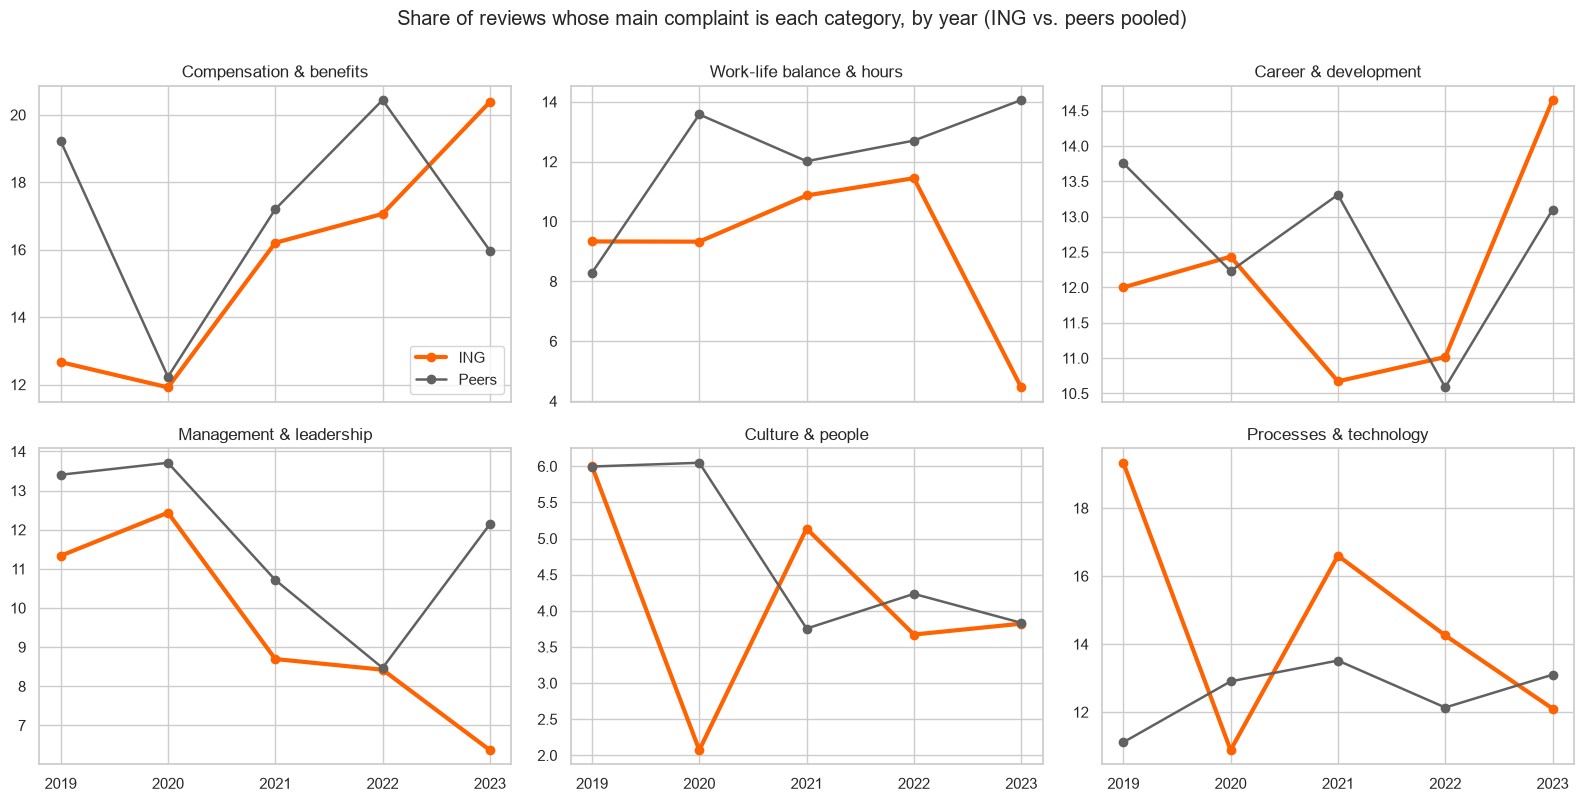

In [77]:
# ING vs. peers pooled, before / after 2020
ext_df = clean_df.assign(period=np.where(clean_df["year"] < 2020, "2018-19", "2020-23"),
                         group=np.where(clean_df["firm"].to_numpy() == TARGET, TARGET, "Peers"))

def period_table(cat_col):
    # Share of each category by period and its change, ING minus peers
    parts = {(g, p): ext_df.loc[(ext_df["group"] == g) & (ext_df["period"] == p), cat_col]
             for g in [TARGET, "Peers"] for p in ["2018-19", "2020-23"]}

    def change(g, cat):
        a, b = parts[(g, "2018-19")], parts[(g, "2020-23")]
        pa, pb = (a == cat).mean(), (b == cat).mean()
        se = sqrt(pa * (1 - pa) / len(a) + pb * (1 - pb) / len(b))
        return pa * 100, pb * 100, (pb - pa) * 100, se * 100

    rows = []
    for cat in COMPARABLE:
        ing, peers = change(TARGET, cat), change("Peers", cat)
        diff, half = ing[2] - peers[2], 1.96 * sqrt(ing[3] ** 2 + peers[3] ** 2)
        rows.append({"Category": cat, "ING 2018-19 %": ing[0], "ING 2020-23 %": ing[1], "ING change (pp)": ing[2],
                     "Peers change (pp)": peers[2], "ING vs. peers change (pp)": diff, "± (pp)": half,
                     "Evidence": "Interval excludes 0" if abs(diff) > half else "Indicative"})
    n = {k: len(v) for k, v in parts.items()}
    return pd.DataFrame(rows).set_index("Category").sort_values("ING vs. peers change (pp)", ascending=False), n

for side, col in [("CONS", "cat_cons"), ("PROS", "cat_pros")]:
    tbl, n = period_table(col)
    print(f"{side}: reviews ING {n[(TARGET, '2018-19')]} (2018-19) / {n[(TARGET, '2020-23')]} (2020-23); "
          f"peers {n[('Peers', '2018-19')]} / {n[('Peers', '2020-23')]}")
    display(tbl.round(1))
    up, down = tbl["ING vs. peers change (pp)"].idxmax(), tbl["ING vs. peers change (pp)"].idxmin()
    solid = tbl.index[tbl["Evidence"] == "Interval excludes 0"].tolist()
    display(Markdown(f"**Reading ({side.lower()}).** Beyond the market trend, ING's {side.lower()} mention *{up}* more "
                     f"({tbl.loc[up, 'ING vs. peers change (pp)']:+.1f} pp) and *{down}* less ({tbl.loc[down, 'ING vs. peers change (pp)']:+.1f} pp) after 2020. "
                     + (f"Interval excludes zero in: {', '.join('*' + c + '*' for c in solid)}." if solid else
                        "No change has an interval that excludes zero: they are indicative, not conclusive.")))

# Yearly evolution of the complaints (only years with enough ING reviews)
year_n = ext_df.groupby(["year", "group"]).size().unstack(fill_value=0)
valid_years = year_n.index[year_n[TARGET] >= 100].tolist()
cons_year = (pd.crosstab([ext_df["group"], ext_df["year"]], ext_df["cat_cons"], normalize="index").mul(100)
             .reindex(columns=COMPARABLE, fill_value=0))

fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for ax, cat in zip(axes.ravel(), COMPARABLE):
    for grp, color, lw in [(TARGET, PALETTE[TARGET], 3), ("Peers", "#616161", 1.8)]:
        s = cons_year.loc[grp].reindex(valid_years)[cat]
        ax.plot(s.index, s.values, marker="o", color=color, lw=lw, label=grp)
    ax.set_title(cat)
    ax.set_xticks(valid_years)
axes[0, 0].legend()
fig.suptitle("Share of reviews whose main complaint is each category, by year (ING vs. peers pooled)", y=1.0)
plt.tight_layout()
plt.show()

### 6.3. Extra: complaints and praise by recommendation

Which themes separate the reviewers who **don't** recommend ING from those who do? Reviews without an opinion (`Neutral`) are left out. `Diff` is the share among non-recommenders minus the share among recommenders, with the z-test and Benjamini-Hochberg correction of 5.2. As in 5.3, I repeat the comparison with only identified themes, because non-recommenders may write fewer empty answers and that would inflate their other categories. The peers (pooled) are shown as a reference to see if a pattern is specific to ING.

ING CONS: 155 reviewers do not recommend vs. 700 who do


,Recommend %,Not recommend %,Diff (pp),± (pp),p-value,p (BH-adj.),Same sign (identified only),Peers diff (pp)
Category,,,,,,,,
Management & leadership,7.429,25.161,17.733,7.102,0.000,0.000,True,12.655
Culture & people,4.286,6.452,2.166,4.148,0.248,0.868,True,5.016
Language & HQ location,2.429,3.226,0.797,3.006,0.571,0.965,n/a,0.855
Compensation & benefits,14.857,15.484,0.627,6.275,0.843,0.965,False,-1.257
Career & development,12.571,12.903,0.332,5.821,0.910,0.965,False,-0.559
Work-life balance & hours,9.143,9.032,-0.111,4.992,0.965,0.965,True,-0.564
Processes & technology,15.000,12.903,-2.097,5.903,0.504,0.965,True,-2.918


ING PROS: 155 reviewers do not recommend vs. 700 who do


,Recommend %,Not recommend %,Diff (pp),± (pp),p-value,p (BH-adj.),Same sign (identified only),Peers diff (pp)
Category,,,,,,,,
Compensation & benefits,14.714,21.290,6.576,6.958,0.043,0.171,True,11.957
Career & development,2.429,4.516,2.088,3.462,0.155,0.371,True,-2.117
Work-life balance & hours,16.429,17.419,0.991,6.572,0.764,0.873,True,-4.145
Company brand & prestige,3.714,3.871,0.157,3.344,0.926,0.926,n/a,1.009
International environment,2.571,1.290,-1.281,2.129,0.340,0.543,n/a,-0.927
Management & leadership,2.286,0.645,-1.641,1.678,0.186,0.371,True,-1.448
Culture & people,26.429,23.871,-2.558,7.464,0.511,0.681,True,-2.830
Processes & technology,4.857,0.645,-4.212,2.031,0.017,0.133,True,-0.644


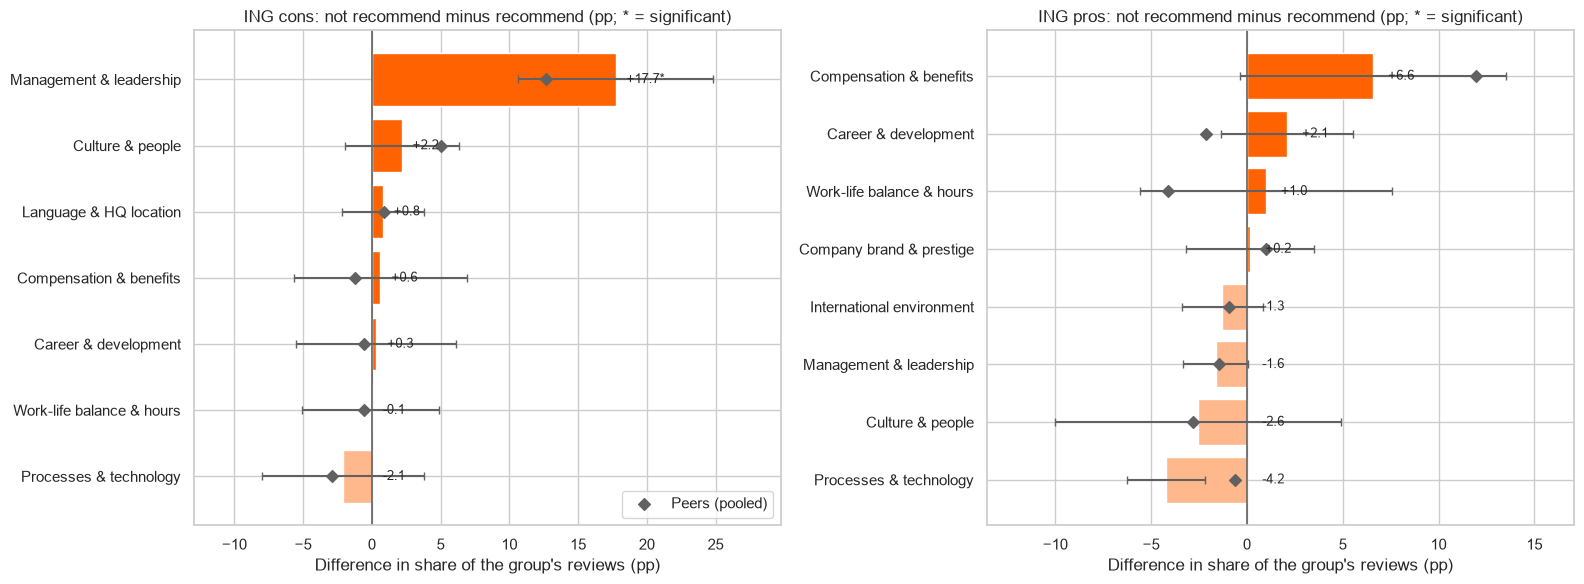

**Reading (cons).** Most over-represented among those who do not recommend ING: *Management & leadership* (+17.7 pp); most typical of those who do: *Processes & technology* (-2.1 pp). Surviving the multiple-comparison correction: *Management & leadership*.

**Reading (pros).** Most over-represented among those who do not recommend ING: *Compensation & benefits* (+6.6 pp); most typical of those who do: *Processes & technology* (-4.2 pp). None survives the multiple-comparison correction: the differences are indicative, not conclusive.

In [78]:
# Not recommend vs. recommend (reviews with opinion only)
def recommend_comparison(df, cat_col, categories, identified_only=False):
    d = df[df["recommends"].isin(["Yes", "No"])]
    if identified_only:
        d = d[d[cat_col].isin(COMPARABLE)]
    yes, no = d.loc[d["recommends"] == "Yes", cat_col], d.loc[d["recommends"] == "No", cat_col]
    n1, n2 = len(yes), len(no)
    rows = []
    for cat in categories:
        p1, p2 = (yes == cat).mean(), (no == cat).mean()
        _, pval = two_prop_test((no == cat).sum(), n2, (yes == cat).sum(), n1)
        half = 1.96 * sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2) * 100
        rows.append({"Category": cat, "Recommend %": p1 * 100, "Not recommend %": p2 * 100,
                     "Diff (pp)": (p2 - p1) * 100, "± (pp)": half, "p-value": pval})
    out = pd.DataFrame(rows).set_index("Category")
    out["p (BH-adj.)"] = bh_adjust(out["p-value"])
    return out, n1, n2

ing_df = clean_df[clean_df["firm"].to_numpy() == TARGET]
peer_df = clean_df[clean_df["firm"].isin(PEERS)]

results = {}
for side, col, cats in [("cons", "cat_cons", CONS_CATS), ("pros", "cat_pros", PROS_CATS)]:
    tbl, n_yes, n_no = recommend_comparison(ing_df, col, cats)
    ident, _, _ = recommend_comparison(ing_df, col, COMPARABLE, identified_only=True)
    peers_tbl, _, _ = recommend_comparison(peer_df, col, cats)
    same = (np.sign(tbl["Diff (pp)"]) == np.sign(ident["Diff (pp)"].reindex(tbl.index))).astype(object)
    same[~tbl.index.isin(COMPARABLE)] = "n/a"
    tbl["Same sign (identified only)"] = same
    tbl["Peers diff (pp)"] = peers_tbl["Diff (pp)"]
    results[side] = tbl.sort_values("Diff (pp)", ascending=False)
    print(f"ING {side.upper()}: {n_no} reviewers do not recommend vs. {n_yes} who do")
    display(results[side].round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (side, t) in zip(axes, results.items()):
    y = np.arange(len(t))
    ax.barh(y, t["Diff (pp)"], xerr=t["± (pp)"], error_kw={"ecolor": "#616161", "capsize": 3},
            color=[PALETTE[TARGET] if v >= 0 else lighten(PALETTE[TARGET], 0.55) for v in t["Diff (pp)"]])
    ax.scatter(t["Peers diff (pp)"], y, marker="D", color="#616161", zorder=3, label="Peers (pooled)")
    for i, (d, p) in enumerate(zip(t["Diff (pp)"], t["p (BH-adj.)"])):
        ax.text(max(d, 0) + 0.8, i, f"{d:+.1f}{'*' if p < 0.05 else ''}", va="center", fontsize=9)
    ax.set_yticks(y)
    ax.set_yticklabels(t.index)
    ax.invert_yaxis()
    ax.axvline(0, color="#616161", linewidth=1.2)
    ax.set_title(f"ING {side}: not recommend minus recommend (pp; * = significant)")
    ax.set_xlabel("Difference in share of the group's reviews (pp)")
    ax.margins(x=0.15)
axes[0].legend(loc="lower right")
plt.tight_layout()
plt.show()

for side, t in results.items():
    up, down = t["Diff (pp)"].idxmax(), t["Diff (pp)"].idxmin()
    sig = t.index[t["p (BH-adj.)"] < 0.05].tolist()
    what = "Complaints" if side == "cons" else "Praise"
    display(Markdown(f"**Reading ({side}).** Most over-represented among those who do not recommend ING: *{up}* ({t.loc[up, 'Diff (pp)']:+.1f} pp); "
                     f"most typical of those who do: *{down}* ({t.loc[down, 'Diff (pp)']:+.1f} pp). " +
                     (f"Surviving the multiple-comparison correction: {', '.join('*' + c + '*' for c in sig)}." if sig else
                      "None survives the multiple-comparison correction: the differences are indicative, not conclusive.")))

## 7. Final Conclusions & Recommendations for HR

**In one sentence:** ING is perceived as a better employer than its peers, and the evidence points to two assets to promote and protect (*Culture & people* and *Work-life balance*), one friction to fix (*Processes & technology*) and one risk to monitor (*Management & leadership*). No confirmed weakness justifies a pay or career overhaul.

### Where ING stands
- **Rating:** 4.00 vs. 3.59-3.71 in the peers, with the advantage in every year, among current employees (4.09) and among former ones (3.84).
- **Recommendation:** 81.9% of ING reviewers with an opinion recommend it, vs. 61.9%-73.6% in the peers. Caution: 43% of ING reviews express no opinion, so the rating is the more reliable of the two signals.
- **Leavers are not an alarm signal:** ING's former employees rate it 3.84 and 74.7% recommend it, as high as the peers' *current* employees.

### Diagnosis by category
*Net gap* = (% of praise - % of complaints) for ING minus the same figure for the peer mean. A category is a real problem only if ING is worse than the market **and** the complaints hurt rating or recommendation. The direction of the strengths holds in every robustness scenario of section 3 and on both sides (pros and cons); 4.2b shows which net gaps can be told apart from zero.

| Category | Verdict | Key evidence |
|---|---|---|
| **Culture & people** | Strength | Net gap +4.2 pp: more praise (+4.0) and no more complaints (-0.3). Few complaints, but costly (-0.34 points in rating, 66 reviews). |
| **Work-life balance & hours** | Strength | Net gap +3.6 pp: more praise and fewer complaints (-2.3). Those who complain do not rate lower (+0.08). BNP-Paribas is on par (+8.7 vs. +6.9 net balance). |
| **Processes & technology** | Improvement area (fragile) | The only category where ING is worse than the market: more complaints overall (+2.2 pp) and among leavers (14.7% vs. 10.3%, +4.4 pp, interval +1.0 to +7.8). It shrinks without outlier reassignment (+0.4 pp overall, +1.6 pp among leavers). Same weight before and after 2020, so it is structural. No rating penalty (-0.02): chronic friction more than a trigger for leaving. ING is also *praised* in this category (agile ways of working and technology: 4.0% of its pros vs. 0.7% in the peers), so the friction coexists with a modern image. |
| **Management & leadership** | Risk to monitor | The costliest complaint everywhere: -0.68 points in rating and -24.7 pp in recommendation among those who complain (leavers: -0.55 points). But the peers show the same penalty (-0.58), and ING receives fewer complaints (9.3% vs. 11.2%). Not an ING-specific problem. |
| **Compensation & benefits** | Not a weakness vs. the market | Main complaint among ING leavers (15.5%) but equal to the peers (15.9%). The pay problem is BNP-Paribas's (23.7% of its cons). Net gap -0.5 pp, no clear rating penalty. Santander is the one praised for pay (net balance +10.3). |
| **Career & development** | Not a weakness; gap in the story | Net gap -0.3 pp, complaints below peers (11.5% vs. 12.3%), no rating penalty. But ING is praised for it less than its peers (3.3% of pros vs. 4.5%). |

**Prioritisation matrix (6.1).** No category is a priority, because ING is not at least 1 pp worse than its peers in net balance in any of them. *Processes & technology* is the only one on watch (more complaints than the peers). The extra cuts of section 6 (before/after 2020, by recommendation) add detail to this picture and are read there.

*Company brand & prestige* is mentioned less in ING's pros than in the peers (3.7% vs. 6.3%). It is a one-sided signal, partly inflated by the firm name in Santander, so it is indicative.

### Recommendations
The first one supports the **attraction plan**; the second and third support the **retention plan**.

1. **Build the employer-branding message on culture and work-life balance (attraction).** They are the only two areas where employees praise ING more than the peers' employees do, without more complaints. Use them in the careers site, job ads and interviews, with real employee testimonials. Complement the story with concrete career paths and internal-mobility examples, because career growth and prestige are what ING is least associated with compared to its competitors.
2. **Run a "less red tape" review of the most-cited processes (retention).** Start with listening sessions and exit interviews to find out *which* approvals, layers of decision and systems cause the friction, and then choose 2-3 quick wins and communicate them. It is the only theme where ING's leavers complain more than the market's leavers, and it is persistent. Since those who stay complain as much as those who leave, the expected impact on turnover is moderate: quick wins, not a large transformation program.
3. **Treat line-management quality as an early-warning system, not a crisis (retention).** Add manager-related questions to pulse surveys and exit interviews and offer coaching where scores are low. When management fails it is the most damaging complaint, but ING receives fewer of them than its peers, so a light preventive approach is proportionate.

**What this data does *not* support:** a company-wide pay review or a career-framework overhaul. Compensation complaints are in line with the market and do not lower ratings, and ING is not worse than its peers in career development.

### Limitations
- **Representativeness of Glassdoor:** reviews are voluntary and skew positive (see 1.3), and many reviewers give no recommendation. Results describe what *reviewers* say, not the whole workforce.
- **Old data:** reviews end in April 2023, so ING's current situation may differ.
- **Mixed countries and areas:** the reviews combine countries and business areas, and the peers are not identical to ING (Deutsche-Bank has a stronger investment-banking component), so part of the gaps may reflect the business mix and not HR policy.
- **Language:** non-English reviews are not removed (some appear in the topic samples of section 3, for example one in German), although the sentiment model and the embedder are English-only. Their share was not measured.
- **Topic precision:** each review gets a single category, a large share remains in *Mixed / generic* (28% of pros, 15% of cons), and some categories are noisy (for example *Work-life balance* among leavers). Only gaps versus peers are interpreted, never absolute levels.
- **Small groups:** ING has 491 former-employee reviews, and only one interval in section 5 (the *Processes & technology* exit gap) excludes zero. Findings tell HR *where to look*; they are not proof.

### Next steps
- Validate the findings with internal data: turnover by area and tenure, exit interviews and engagement surveys.
- Break down *Processes & technology* by country and business area to locate the friction.
- Replace the single-category assignment with a multi-label or aspect-based approach, so reviews that mention several themes are not forced into one.
- Refresh the analysis with recent reviews and add more peers (including non-bank competitors for digital and tech talent).